# VISEM Tracking — notebook final mejorado

Este notebook ejecuta el flujo completo del proyecto desde cero:

1. Lectura de anotaciones reales con `track_id`.
2. Construcción de trayectorias ground truth.
3. Preparación de dataset YOLO multiclase.
4. Entrenamiento del detector.
5. Selección de configuración de tracking usando validation.
6. Evaluación final en test.
7. Exportación de artefactos finales: `best.pt`, métricas, gráficas y ZIP.

La prioridad de esta versión es mejorar el tracking sin cambiar a un modelo más potente que la corrida anterior. Por eso se mantiene YOLOv8s + `imgsz=960`, y las mejoras se concentran en umbrales, configuración del tracker, postprocesamiento, filtrado de trayectorias cortas y reporte de resultados.


## 0. Instalación e imports

In [1]:
# En Kaggle la mayoría de estas librerías ya vienen instaladas.
!pip -q install tqdm pandas numpy matplotlib opencv-python pyyaml

In [2]:
from pathlib import Path
import os
import re
import json
import math
import shutil
import zipfile
import subprocess
from collections import defaultdict

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from IPython.display import display, Image, Video

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Entorno listo.")

Entorno listo.


## 1. Configuración del proyecto y dataset

In [3]:
# Rutas principales de Kaggle
KAGGLE_INPUT_DIR = Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working")

# Carpeta propia del proyecto
PROJECT_DIR = WORK_DIR / "visem_tracking_project"
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
VIDEOS_OUT_DIR = OUTPUT_DIR / "videos"

for directory in [PROJECT_DIR, DATA_DIR, OUTPUT_DIR, TABLES_DIR, FIGURES_DIR, VIDEOS_OUT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Descarga oficial. Solo se usa si no agregaste el dataset desde Kaggle Add Data.
ZENODO_URL = "https://zenodo.org/records/7293726/files/VISEM-Tracking.zip?download=1"
ZIP_PATH = DATA_DIR / "VISEM-Tracking.zip"
EXTRACT_DIR = DATA_DIR / "VISEM-Tracking"

# Cambia a False si no quieres que intente descargar el dataset automáticamente.
ALLOW_DOWNLOAD_IF_MISSING = True

CLASS_NAMES = {
    0: "sperm",
    1: "cluster",
    2: "small_or_pinhead",
}

TARGET_CLASS_ID = 0
TARGET_CLASS_NAME = CLASS_NAMES[TARGET_CLASS_ID]

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv"}

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Clase objetivo inicial:", TARGET_CLASS_ID, TARGET_CLASS_NAME)

PROJECT_DIR: /kaggle/working/visem_tracking_project
OUTPUT_DIR: /kaggle/working/visem_tracking_project/outputs
Clase objetivo inicial: 0 sperm


In [4]:
def find_visem_root(search_dirs):
    """Busca la carpeta VISEM_Tracking_Train_v4 dentro de varias rutas."""
    candidates = []

    for base in search_dirs:
        base = Path(base)
        if not base.exists():
            continue

        exact_matches = list(base.glob("**/VISEM_Tracking_Train_v4"))
        candidates.extend([p for p in exact_matches if p.is_dir()])

        visem_like = [p for p in base.glob("**/*VISEM*") if p.is_dir()]
        candidates.extend([p for p in visem_like if p.is_dir()])

    # Quitar duplicados
    candidates = sorted(set(candidates), key=lambda p: len(str(p)))

    exact = [p for p in candidates if p.name == "VISEM_Tracking_Train_v4"]
    if exact:
        return exact[0]

    return candidates[0] if candidates else None


def download_and_extract_visem():
    """Descarga y descomprime VISEM-Tracking si no está en Kaggle Input."""
    if not ZIP_PATH.exists():
        print("Descargando VISEM-Tracking desde Zenodo...")
        subprocess.run(["wget", "-q", "-c", "-O", str(ZIP_PATH), ZENODO_URL], check=True)
        print("Descarga finalizada:", ZIP_PATH)
    else:
        print("ZIP ya existe:", ZIP_PATH)

    if not EXTRACT_DIR.exists() or not any(EXTRACT_DIR.iterdir()):
        print("Descomprimiendo dataset...")
        EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
            zip_ref.extractall(EXTRACT_DIR)
        print("Descompresión finalizada:", EXTRACT_DIR)
    else:
        print("Dataset ya descomprimido en:", EXTRACT_DIR)

    return find_visem_root([EXTRACT_DIR])


DATASET_ROOT = find_visem_root([KAGGLE_INPUT_DIR, DATA_DIR])

if DATASET_ROOT is None:
    print("No se encontró el dataset en /kaggle/input ni en data local.")
    if ALLOW_DOWNLOAD_IF_MISSING:
        DATASET_ROOT = download_and_extract_visem()
    else:
        raise FileNotFoundError("Agrega VISEM-Tracking desde Kaggle Add Data o habilita la descarga.")

if DATASET_ROOT is None:
    raise FileNotFoundError("No fue posible encontrar DATASET_ROOT después de la descarga/extracción.")

print("DATASET_ROOT:", DATASET_ROOT)

No se encontró el dataset en /kaggle/input ni en data local.
Descargando VISEM-Tracking desde Zenodo...
Descarga finalizada: /kaggle/working/visem_tracking_project/data/VISEM-Tracking.zip
Descomprimiendo dataset...
Descompresión finalizada: /kaggle/working/visem_tracking_project/data/VISEM-Tracking
DATASET_ROOT: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4


## 2. Ubicar archivos útiles para tracking

In [5]:
# Fuente principal para tracking real:
# labels_ftid/*.txt con formato:
# track_id class_id x_center y_center width height

labels_ftid_files = sorted(DATASET_ROOT.glob("**/labels_ftid/*.txt"))
labels_yolo_files = sorted(DATASET_ROOT.glob("**/labels/*.txt"))
all_videos = sorted([p for p in DATASET_ROOT.rglob("*") if p.suffix.lower() in VIDEO_EXTS])
all_images = sorted([p for p in DATASET_ROOT.rglob("*") if p.suffix.lower() in IMAGE_EXTS])

print("Archivos labels_ftid encontrados:", len(labels_ftid_files))
print("Labels YOLO normales encontrados:", len(labels_yolo_files))
print("Videos encontrados:", len(all_videos))
print("Imágenes encontradas:", len(all_images))

if len(labels_ftid_files) == 0:
    raise FileNotFoundError("No se encontraron archivos labels_ftid. Revisa DATASET_ROOT.")

print("\nEjemplos labels_ftid:")
for p in labels_ftid_files[:5]:
    print("-", p)

Archivos labels_ftid encontrados: 29196
Labels YOLO normales encontrados: 29196
Videos encontrados: 20
Imágenes encontradas: 29370

Ejemplos labels_ftid:
- /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_0_with_ftid.txt
- /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_1000_with_ftid.txt
- /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_1001_with_ftid.txt
- /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_1002_with_ftid.txt
- /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_1003_with_ftid.txt


In [6]:
def infer_video_id_from_path(path):
    """Para .../Train/11/labels_ftid/11_frame_0.txt devuelve '11'."""
    path = Path(path)

    if path.parent.name == "labels_ftid":
        return path.parent.parent.name

    nums = re.findall(r"\d+", path.stem)
    return nums[0] if nums else path.parent.name


def infer_frame_number_from_path(path):
    """Para 11_frame_0.txt devuelve 0."""
    path = Path(path)

    match = re.search(r"frame[_\-]?(\d+)", path.stem, re.IGNORECASE)
    if match:
        return int(match.group(1))

    nums = re.findall(r"\d+", path.stem)
    if len(nums) >= 2:
        return int(nums[-1])
    if len(nums) == 1:
        return int(nums[0])

    return np.nan


def find_frame_image_for_label(label_path):
    """Busca la imagen correspondiente a un label_ftid usando el mismo stem."""
    label_path = Path(label_path)
    video_dir = label_path.parent.parent
    stem = label_path.stem

    for image_dir_name in ["images", "imgs", "frames"]:
        image_dir = video_dir / image_dir_name
        if image_dir.exists():
            for ext in IMAGE_EXTS:
                candidate = image_dir / f"{stem}{ext}"
                if candidate.exists():
                    return candidate

    # Fallback: buscar en todo el folder del video
    for ext in IMAGE_EXTS:
        matches = list(video_dir.glob(f"**/{stem}{ext}"))
        if matches:
            return matches[0]

    return None


def valid_yolo_box(x, y, w, h):
    return 0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1

## 3. Parsear anotaciones reales con tracking ID

In [7]:
track_rows = []
bad_rows = []

for txt_path in tqdm(labels_ftid_files, desc="Parseando labels_ftid"):
    video_id = infer_video_id_from_path(txt_path)
    frame_number = infer_frame_number_from_path(txt_path)

    with open(txt_path, "r", errors="ignore") as f:
        for line_number, line in enumerate(f, start=1):
            raw = line.strip()

            if raw == "":
                continue

            parts = raw.split()

            if len(parts) != 6:
                bad_rows.append({
                    "txt_path": str(txt_path),
                    "line_number": line_number,
                    "raw_line": raw,
                    "reason": f"columnas={len(parts)}"
                })
                continue

            try:
                track_id = parts[0]
                class_id = int(float(parts[1]))
                x_center = float(parts[2])
                y_center = float(parts[3])
                width = float(parts[4])
                height = float(parts[5])

                if class_id not in CLASS_NAMES:
                    raise ValueError("class_id fuera de CLASS_NAMES")

                if not valid_yolo_box(x_center, y_center, width, height):
                    raise ValueError("bbox YOLO inválida")

                track_rows.append({
                    "video_id": str(video_id),
                    "frame_number": int(frame_number),
                    "txt_path": str(txt_path),
                    "line_number": line_number,
                    "track_id": track_id,
                    "track_uid": f"{video_id}__{track_id}",
                    "class_id": class_id,
                    "class_name": CLASS_NAMES[class_id],
                    "x_center": x_center,
                    "y_center": y_center,
                    "width": width,
                    "height": height,
                    "area_norm": width * height,
                })

            except Exception as e:
                bad_rows.append({
                    "txt_path": str(txt_path),
                    "line_number": line_number,
                    "raw_line": raw,
                    "reason": str(e)
                })

track_ann_df = pd.DataFrame(track_rows)
bad_track_rows_df = pd.DataFrame(bad_rows)

track_ann_df = track_ann_df.sort_values(
    ["video_id", "frame_number", "track_id"]
).reset_index(drop=True)

print("Anotaciones válidas con track_id:", len(track_ann_df))
print("Filas problemáticas:", len(bad_track_rows_df))

display(track_ann_df.head())

if len(bad_track_rows_df) > 0:
    display(bad_track_rows_df.head())

Parseando labels_ftid:   0%|          | 0/29196 [00:00<?, ?it/s]

Anotaciones válidas con track_id: 656335
Filas problemáticas: 0


,video_id,frame_number,txt_path,line_number,track_id,track_uid,class_id,class_name,x_center,y_center,width,height,area_norm
0,11,0,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_0_w...,1,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,0,sperm,0.275781,0.412500,0.026562,0.0375,0.000996
1,11,0,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_0_w...,2,ckz6ru2eb0001386lefk6js4m,11__ckz6ru2eb0001386lefk6js4m,0,sperm,0.238281,0.583333,0.026562,0.0375,0.000996
2,11,0,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_0_w...,3,ckz6ru3um0003386l39xwv0yk,11__ckz6ru3um0003386l39xwv0yk,0,sperm,0.246094,0.847917,0.026562,0.0375,0.000996
3,11,0,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_0_w...,4,ckz6ru5610005386l8uoys4lc,11__ckz6ru5610005386l8uoys4lc,0,sperm,0.194531,0.845833,0.026562,0.0375,0.000996
4,11,0,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_0_w...,5,ckz6ru6of0007386lhf2t4dtw,11__ckz6ru6of0007386lhf2t4dtw,0,sperm,0.083594,0.806250,0.026562,0.0375,0.000996


## 4. Resúmenes de calidad del dataset

In [8]:
print("Conteo por clase:")
class_counts = (
    track_ann_df["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="n_annotations")
)
class_counts["percentage"] = class_counts["n_annotations"] / class_counts["n_annotations"].sum() * 100
display(class_counts)

print("Frames anotados por video:")
frames_by_video = (
    track_ann_df
    .groupby("video_id")
    .agg(
        n_annotated_frames=("frame_number", "nunique"),
        first_frame=("frame_number", "min"),
        last_frame=("frame_number", "max"),
        n_annotations=("track_id", "count"),
        n_unique_tracks_all_classes=("track_uid", "nunique")
    )
    .reset_index()
    .sort_values("video_id")
)
display(frames_by_video)

print("Clases por video:")
class_by_video = (
    track_ann_df
    .groupby(["video_id", "class_name"])
    .size()
    .reset_index(name="n_annotations")
    .pivot_table(index="video_id", columns="class_name", values="n_annotations", fill_value=0)
    .reset_index()
)
display(class_by_video)

Conteo por clase:


,class_name,n_annotations,percentage
0,sperm,612377,93.302506
1,small_or_pinhead,22112,3.369011
2,cluster,21846,3.328483


Frames anotados por video:


,video_id,n_annotated_frames,first_frame,last_frame,n_annotations,n_unique_tracks_all_classes
0,11,1470,0,1469,56568,57
1,12,1470,0,1469,39357,117
2,13,1470,0,1469,62646,78
3,14,1470,0,1469,5750,8
4,15,1470,0,1469,25215,42
5,19,1470,0,1469,33010,51
6,21,1470,0,1469,32510,80
7,22,1470,0,1469,15983,37
8,23,1296,0,1469,3227,11
9,24,1470,0,1469,97476,111


Clases por video:


class_name,video_id,cluster,small_or_pinhead,sperm
0,11,2714.0,0.0,53854.0
1,12,1470.0,3404.0,34483.0
2,13,0.0,1470.0,61176.0
3,14,721.0,0.0,5029.0
4,15,778.0,778.0,23659.0
5,19,5880.0,173.0,26957.0
6,21,0.0,2954.0,29556.0
7,22,0.0,0.0,15983.0
8,23,0.0,365.0,2862.0
9,24,5880.0,0.0,91596.0


In [9]:
# Guardar tablas principales de auditoría
track_ann_df.to_csv(TABLES_DIR / "tracking_annotations_all_classes.csv", index=False)
class_counts.to_csv(TABLES_DIR / "class_counts_tracking_annotations.csv", index=False)
frames_by_video.to_csv(TABLES_DIR / "frames_by_video_tracking_annotations.csv", index=False)
class_by_video.to_csv(TABLES_DIR / "class_by_video_tracking_annotations.csv", index=False)

if len(bad_track_rows_df) > 0:
    bad_track_rows_df.to_csv(TABLES_DIR / "bad_tracking_annotation_rows.csv", index=False)

print("Tablas de auditoría guardadas en:", TABLES_DIR)

Tablas de auditoría guardadas en: /kaggle/working/visem_tracking_project/outputs/tables


## 5. Construir trayectorias reales de espermatozoides

In [10]:
# Para el objetivo actual usamos solo espermatozoides individuales.
# Los clusters y small_or_pinhead se conservan en track_ann_df, pero no son el foco de trayectorias inicial.

sperm_ann_df = track_ann_df[track_ann_df["class_id"] == TARGET_CLASS_ID].copy()

trajectory_df = (
    sperm_ann_df[
        [
            "video_id",
            "track_id",
            "track_uid",
            "frame_number",
            "x_center",
            "y_center",
            "width",
            "height",
            "area_norm",
            "txt_path",
        ]
    ]
    .sort_values(["video_id", "track_id", "frame_number"])
    .reset_index(drop=True)
)

print("Puntos de trayectoria para sperm:", len(trajectory_df))
display(trajectory_df.head())

Puntos de trayectoria para sperm: 612377


,video_id,track_id,track_uid,frame_number,x_center,y_center,width,height,area_norm,txt_path
0,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,0,0.275781,0.412500,0.026562,0.0375,0.000996,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_0_w...
1,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,1,0.275767,0.412549,0.026562,0.0375,0.000996,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_1_w...
2,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,2,0.275754,0.412598,0.026562,0.0375,0.000996,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_2_w...
3,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,3,0.275740,0.412647,0.026562,0.0375,0.000996,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_3_w...
4,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,4,0.275726,0.412697,0.026562,0.0375,0.000996,/kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels_ftid/11_frame_4_w...


In [11]:
# Resumen por trayectoria
track_summary = (
    trajectory_df
    .groupby(["video_id", "track_id", "track_uid"])
    .agg(
        n_frames=("frame_number", "nunique"),
        first_frame=("frame_number", "min"),
        last_frame=("frame_number", "max"),
        mean_x=("x_center", "mean"),
        mean_y=("y_center", "mean"),
        mean_area=("area_norm", "mean"),
    )
    .reset_index()
)

track_summary["duration_span"] = track_summary["last_frame"] - track_summary["first_frame"] + 1
track_summary["coverage"] = track_summary["n_frames"] / track_summary["duration_span"]

print("Tracks únicos de sperm:", len(track_summary))
display(track_summary["n_frames"].describe())

thresholds = [2, 5, 10, 15, 30, 50, 100, 300, 500]
track_duration_summary = pd.DataFrame([
    {
        "min_frames": t,
        "n_tracks": int((track_summary["n_frames"] >= t).sum()),
        "percentage": float((track_summary["n_frames"] >= t).mean() * 100),
    }
    for t in thresholds
])

print("Trayectorias disponibles según duración mínima:")
display(track_duration_summary)

print("Resumen por video:")
tracks_by_video = (
    track_summary
    .groupby("video_id")
    .agg(
        n_unique_sperm=("track_uid", "nunique"),
        mean_track_length=("n_frames", "mean"),
        median_track_length=("n_frames", "median"),
        max_track_length=("n_frames", "max"),
        mean_coverage=("coverage", "mean"),
    )
    .reset_index()
    .sort_values("video_id")
)
display(tracks_by_video)

Tracks únicos de sperm: 1121


count    1121.000000
mean      546.277431
std       503.084708
min         1.000000
25%       106.000000
50%       383.000000
75%       782.000000
max      1470.000000
Name: n_frames, dtype: float64

Trayectorias disponibles según duración mínima:


,min_frames,n_tracks,percentage
0,2,1116,99.553970
1,5,1103,98.394291
2,10,1083,96.610169
3,15,1063,94.826048
4,30,963,85.905442
5,50,920,82.069581
6,100,849,75.735950
7,300,617,55.040143
8,500,465,41.480821


Resumen por video:


,video_id,n_unique_sperm,mean_track_length,median_track_length,max_track_length,mean_coverage
0,11,55,979.163636,1283.0,1470,0.997661
1,12,111,310.657658,156.0,1470,0.990600
2,13,77,794.493506,756.0,1470,0.997225
3,14,7,718.428571,721.0,749,0.977618
4,15,40,591.475000,778.0,778,1.000000
5,19,46,586.021739,309.5,1470,1.000000
6,21,75,394.080000,373.0,753,1.000000
7,22,37,431.972973,144.0,1470,0.998713
8,23,8,357.750000,228.5,755,1.000000
9,24,107,856.037383,1076.0,1470,0.997770


In [12]:
# Guardar tablas de trayectorias
trajectory_df.to_csv(TABLES_DIR / "sperm_trajectory_points.csv", index=False)
track_summary.to_csv(TABLES_DIR / "sperm_track_summary.csv", index=False)
track_duration_summary.to_csv(TABLES_DIR / "sperm_track_duration_thresholds.csv", index=False)
tracks_by_video.to_csv(TABLES_DIR / "sperm_tracks_by_video.csv", index=False)

print("Tablas de trayectorias guardadas en:", TABLES_DIR)

Tablas de trayectorias guardadas en: /kaggle/working/visem_tracking_project/outputs/tables


## 6. Filtrar trayectorias útiles para análisis de movimiento

In [13]:
# Puedes ajustar estos umbrales más adelante.
MIN_TRACK_FRAMES = 30
MIN_TRACK_COVERAGE = 0.30

usable_track_uids = track_summary[
    (track_summary["n_frames"] >= MIN_TRACK_FRAMES) &
    (track_summary["coverage"] >= MIN_TRACK_COVERAGE)
]["track_uid"].tolist()

usable_trajectory_df = trajectory_df[
    trajectory_df["track_uid"].isin(usable_track_uids)
].copy()

usable_track_summary = track_summary[
    track_summary["track_uid"].isin(usable_track_uids)
].copy()

print("Umbral mínimo de frames:", MIN_TRACK_FRAMES)
print("Cobertura mínima:", MIN_TRACK_COVERAGE)
print("Tracks útiles:", len(usable_track_summary))
print("Puntos de trayectoria útiles:", len(usable_trajectory_df))

display(usable_track_summary.head())

usable_trajectory_df.to_csv(TABLES_DIR / "usable_sperm_trajectory_points.csv", index=False)
usable_track_summary.to_csv(TABLES_DIR / "usable_sperm_track_summary.csv", index=False)

Umbral mínimo de frames: 30
Cobertura mínima: 0.3
Tracks útiles: 962
Puntos de trayectoria útiles: 609497


,video_id,track_id,track_uid,n_frames,first_frame,last_frame,mean_x,mean_y,mean_area,duration_span,coverage
0,11,ckz3v9nzv00033867jsekqdcl,11__ckz3v9nzv00033867jsekqdcl,1470,0,1469,0.267312,0.431563,0.000996,1470,1.0
1,11,ckz6ru2eb0001386lefk6js4m,11__ckz6ru2eb0001386lefk6js4m,1470,0,1469,0.238281,0.577538,0.000996,1470,1.0
2,11,ckz6ru3um0003386l39xwv0yk,11__ckz6ru3um0003386l39xwv0yk,1470,0,1469,0.241859,0.855643,0.000996,1470,1.0
3,11,ckz6ru5610005386l8uoys4lc,11__ckz6ru5610005386l8uoys4lc,1470,0,1469,0.194531,0.845833,0.000996,1470,1.0
4,11,ckz6ru6of0007386lhf2t4dtw,11__ckz6ru6of0007386lhf2t4dtw,1470,0,1469,0.083594,0.806250,0.000996,1470,1.0


## 7. Visualización rápida de trayectorias

Video de ejemplo: 36
Figura guardada en: /kaggle/working/visem_tracking_project/outputs/figures/trajectories_video_36.png


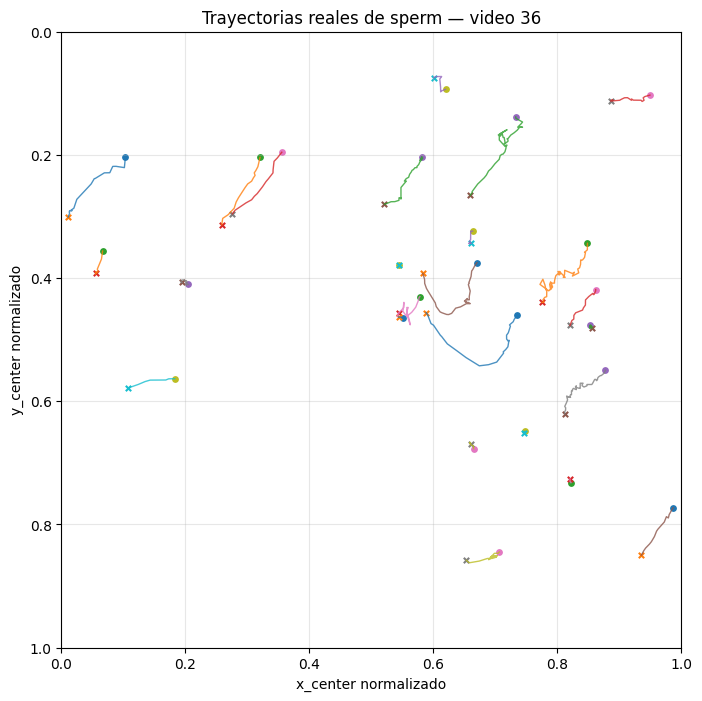

PosixPath('/kaggle/working/visem_tracking_project/outputs/figures/trajectories_video_36.png')

In [14]:
def plot_tracks_for_video(video_id, max_tracks=20, min_frames=30, save=True):
    """Grafica trayectorias normalizadas para un video."""
    video_tracks = track_summary[
        (track_summary["video_id"] == str(video_id)) &
        (track_summary["n_frames"] >= min_frames)
    ].sort_values("n_frames", ascending=False)

    selected_uids = video_tracks["track_uid"].head(max_tracks).tolist()
    plot_df = trajectory_df[trajectory_df["track_uid"].isin(selected_uids)]

    if plot_df.empty:
        print(f"No hay trayectorias para video {video_id} con min_frames={min_frames}.")
        return None

    plt.figure(figsize=(8, 8))

    for track_uid, group in plot_df.groupby("track_uid"):
        group = group.sort_values("frame_number")
        plt.plot(group["x_center"], group["y_center"], linewidth=1, alpha=0.8)
        plt.scatter(group["x_center"].iloc[0], group["y_center"].iloc[0], s=15, marker="o")
        plt.scatter(group["x_center"].iloc[-1], group["y_center"].iloc[-1], s=15, marker="x")

    plt.gca().invert_yaxis()
    plt.xlim(0, 1)
    plt.ylim(1, 0)
    plt.xlabel("x_center normalizado")
    plt.ylabel("y_center normalizado")
    plt.title(f"Trayectorias reales de sperm — video {video_id}")
    plt.grid(True, alpha=0.3)

    out_path = FIGURES_DIR / f"trajectories_video_{video_id}.png"

    if save:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print("Figura guardada en:", out_path)

    plt.show()
    return out_path


# Elegir automáticamente un video con muchas trayectorias largas
example_video_id = (
    tracks_by_video
    .sort_values(["n_unique_sperm", "median_track_length"], ascending=False)
    .iloc[0]["video_id"]
)

print("Video de ejemplo:", example_video_id)
plot_tracks_for_video(example_video_id, max_tracks=25, min_frames=50)

Track más largo: 11__ckz6ruchb000f386lxxpeu5na
Figura guardada en: /kaggle/working/visem_tracking_project/outputs/figures/single_track_video_11_ckz6ruchb000f386lxxpeu5na.png


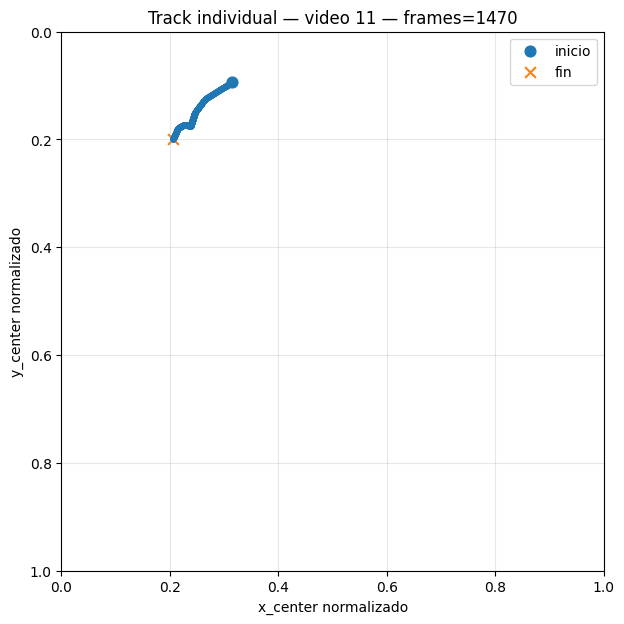

PosixPath('/kaggle/working/visem_tracking_project/outputs/figures/single_track_video_11_ckz6ruchb000f386lxxpeu5na.png')

In [15]:
def plot_single_track(track_uid, save=True):
    """Grafica una trayectoria individual."""
    group = trajectory_df[trajectory_df["track_uid"] == track_uid].sort_values("frame_number")

    if group.empty:
        print("No existe track_uid:", track_uid)
        return None

    video_id = group["video_id"].iloc[0]
    track_id = group["track_id"].iloc[0]

    plt.figure(figsize=(7, 7))
    plt.plot(group["x_center"], group["y_center"], marker=".", linewidth=1)
    plt.scatter(group["x_center"].iloc[0], group["y_center"].iloc[0], s=60, marker="o", label="inicio")
    plt.scatter(group["x_center"].iloc[-1], group["y_center"].iloc[-1], s=60, marker="x", label="fin")

    plt.gca().invert_yaxis()
    plt.xlim(0, 1)
    plt.ylim(1, 0)
    plt.xlabel("x_center normalizado")
    plt.ylabel("y_center normalizado")
    plt.title(f"Track individual — video {video_id} — frames={len(group)}")
    plt.grid(True, alpha=0.3)
    plt.legend()

    safe_track_id = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(track_id))[:80]
    out_path = FIGURES_DIR / f"single_track_video_{video_id}_{safe_track_id}.png"

    if save:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print("Figura guardada en:", out_path)

    plt.show()
    return out_path


# Graficar el track más largo como ejemplo
longest_track_uid = track_summary.sort_values("n_frames", ascending=False).iloc[0]["track_uid"]
print("Track más largo:", longest_track_uid)
plot_single_track(longest_track_uid)

## 8. Revisar trayectoria sobre un frame real

In [16]:
def yolo_to_pixel_box(x, y, w, h, image_width, image_height):
    """Convierte bbox YOLO normalizada a x1, y1, x2, y2 en píxeles."""
    x1 = int((x - w / 2) * image_width)
    y1 = int((y - h / 2) * image_height)
    x2 = int((x + w / 2) * image_width)
    y2 = int((y + h / 2) * image_height)

    x1 = max(0, min(x1, image_width - 1))
    x2 = max(0, min(x2, image_width - 1))
    y1 = max(0, min(y1, image_height - 1))
    y2 = max(0, min(y2, image_height - 1))

    return x1, y1, x2, y2


def draw_tracks_on_frame(video_id, frame_number=None, max_tracks=30, history_frames=100, save=True):
    """Dibuja cajas y trazas recientes sobre un frame real."""
    video_id = str(video_id)

    video_points = trajectory_df[trajectory_df["video_id"] == video_id]

    if video_points.empty:
        print("No hay puntos para video:", video_id)
        return None

    if frame_number is None:
        frame_number = int(video_points["frame_number"].median())

    frame_points = video_points[video_points["frame_number"] == frame_number].copy()

    if frame_points.empty:
        print(f"No hay anotaciones en video {video_id}, frame {frame_number}.")
        return None

    # Buscar imagen correspondiente desde uno de los txt_path del frame
    label_path = Path(frame_points["txt_path"].iloc[0])
    image_path = find_frame_image_for_label(label_path)

    if image_path is None:
        print("No se encontró imagen para:", label_path)
        return None

    img = cv2.imread(str(image_path))

    if img is None:
        print("No se pudo leer imagen:", image_path)
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img = img.shape[:2]

    # Tomar tracks más largos presentes en ese frame
    present_uids = frame_points["track_uid"].unique().tolist()
    selected_uids = (
        track_summary[track_summary["track_uid"].isin(present_uids)]
        .sort_values("n_frames", ascending=False)
        .head(max_tracks)["track_uid"]
        .tolist()
    )

    canvas = img.copy()

    for track_uid in selected_uids:
        current = frame_points[frame_points["track_uid"] == track_uid].iloc[0]

        x1, y1, x2, y2 = yolo_to_pixel_box(
            current["x_center"],
            current["y_center"],
            current["width"],
            current["height"],
            w_img,
            h_img
        )

        cv2.rectangle(canvas, (x1, y1), (x2, y2), (255, 255, 255), 1)

        hist = trajectory_df[
            (trajectory_df["track_uid"] == track_uid) &
            (trajectory_df["frame_number"] <= frame_number) &
            (trajectory_df["frame_number"] >= frame_number - history_frames)
        ].sort_values("frame_number")

        pts = []
        for _, row in hist.iterrows():
            px = int(row["x_center"] * w_img)
            py = int(row["y_center"] * h_img)
            pts.append((px, py))

        if len(pts) >= 2:
            for p1, p2 in zip(pts[:-1], pts[1:]):
                cv2.line(canvas, p1, p2, (255, 255, 255), 1)

    plt.figure(figsize=(10, 8))
    plt.imshow(canvas)
    plt.axis("off")
    plt.title(f"Video {video_id} — frame {frame_number} — trazas recientes")

    out_path = FIGURES_DIR / f"tracks_overlay_video_{video_id}_frame_{frame_number}.png"

    if save:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print("Figura guardada en:", out_path)

    plt.show()
    return out_path


draw_tracks_on_frame(example_video_id, frame_number=None, max_tracks=30, history_frames=100)

No se encontró imagen para: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/36/labels_ftid/36_frame_719_with_ftid.txt


## 9. Exportar resultados

In [17]:
# Crear un ZIP con tablas y figuras generadas
zip_path = WORK_DIR / "visem_tracking_ground_truth_outputs.zip"

if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(
    base_name=str(zip_path).replace(".zip", ""),
    format="zip",
    root_dir=OUTPUT_DIR
)

print("ZIP generado:", zip_path)
print("Contenido principal:")
print("-", TABLES_DIR / "tracking_annotations_all_classes.csv")
print("-", TABLES_DIR / "sperm_trajectory_points.csv")
print("-", TABLES_DIR / "usable_sperm_trajectory_points.csv")
print("-", FIGURES_DIR)

ZIP generado: /kaggle/working/visem_tracking_ground_truth_outputs.zip
Contenido principal:
- /kaggle/working/visem_tracking_project/outputs/tables/tracking_annotations_all_classes.csv
- /kaggle/working/visem_tracking_project/outputs/tables/sperm_trajectory_points.csv
- /kaggle/working/visem_tracking_project/outputs/tables/usable_sperm_trajectory_points.csv
- /kaggle/working/visem_tracking_project/outputs/figures


## Conclusión del Paso 2

En este paso se construyeron trayectorias reales de espermatozoides usando directamente las anotaciones del dataset. Primero se cargaron los archivos `labels_ftid`, se organizó la información en una tabla con video, frame, `track_id`, clase y coordenadas normalizadas de cada bounding box. Luego se filtraron únicamente las anotaciones correspondientes a la clase `sperm`.

A partir de los `track_id`, fue posible agrupar las detecciones de un mismo espermatozoide a lo largo de distintos frames y construir trayectorias reales. Las gráficas generadas muestran que los identificadores de tracking permiten seguir el movimiento de espermatozoides individuales dentro del video.

Este resultado es satisfactorio porque valida que el dataset contiene información útil de tracking y que puede usarse como ground truth para estudiar el movimiento real antes de entrenar o evaluar modelos de detección como YOLO.

El siguiente paso práctico es preparar un dataset YOLO para que el modelo aprenda detección frame por frame. Para eso se usan las mismas anotaciones, pero se elimina el `track_id`, porque YOLO solo necesita: `class x_center y_center width height`.


## 10. Paso 3 definitivo: preparar dataset YOLO multiclase

En la versión anterior entrenamos un detector de una sola clase (`sperm`). Para mejorar el tracking, esta versión prepara por defecto un dataset **multiclase** usando las tres clases del dataset:

```text
0: sperm
1: cluster
2: small_or_pinhead
```

La razón es que, si entrenamos solo `sperm`, las otras estructuras quedan como fondo y el detector puede confundirlas con espermatozoides. En tracking seguiremos usando únicamente la clase `sperm`, pero el detector aprende mejor el contexto visual.

El split sigue siendo por **video**, no por frame, para evitar fuga de información entre train, validation y test.

In [18]:
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Configuración principal de esta versión definitiva
# ------------------------------------------------------------
DETECTION_MODE = "multiclass"  # recomendado: "multiclass". Alternativa: "sperm_only"

if DETECTION_MODE not in ["multiclass", "sperm_only"]:
    raise ValueError("DETECTION_MODE debe ser 'multiclass' o 'sperm_only'.")

if DETECTION_MODE == "multiclass":
    YOLO_CLASS_NAMES = CLASS_NAMES.copy()
    yolo_ann_source_df = track_ann_df[track_ann_df["class_id"].isin(YOLO_CLASS_NAMES.keys())].copy()
    YOLO_DATASET_DIR = PROJECT_DIR / "yolo_visem_multiclass_dataset"
else:
    YOLO_CLASS_NAMES = {0: "sperm"}
    yolo_ann_source_df = sperm_ann_df.copy()
    yolo_ann_source_df["class_id"] = 0
    YOLO_DATASET_DIR = PROJECT_DIR / "yolo_sperm_dataset"

YAML_PATH = YOLO_DATASET_DIR / "data.yaml"

print("Modo de detección:", DETECTION_MODE)
print("Clases YOLO:", YOLO_CLASS_NAMES)
print("Anotaciones usadas para YOLO:", len(yolo_ann_source_df))

def natural_sort_key(value):
    value = str(value)
    return (0, int(value)) if value.isdigit() else (1, value)

# El split se define a partir de videos con sperm, porque esa es la clase objetivo del tracking.
video_ids = sorted(sperm_ann_df["video_id"].astype(str).unique(), key=natural_sort_key)

if len(video_ids) < 3:
    raise ValueError("Se necesitan al menos 3 videos para crear train/val/test por video.")

train_videos, temp_videos = train_test_split(
    video_ids,
    test_size=0.30,
    random_state=42
)

val_videos, test_videos = train_test_split(
    temp_videos,
    test_size=0.50,
    random_state=42
)

split_by_video = {}
for video_id in train_videos:
    split_by_video[str(video_id)] = "train"
for video_id in val_videos:
    split_by_video[str(video_id)] = "val"
for video_id in test_videos:
    split_by_video[str(video_id)] = "test"

split_summary = pd.DataFrame([
    {"split": "train", "n_videos": len(train_videos), "videos": sorted(map(str, train_videos), key=natural_sort_key)},
    {"split": "val", "n_videos": len(val_videos), "videos": sorted(map(str, val_videos), key=natural_sort_key)},
    {"split": "test", "n_videos": len(test_videos), "videos": sorted(map(str, test_videos), key=natural_sort_key)},
])

display(split_summary)

# Guardar split para trazabilidad.
split_summary.to_csv(TABLES_DIR / "video_split_train_val_test.csv", index=False)


Modo de detección: multiclass
Clases YOLO: {0: 'sperm', 1: 'cluster', 2: 'small_or_pinhead'}
Anotaciones usadas para YOLO: 656335


,split,n_videos,videos
0,train,14,"[13, 14, 15, 21, 22, 24, 29, 30, 35, 36, 38, 52, 60, 82]"
1,val,3,"[12, 23, 47]"
2,test,3,"[11, 19, 54]"


In [19]:
# ------------------------------------------------------------
# Crear estructura del dataset YOLO
# ------------------------------------------------------------

if YOLO_DATASET_DIR.exists():
    shutil.rmtree(YOLO_DATASET_DIR)

for split in ["train", "val", "test"]:
    (YOLO_DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print("Dataset YOLO será creado en:")
print(YOLO_DATASET_DIR)


Dataset YOLO será creado en:
/kaggle/working/visem_tracking_project/yolo_visem_multiclass_dataset


In [20]:
# ------------------------------------------------------------
# Índices robustos de imágenes y videos
# ------------------------------------------------------------
# Esto permite que el notebook funcione si el dataset trae frames como imágenes
# o si solo trae videos y toca extraer los frames con OpenCV.

known_video_ids = set(video_ids)

def infer_media_video_id(path):
    path = Path(path)

    for part in reversed(path.parts):
        if part in known_video_ids:
            return str(part)

    nums = re.findall(r"\d+", path.stem)
    for num in nums:
        if num in known_video_ids:
            return str(num)

    return None


def infer_media_frame_number(path):
    path = Path(path)
    stem = path.stem

    match = re.search(r"frame[_\-]?0*(\d+)", stem, re.IGNORECASE)
    if match:
        return int(match.group(1))

    nums = re.findall(r"\d+", stem)
    if nums:
        return int(nums[-1])

    return None


all_images = sorted([
    p for p in Path(DATASET_ROOT).rglob("*")
    if p.suffix.lower() in IMAGE_EXTS
])

all_video_files = sorted([
    p for p in Path(DATASET_ROOT).rglob("*")
    if p.suffix.lower() in VIDEO_EXTS
])

image_index = {}

for image_path in all_images:
    video_id = infer_media_video_id(image_path)
    frame_number = infer_media_frame_number(image_path)

    if video_id is None or frame_number is None:
        continue

    key = (str(video_id), int(frame_number))

    if key not in image_index:
        image_index[key] = image_path

video_index = {}

for video_path in all_video_files:
    video_id = infer_media_video_id(video_path)

    if video_id is None:
        continue

    if video_id not in video_index:
        video_index[video_id] = video_path

print("Imágenes originales encontradas:", len(all_images))
print("Imágenes indexadas por video/frame:", len(image_index))
print("Videos originales encontrados:", len(all_video_files))
print("Videos indexados por video_id:", len(video_index))

print("\nEjemplos de videos indexados:")
for video_id, video_path in list(sorted(video_index.items(), key=lambda x: natural_sort_key(x[0])))[:10]:
    print(f"- video {video_id}: {video_path}")

print("\nEjemplos de imágenes indexadas:")
for key, image_path in list(image_index.items())[:10]:
    print(f"- {key}: {image_path}")


Imágenes originales encontradas: 29370
Imágenes indexadas por video/frame: 29370
Videos originales encontrados: 20
Videos indexados por video_id: 20

Ejemplos de videos indexados:
- video 11: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.mp4
- video 12: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/12/12.mp4
- video 13: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/13/13.mp4
- video 14: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/14/14.mp4
- video 15: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/15/15.mp4
- video 19: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/19/19.mp4
- video 21: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/21/21.mp4
- video 22: /kaggle/working/visem_tracking_

In [21]:
# ------------------------------------------------------------
# Funciones auxiliares para obtener el frame real
# ------------------------------------------------------------

video_capture_cache = {}

def read_existing_image(image_path):
    image = cv2.imread(str(image_path))
    if image is None:
        return None
    return image


def read_video_frame(video_path, frame_number):
    video_path = Path(video_path)

    if str(video_path) not in video_capture_cache:
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            return None
        video_capture_cache[str(video_path)] = cap

    cap = video_capture_cache[str(video_path)]
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_number))
    ok, frame = cap.read()

    if not ok or frame is None:
        return None

    return frame


def get_frame_for_yolo_dataset(video_id, frame_number):
    video_id = str(video_id)
    frame_number = int(frame_number)

    # Intentar exacto y offsets por si el dataset cuenta desde 0 o desde 1.
    candidate_frame_numbers = [frame_number, frame_number - 1, frame_number + 1]

    for candidate_frame in candidate_frame_numbers:
        key = (video_id, candidate_frame)
        if key in image_index:
            image = read_existing_image(image_index[key])
            if image is not None:
                return image, "image", candidate_frame

    if video_id not in video_index:
        return None, "missing_video", None

    video_path = video_index[video_id]

    for candidate_frame in candidate_frame_numbers:
        if candidate_frame < 0:
            continue

        frame = read_video_frame(video_path, candidate_frame)
        if frame is not None:
            return frame, "video", candidate_frame

    return None, "failed_extraction", None


In [22]:
# ------------------------------------------------------------
# Crear dataset YOLO
# ------------------------------------------------------------
# - una imagen por frame anotado
# - un .txt por imagen
# - cada línea queda en formato YOLO normal: class x_center y_center width height

created_images = 0
created_labels = 0
missing_frames = []
source_counter = defaultdict(int)

frame_groups = yolo_ann_source_df.groupby(["video_id", "frame_number"], sort=True)

for (video_id, frame_number), group in tqdm(frame_groups, desc=f"Creando dataset YOLO {DETECTION_MODE}"):
    video_id = str(video_id)
    frame_number = int(frame_number)

    if video_id not in split_by_video:
        continue

    split = split_by_video[video_id]

    output_stem = f"video_{video_id}_frame_{frame_number:06d}"
    output_image_path = YOLO_DATASET_DIR / "images" / split / f"{output_stem}.jpg"
    output_label_path = YOLO_DATASET_DIR / "labels" / split / f"{output_stem}.txt"

    image, source_type, used_frame_number = get_frame_for_yolo_dataset(video_id, frame_number)

    if image is None:
        missing_frames.append({
            "video_id": video_id,
            "frame_number": frame_number,
            "reason": source_type
        })
        continue

    ok = cv2.imwrite(str(output_image_path), image)

    if not ok:
        missing_frames.append({
            "video_id": video_id,
            "frame_number": frame_number,
            "reason": "cv2_imwrite_failed"
        })
        continue

    yolo_lines = []

    for _, row in group.iterrows():
        class_id = int(row["class_id"])

        if class_id not in YOLO_CLASS_NAMES:
            continue

        yolo_lines.append(
            f"{class_id} {float(row['x_center']):.6f} {float(row['y_center']):.6f} {float(row['width']):.6f} {float(row['height']):.6f}"
        )

    if len(yolo_lines) == 0:
        continue

    with open(output_label_path, "w") as f:
        f.write("\n".join(yolo_lines))

    created_images += 1
    created_labels += 1
    source_counter[source_type] += 1

# Liberar videos abiertos por OpenCV
for cap in video_capture_cache.values():
    cap.release()
video_capture_cache = {}

print("Imágenes creadas:", created_images)
print("Labels creados:", created_labels)
print("Frames no encontrados:", len(missing_frames))
print("Fuente de frames:", dict(source_counter))

if len(missing_frames) > 0:
    missing_frames_df = pd.DataFrame(missing_frames)
    display(missing_frames_df.head(20))
    missing_frames_df.to_csv(TABLES_DIR / "missing_frames_yolo_dataset.csv", index=False)

if created_images == 0:
    raise RuntimeError(
        "No se creó ninguna imagen. Revisa si DATASET_ROOT contiene videos o frames accesibles."
    )


Creando dataset YOLO multiclass:   0%|          | 0/29196 [00:00<?, ?it/s]

Imágenes creadas: 29196
Labels creados: 29196
Frames no encontrados: 0
Fuente de frames: {'image': 29196}


In [23]:
# ------------------------------------------------------------
# Crear data.yaml para Ultralytics YOLO
# ------------------------------------------------------------

data_yaml = {
    "path": str(YOLO_DATASET_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": YOLO_CLASS_NAMES,
}

with open(YAML_PATH, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("Archivo YAML creado en:")
print(YAML_PATH)

print("\nContenido:")
print(yaml.dump(data_yaml, sort_keys=False))


Archivo YAML creado en:
/kaggle/working/visem_tracking_project/yolo_visem_multiclass_dataset/data.yaml

Contenido:
path: /kaggle/working/visem_tracking_project/yolo_visem_multiclass_dataset
train: images/train
val: images/val
test: images/test
names:
  0: sperm
  1: cluster
  2: small_or_pinhead



In [24]:
# ------------------------------------------------------------
# Verificación final del dataset YOLO
# ------------------------------------------------------------

verification_rows = []
label_class_rows = []

for split in ["train", "val", "test"]:
    image_files = sorted((YOLO_DATASET_DIR / "images" / split).glob("*.jpg"))
    label_files = sorted((YOLO_DATASET_DIR / "labels" / split).glob("*.txt"))

    image_stems = {p.stem for p in image_files}
    label_stems = {p.stem for p in label_files}

    verification_rows.append({
        "split": split,
        "images": len(image_files),
        "labels": len(label_files),
        "images_without_label": len(image_stems - label_stems),
        "labels_without_image": len(label_stems - image_stems),
    })

    class_counter = defaultdict(int)
    for label_path in label_files:
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_counter[int(parts[0])] += 1

    for class_id, count in sorted(class_counter.items()):
        label_class_rows.append({
            "split": split,
            "class_id": class_id,
            "class_name": YOLO_CLASS_NAMES.get(class_id, "unknown"),
            "n_boxes": count,
        })

verification_df = pd.DataFrame(verification_rows)
label_class_df = pd.DataFrame(label_class_rows)

display(verification_df)
display(label_class_df)

verification_df.to_csv(TABLES_DIR / "yolo_dataset_verification.csv", index=False)
label_class_df.to_csv(TABLES_DIR / "yolo_dataset_class_distribution.csv", index=False)

if (verification_df["images"] == 0).any():
    raise RuntimeError("Algún split quedó sin imágenes. Revisa el split por video o la extracción de frames.")

if (verification_df["images"] != verification_df["labels"]).any():
    raise RuntimeError("Hay splits con diferente número de imágenes y labels.")

if (verification_df["images_without_label"] > 0).any() or (verification_df["labels_without_image"] > 0).any():
    raise RuntimeError("Hay imágenes sin label o labels sin imagen.")

print("Dataset YOLO verificado correctamente.")


,split,images,labels,images_without_label,labels_without_image
0,train,20550,20550,0,0
1,val,4236,4236,0,0
2,test,4410,4410,0,0


,split,class_id,class_name,n_boxes
0,train,0,sperm,448599
1,train,1,cluster,8842
2,train,2,small_or_pinhead,16434
3,val,0,sperm,44641
4,val,1,cluster,1470
5,val,2,small_or_pinhead,4508
6,test,0,sperm,119137
7,test,1,cluster,11534
8,test,2,small_or_pinhead,1170


Dataset YOLO verificado correctamente.


Imagen de muestra: /kaggle/working/visem_tracking_project/yolo_visem_multiclass_dataset/images/train/video_13_frame_000000.jpg
Label de muestra: /kaggle/working/visem_tracking_project/yolo_visem_multiclass_dataset/labels/train/video_13_frame_000000.txt


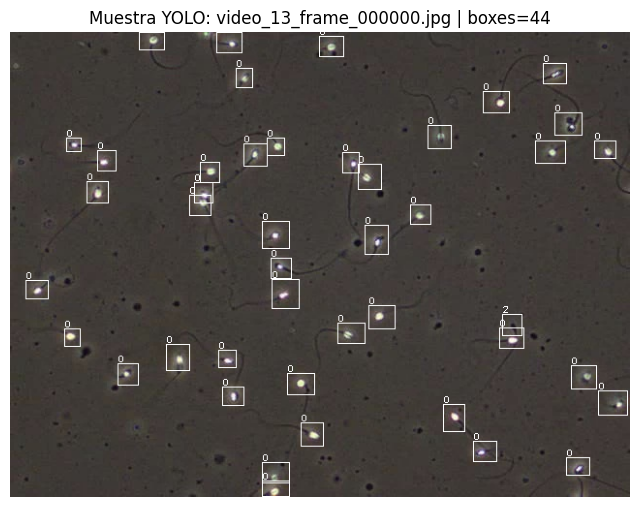

In [25]:
# ------------------------------------------------------------
# Visualizar una muestra del dataset YOLO generado
# ------------------------------------------------------------

def draw_yolo_boxes_on_image(image_path, label_path, class_names=None, max_boxes=120):
    image = cv2.imread(str(image_path))

    if image is None:
        raise FileNotFoundError(f"No se pudo abrir la imagen: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    with open(label_path, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    for line in lines[:max_boxes]:
        cls, x_center, y_center, box_w, box_h = line.split()[:5]
        cls = int(cls)
        x_center = float(x_center)
        y_center = float(y_center)
        box_w = float(box_w)
        box_h = float(box_h)

        x1 = int((x_center - box_w / 2) * w)
        y1 = int((y_center - box_h / 2) * h)
        x2 = int((x_center + box_w / 2) * w)
        y2 = int((y_center + box_h / 2) * h)

        x1 = max(0, min(x1, w - 1))
        x2 = max(0, min(x2, w - 1))
        y1 = max(0, min(y1, h - 1))
        y2 = max(0, min(y2, h - 1))

        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 255, 255), 1)
        cv2.putText(image, str(cls), (x1, max(0, y1 - 2)), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255, 255, 255), 1)

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Muestra YOLO: {image_path.name} | boxes={len(lines)}")
    plt.show()


sample_split = "train"
sample_images = sorted((YOLO_DATASET_DIR / "images" / sample_split).glob("*.jpg"))

if len(sample_images) == 0:
    print("No hay imágenes de muestra en:", sample_split)
else:
    sample_image_path = sample_images[0]
    sample_label_path = YOLO_DATASET_DIR / "labels" / sample_split / f"{sample_image_path.stem}.txt"

    print("Imagen de muestra:", sample_image_path)
    print("Label de muestra:", sample_label_path)

    draw_yolo_boxes_on_image(sample_image_path, sample_label_path, YOLO_CLASS_NAMES)


## 11. Entrenamiento YOLO definitivo

Esta versión usa por defecto `yolov8s.pt` e `imgsz=960`, porque el problema tiene objetos pequeños y el tracking depende de detecciones estables frame a frame.

Si Kaggle da error de memoria, la celda baja automáticamente a una configuración más liviana (`yolov8n.pt`, `imgsz=640`, `batch=8`).

In [26]:
RUN_TRAINING = True

# Configuración final. No se cambia a un modelo más potente que la corrida anterior.
# Si ya tienes un best.pt guardado y no quieres reentrenar, cambia RUN_TRAINING = False.
TRAIN_MODEL_NAME = "yolov8s.pt"
TRAIN_IMG_SIZE = 960
TRAIN_BATCH = 8
TRAIN_EPOCHS = 50
TRAIN_PATIENCE = 12
TRAIN_SEED = 42

if RUN_TRAINING:
    import sys
    import subprocess
    import torch
    import random

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])

    from ultralytics import YOLO

    random.seed(TRAIN_SEED)
    np.random.seed(TRAIN_SEED)
    torch.manual_seed(TRAIN_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(TRAIN_SEED)

    DEVICE = 0 if torch.cuda.is_available() else "cpu"
    print("Device usado para entrenamiento:", DEVICE)
    print("Modelo:", TRAIN_MODEL_NAME)
    print("Image size:", TRAIN_IMG_SIZE)
    print("Batch:", TRAIN_BATCH)

    def train_yolo(model_name, imgsz, batch, run_name):
        model = YOLO(model_name)
        return model.train(
            data=str(YAML_PATH),
            epochs=TRAIN_EPOCHS,
            imgsz=imgsz,
            batch=batch,
            patience=TRAIN_PATIENCE,
            project=str(PROJECT_DIR / "runs"),
            name=run_name,
            pretrained=True,
            device=DEVICE,
            workers=2,
            cache=False,
            seed=TRAIN_SEED,
            deterministic=True,
            verbose=True,
        )

    try:
        results = train_yolo(
            model_name=TRAIN_MODEL_NAME,
            imgsz=TRAIN_IMG_SIZE,
            batch=TRAIN_BATCH,
            run_name=f"visem_{DETECTION_MODE}_yolov8s_img{TRAIN_IMG_SIZE}",
        )
    except RuntimeError as e:
        message = str(e).lower()
        if "out of memory" in message or "cuda" in message:
            print("Error de memoria detectado. Reintentando con configuración liviana de respaldo.")
            torch.cuda.empty_cache()
            TRAIN_MODEL_NAME = "yolov8n.pt"
            TRAIN_IMG_SIZE = 640
            TRAIN_BATCH = 8
            results = train_yolo(
                model_name=TRAIN_MODEL_NAME,
                imgsz=TRAIN_IMG_SIZE,
                batch=TRAIN_BATCH,
                run_name=f"visem_{DETECTION_MODE}_yolov8n_img{TRAIN_IMG_SIZE}_fallback",
            )
        else:
            raise
else:
    print("Entrenamiento desactivado. El notebook buscará el último best.pt existente en PROJECT_DIR / runs.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device usado para entrenamiento: 0
Modelo: yolov8s.pt
Image size: 960
Batch: 8
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/visem_tracking_project/yolo_visem_multiclass_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0,

In [27]:
# ------------------------------------------------------------
# Localizar automáticamente el último entrenamiento válido
# ------------------------------------------------------------

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

RUNS_DIR = PROJECT_DIR / "runs"

train_dirs = sorted(
    [p for p in RUNS_DIR.glob("*") if (p / "results.csv").exists() and (p / "weights" / "best.pt").exists()],
    key=lambda p: p.stat().st_mtime,
    reverse=True
)

if len(train_dirs) == 0:
    raise FileNotFoundError("No se encontró ningún entrenamiento con results.csv y best.pt.")

BEST_RUN_DIR = train_dirs[0]
BEST_WEIGHTS_PATH = BEST_RUN_DIR / "weights" / "best.pt"
LAST_WEIGHTS_PATH = BEST_RUN_DIR / "weights" / "last.pt"

print("Último entrenamiento encontrado:")
print(BEST_RUN_DIR)

print("\nBest weights:")
print(BEST_WEIGHTS_PATH)

print("\nLast weights:")
print(LAST_WEIGHTS_PATH)

print("\n¿Existe best.pt?", BEST_WEIGHTS_PATH.exists())
print("¿Existe last.pt?", LAST_WEIGHTS_PATH.exists())


Último entrenamiento encontrado:
/kaggle/working/visem_tracking_project/runs/visem_multiclass_yolov8s_img960

Best weights:
/kaggle/working/visem_tracking_project/runs/visem_multiclass_yolov8s_img960/weights/best.pt

Last weights:
/kaggle/working/visem_tracking_project/runs/visem_multiclass_yolov8s_img960/weights/last.pt

¿Existe best.pt? True
¿Existe last.pt? True


Columnas disponibles:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6', 'lr/pg7']


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
9,10,9432.8,0.80831,0.37261,0.86999,0.47835,0.28735,0.26988,0.07771,2.84472,1.69839,1.92505,0.024654,0.008218,0.024654,0.008218,0.024654,0.008218,0.024654,0.008218
10,11,10360.2,0.78682,0.36281,0.86517,0.45402,0.27481,0.26617,0.07846,2.78372,1.64980,1.87305,0.024060,0.008020,0.024060,0.008020,0.024060,0.008020,0.024060,0.008020
11,12,11286.9,0.76471,0.35389,0.86050,0.77396,0.26962,0.26470,0.07964,2.78680,1.72131,1.87506,0.023466,0.007822,0.023466,0.007822,0.023466,0.007822,0.023466,0.007822
12,13,12213.9,0.74920,0.34662,0.85694,0.45039,0.28471,0.25608,0.07404,2.81645,1.73320,1.93545,0.022872,0.007624,0.022872,0.007624,0.022872,0.007624,0.022872,0.007624
13,14,13140.7,0.73728,0.34154,0.85509,0.46183,0.26798,0.25550,0.07008,2.91880,1.75110,1.99152,0.022278,0.007426,0.022278,0.007426,0.022278,0.007426,0.022278,0.007426


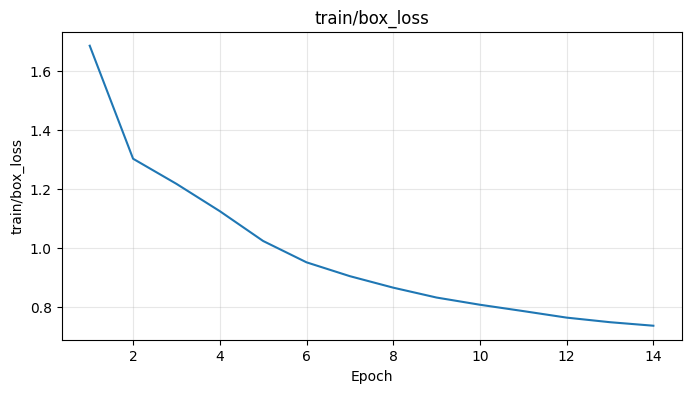

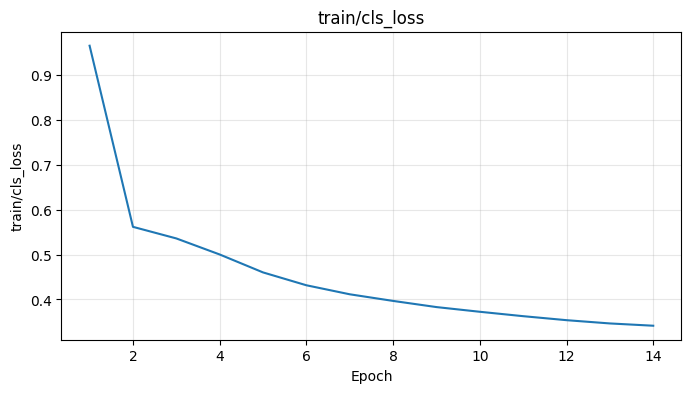

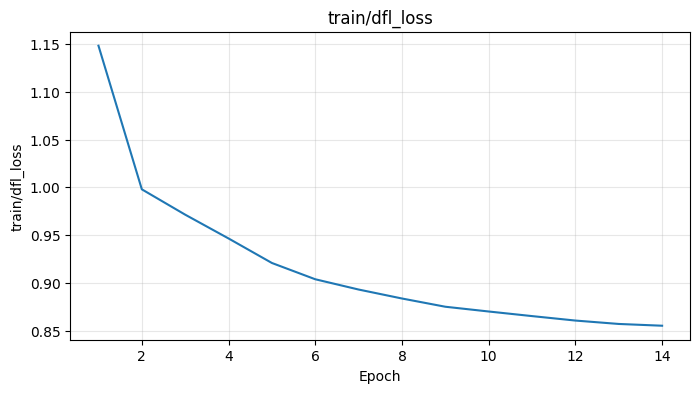

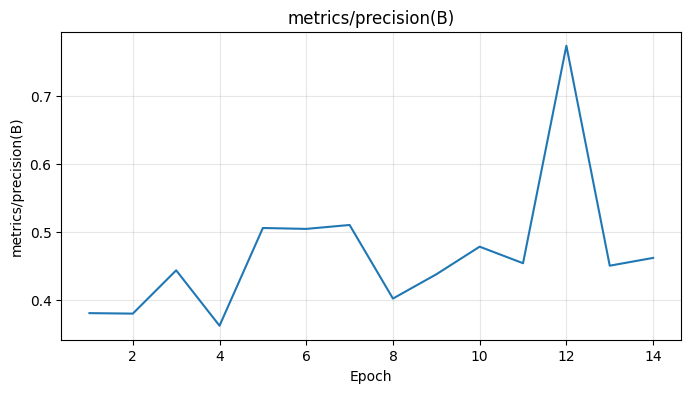

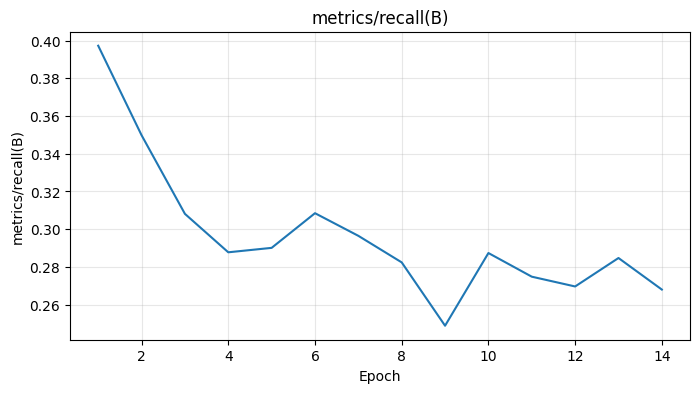

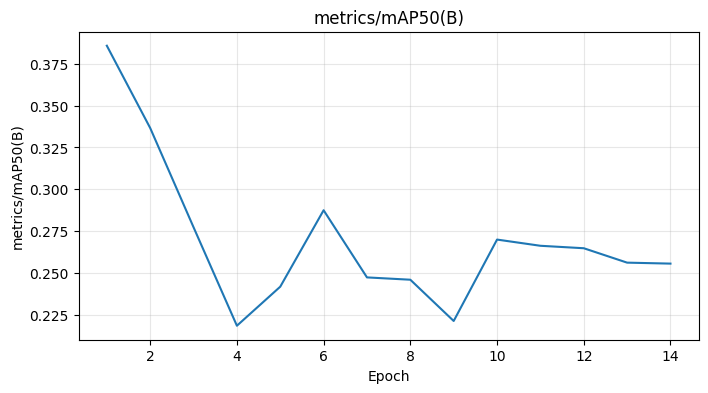

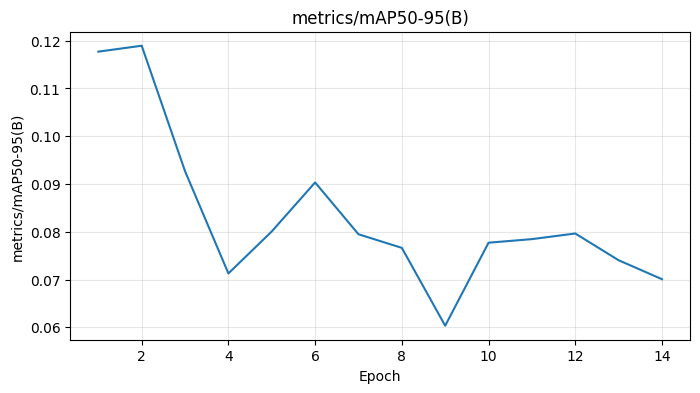

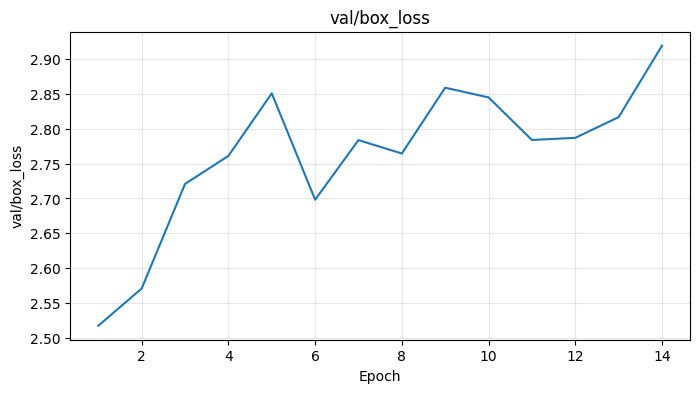

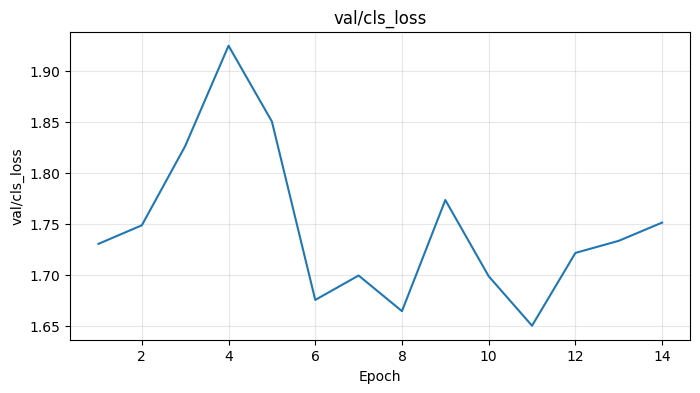

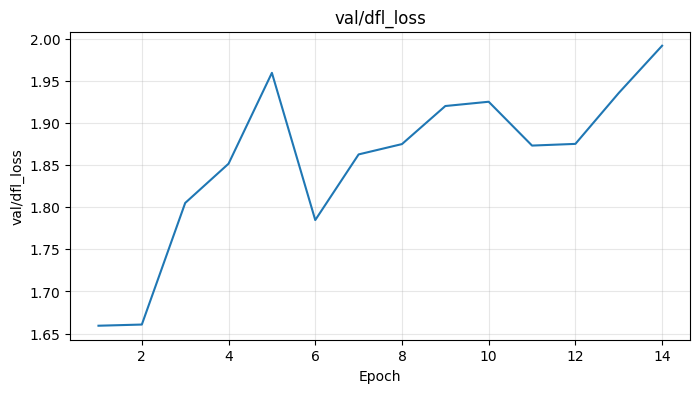

In [28]:
# ------------------------------------------------------------
# Revisar resultados del entrenamiento
# ------------------------------------------------------------

results_csv = BEST_RUN_DIR / "results.csv"

results_df = pd.read_csv(results_csv)
results_df.columns = results_df.columns.str.strip()

print("Columnas disponibles:")
print(results_df.columns.tolist())

display(results_df.tail())

metric_columns = [
    col for col in results_df.columns
    if "loss" in col.lower() or "metrics/" in col.lower()
]

for col in metric_columns:
    plt.figure(figsize=(8, 4))
    plt.plot(results_df["epoch"], results_df[col])
    plt.xlabel("Epoch")
    plt.ylabel(col)
    plt.title(col)
    plt.grid(alpha=0.3)
    plt.show()


In [29]:
# ------------------------------------------------------------
# Validar detector en validation y test
# ------------------------------------------------------------

import torch

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Device usado para validación:", DEVICE)

best_model = YOLO(str(BEST_WEIGHTS_PATH))

VAL_IMG_SIZE = globals().get("TRAIN_IMG_SIZE", 960)

val_metrics = best_model.val(
    data=str(YAML_PATH),
    split="val",
    imgsz=VAL_IMG_SIZE,
    conf=0.25,
    iou=0.5,
    device=DEVICE
)

print("Métricas en validation:")
print("mAP50:", val_metrics.box.map50)
print("mAP50-95:", val_metrics.box.map)
print("Precision:", val_metrics.box.mp)
print("Recall:", val_metrics.box.mr)

test_metrics = best_model.val(
    data=str(YAML_PATH),
    split="test",
    imgsz=VAL_IMG_SIZE,
    conf=0.25,
    iou=0.5,
    device=DEVICE
)

print("\nMétricas en test:")
print("mAP50:", test_metrics.box.map50)
print("mAP50-95:", test_metrics.box.map)
print("Precision:", test_metrics.box.mp)
print("Recall:", test_metrics.box.mr)


Device usado para validación: 0
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1308.7±513.6 MB/s, size: 44.5 KB)
val: Scanning /kaggle/working/visem_tracking_project/yolo_visem_multiclass_dataset/labels/val.cache... 4236 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4236/4236 1.8Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 265/265 2.8it/s 1:36
                   all       4236      50619      0.458      0.308      0.207     0.0628
                 sperm       4014      44641      0.643      0.776      0.524      0.153
               cluster       1470       1470     0.0954     0.0224    0.00241    0.00121
      small_or_pinhead       2574       4508      0.636      0.126     0.0942     0.0342
Speed: 1.3ms preprocess, 17.8ms inference, 0.0ms l

results.png


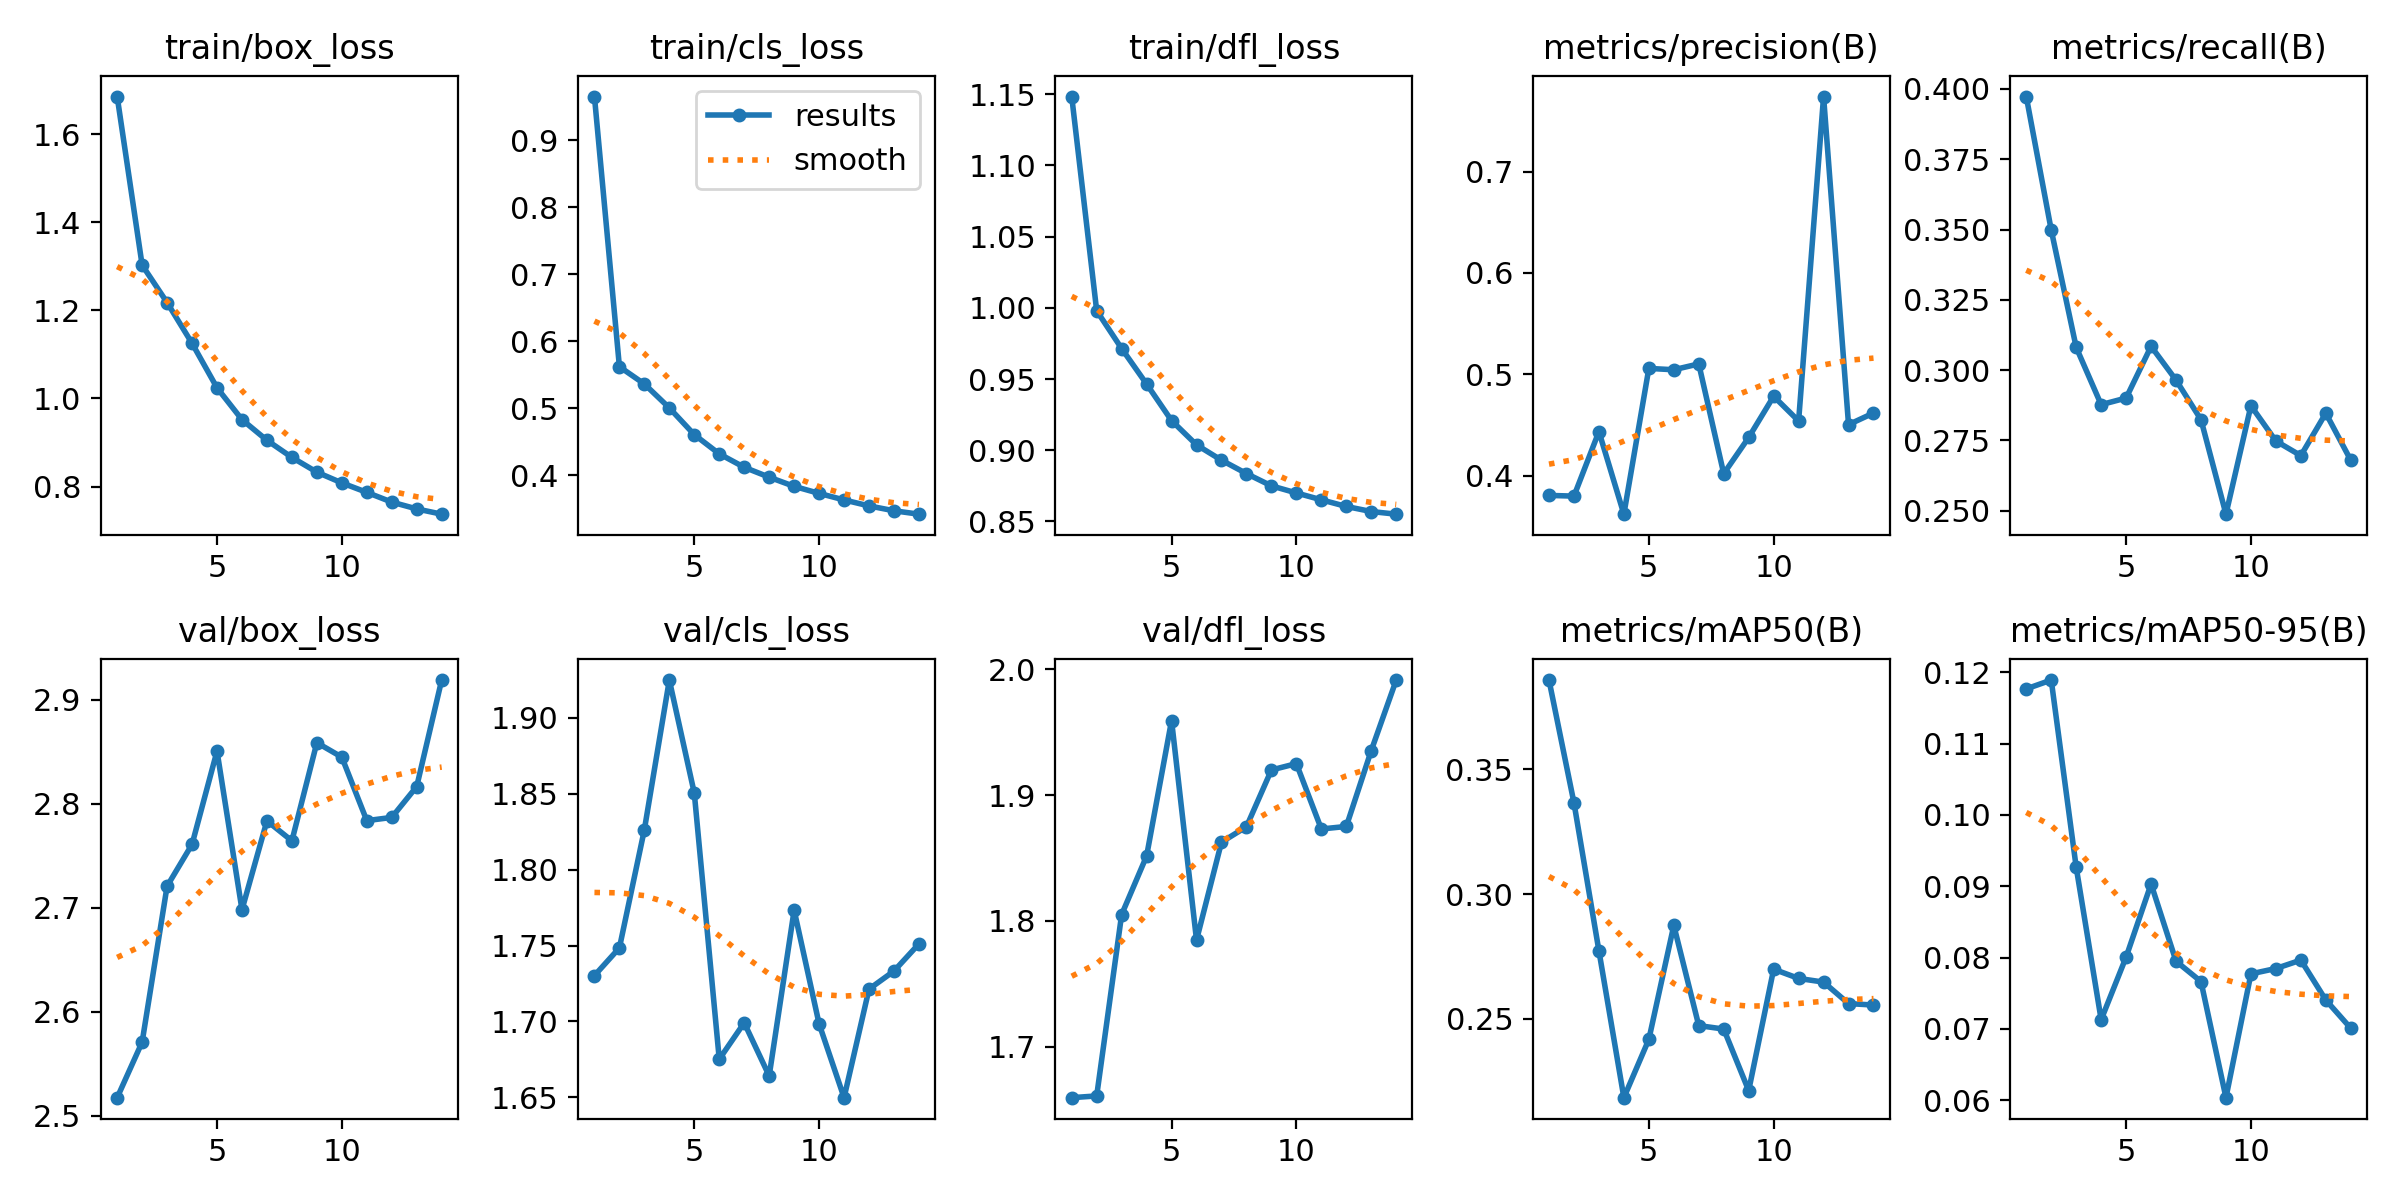

confusion_matrix.png


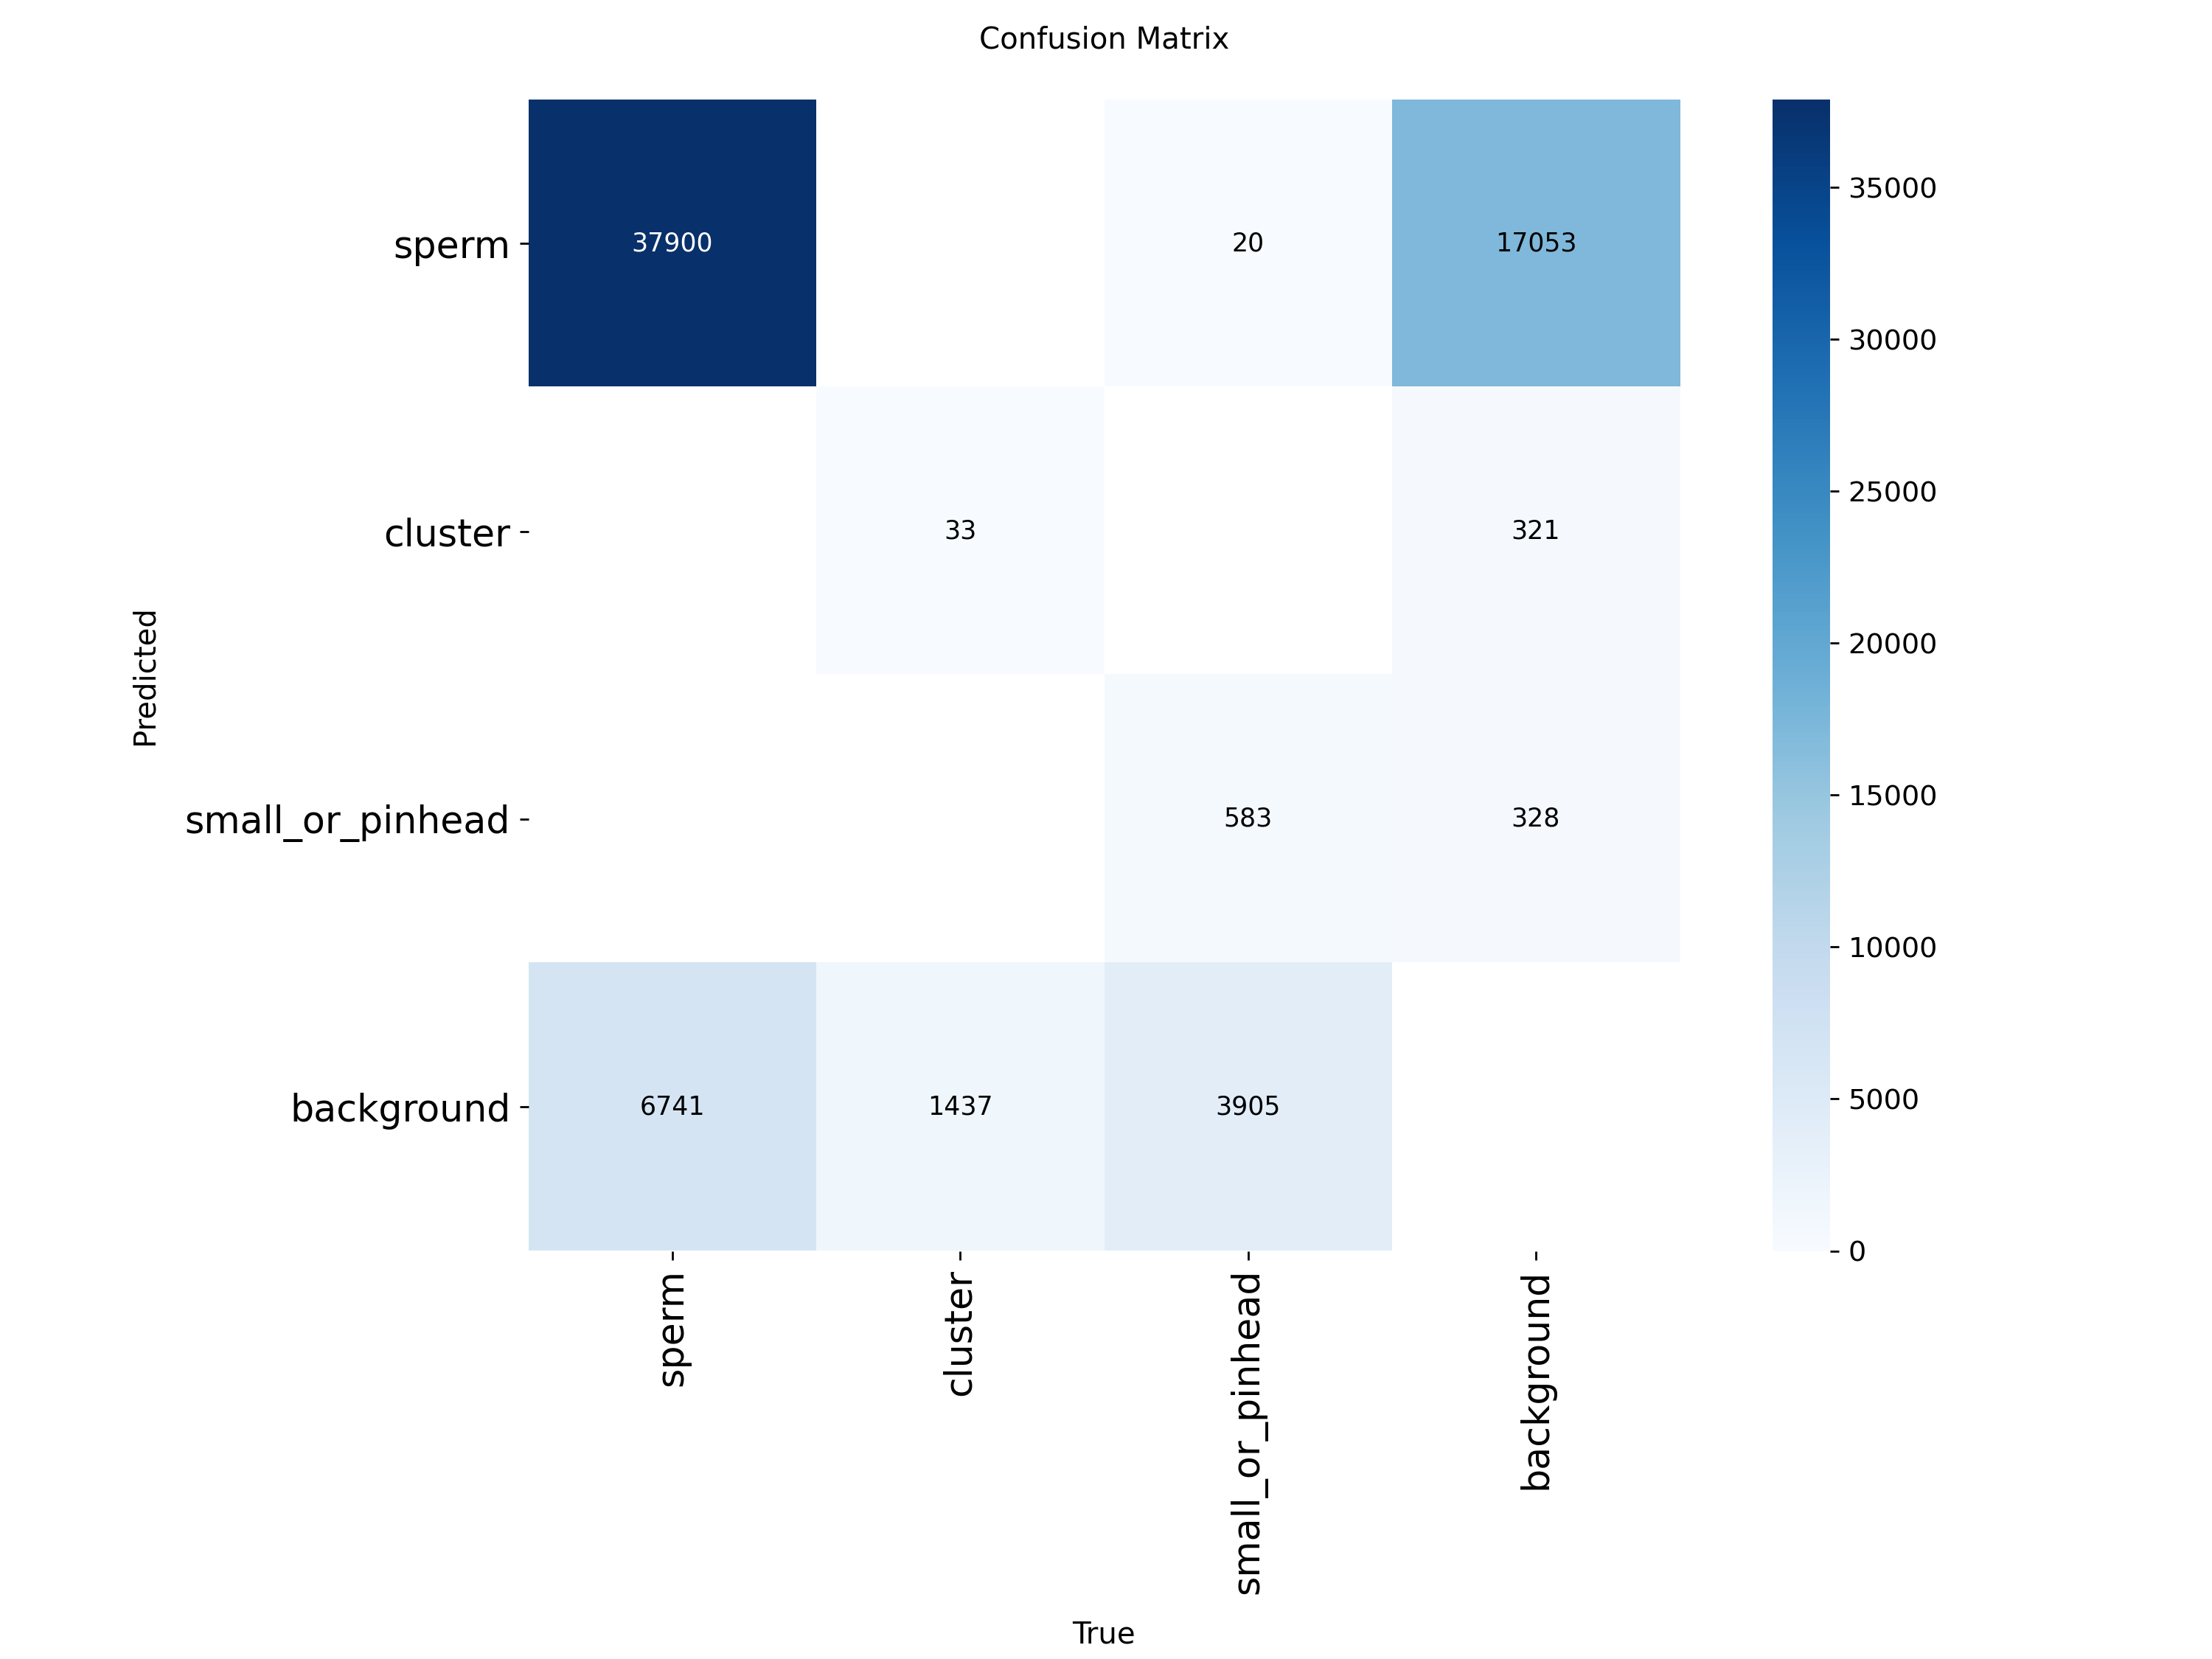

confusion_matrix_normalized.png


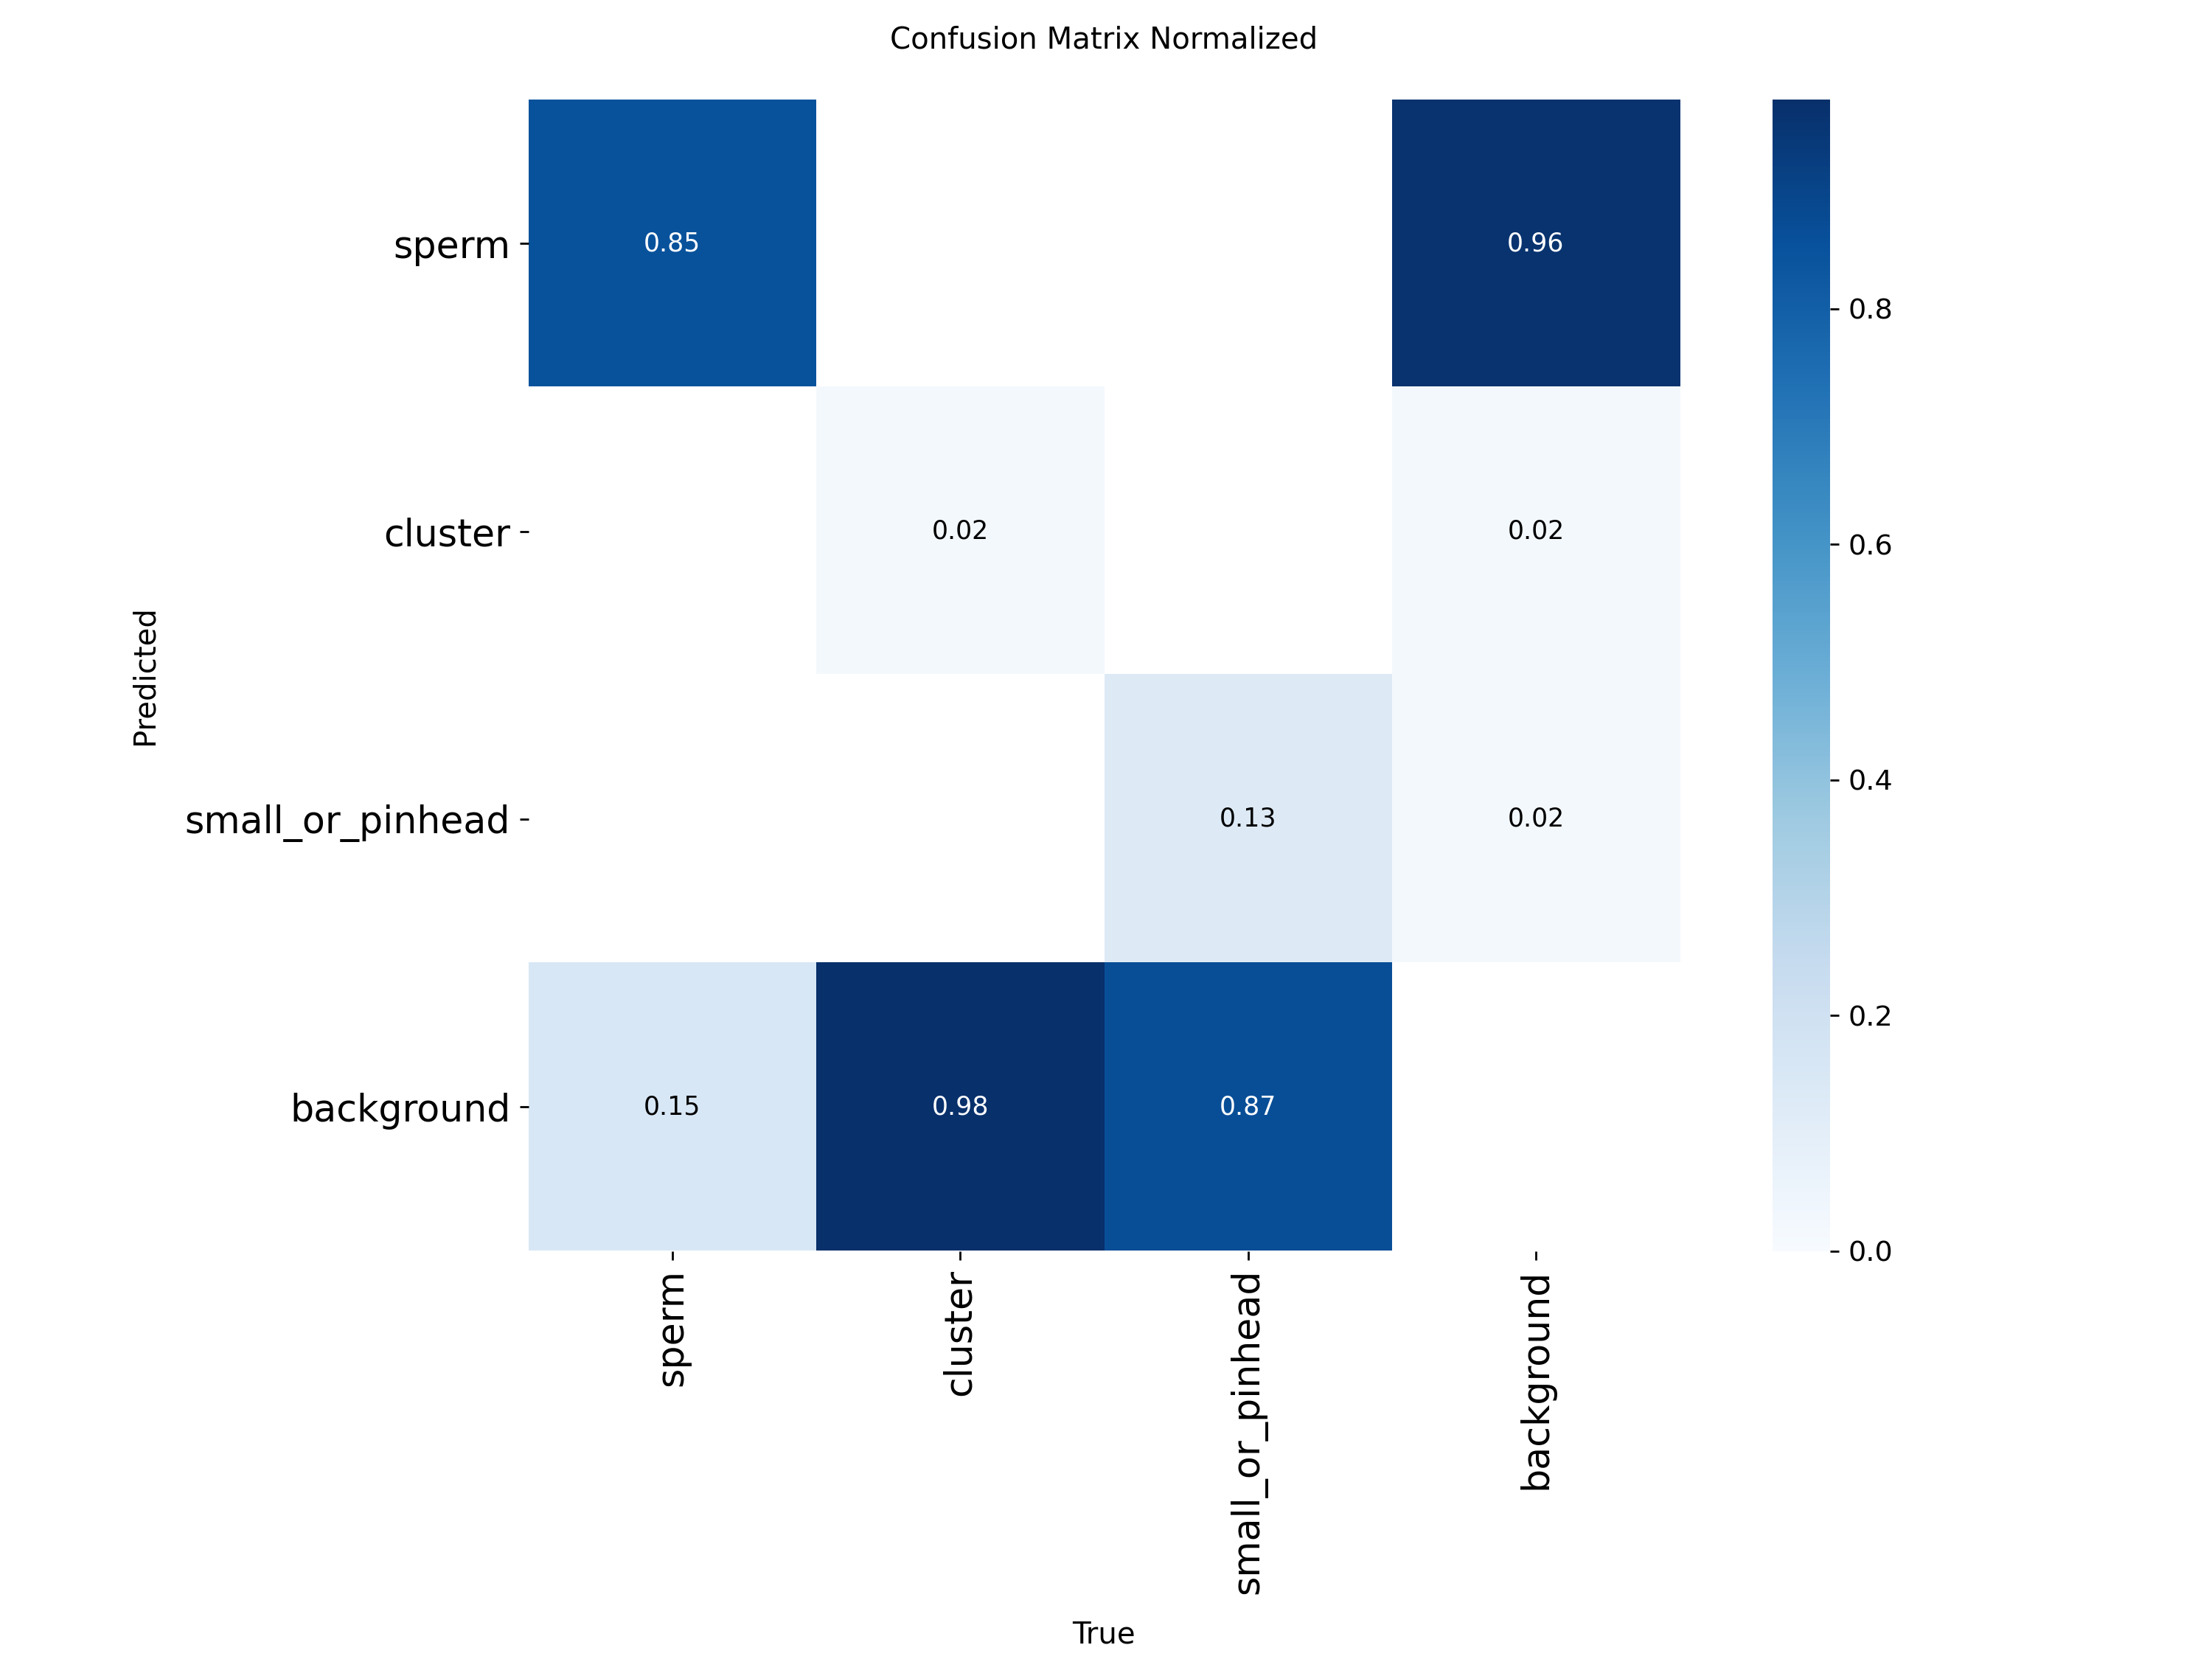

val_batch0_pred.jpg


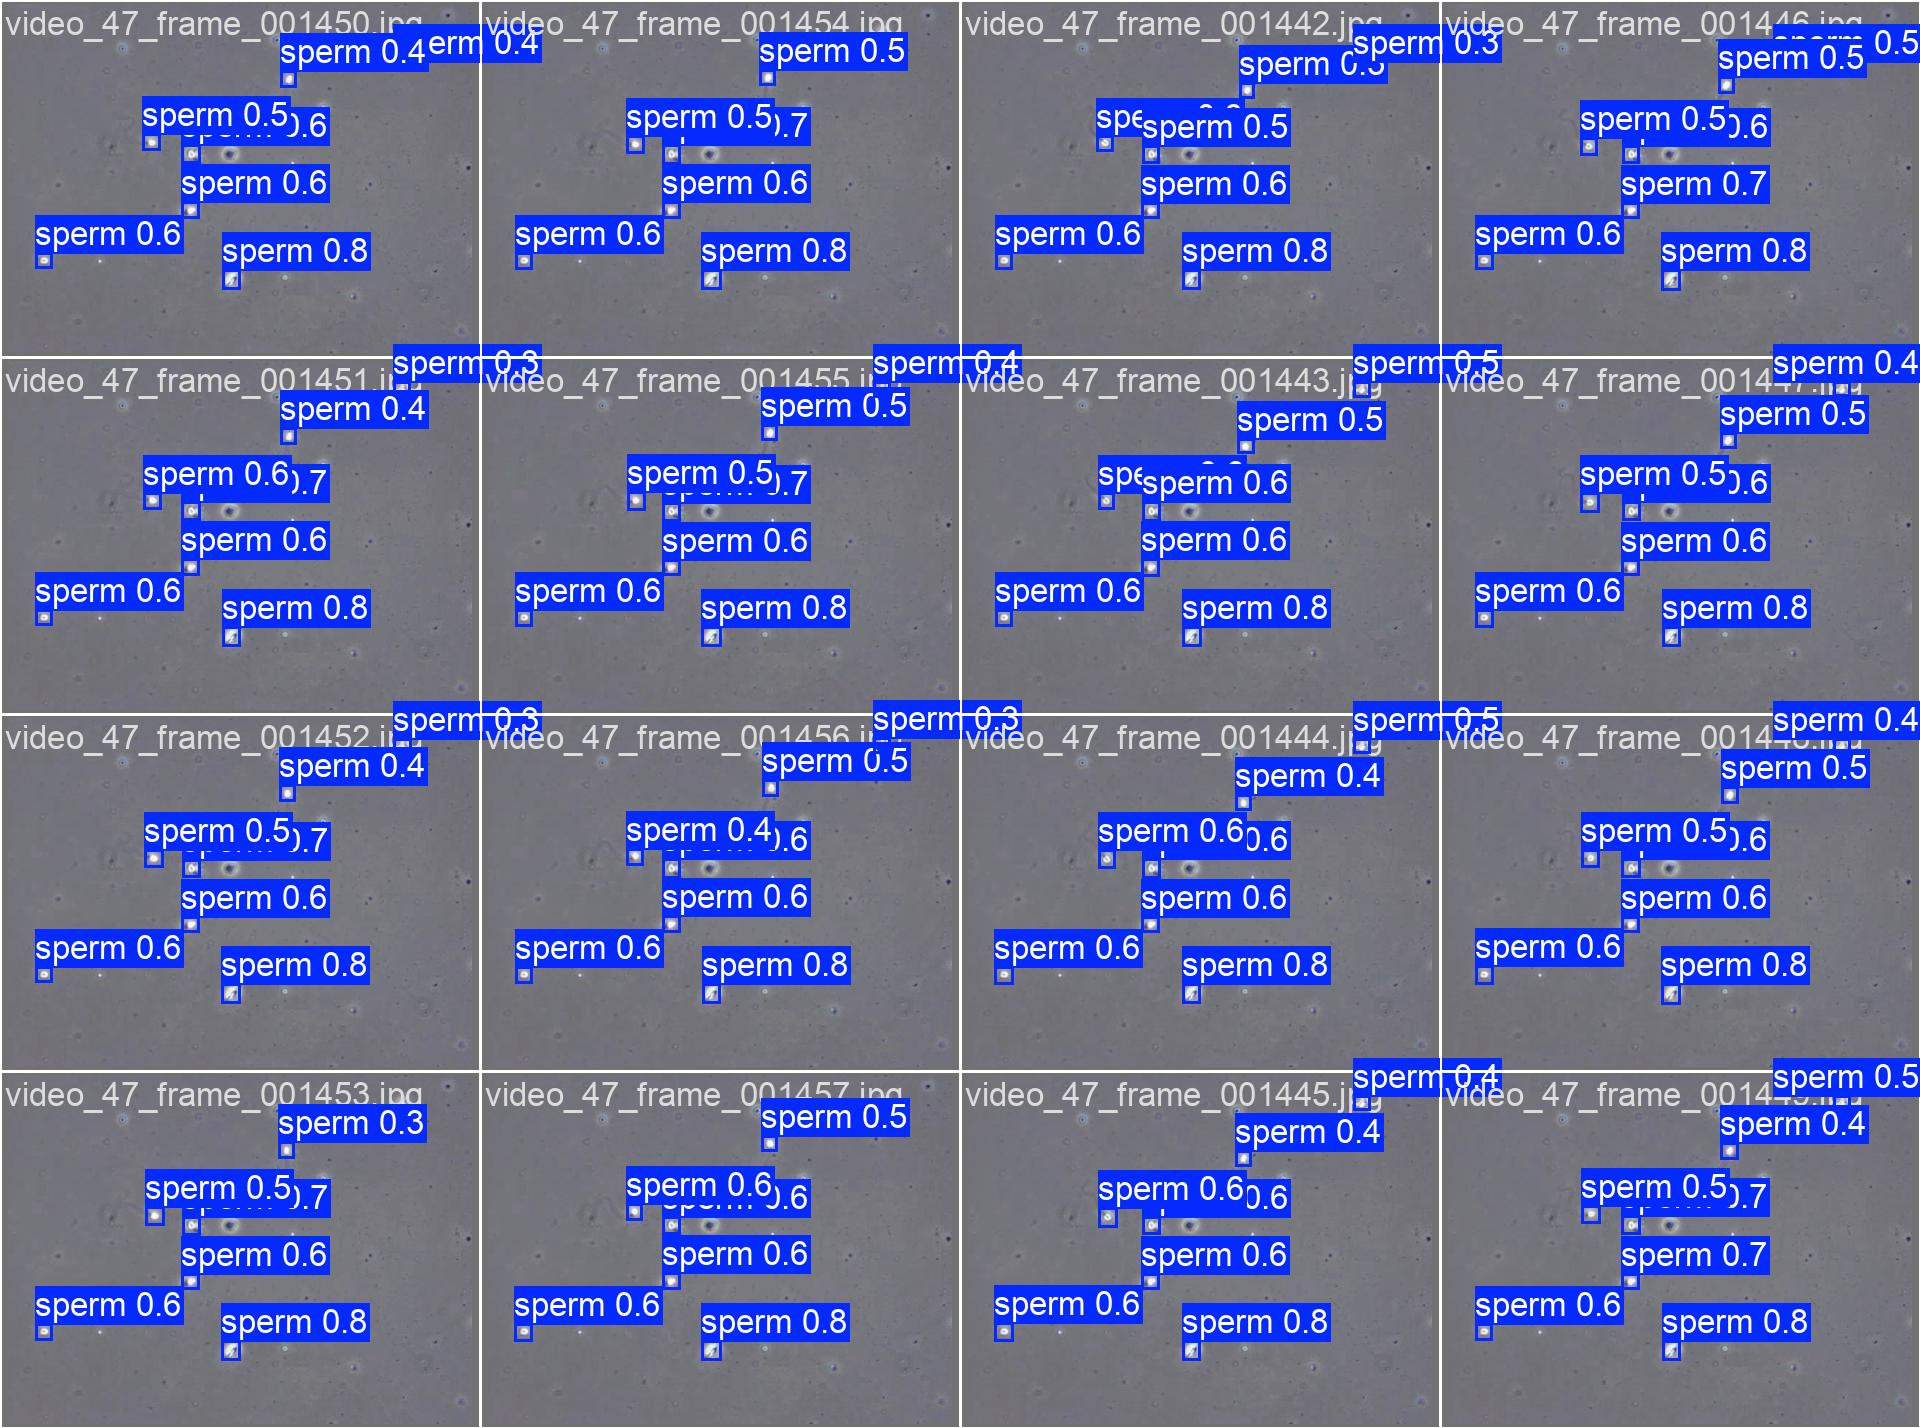

val_batch1_pred.jpg


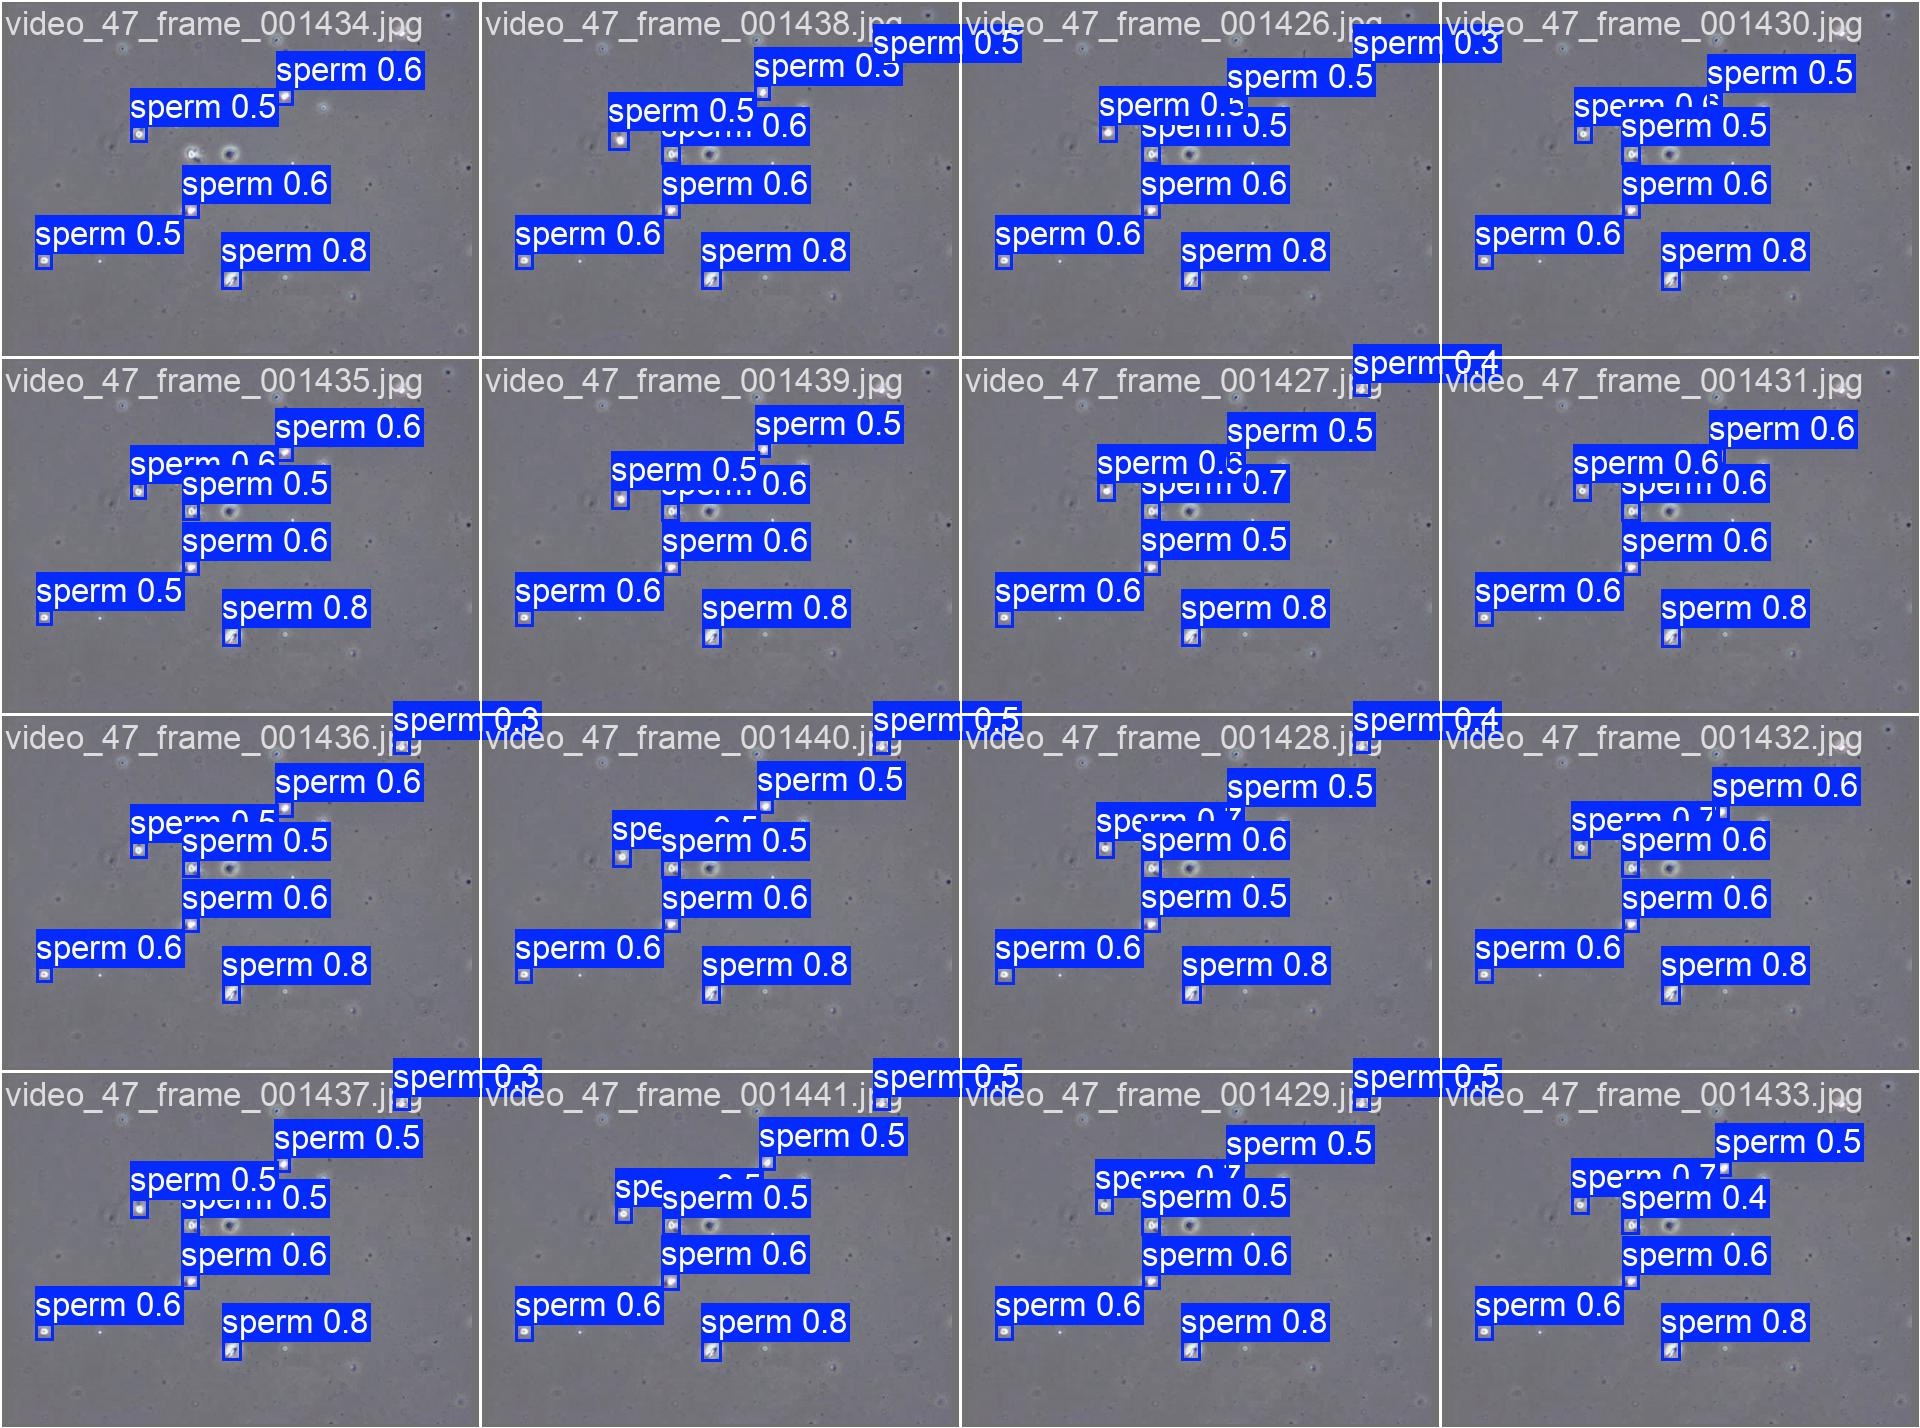

val_batch2_pred.jpg


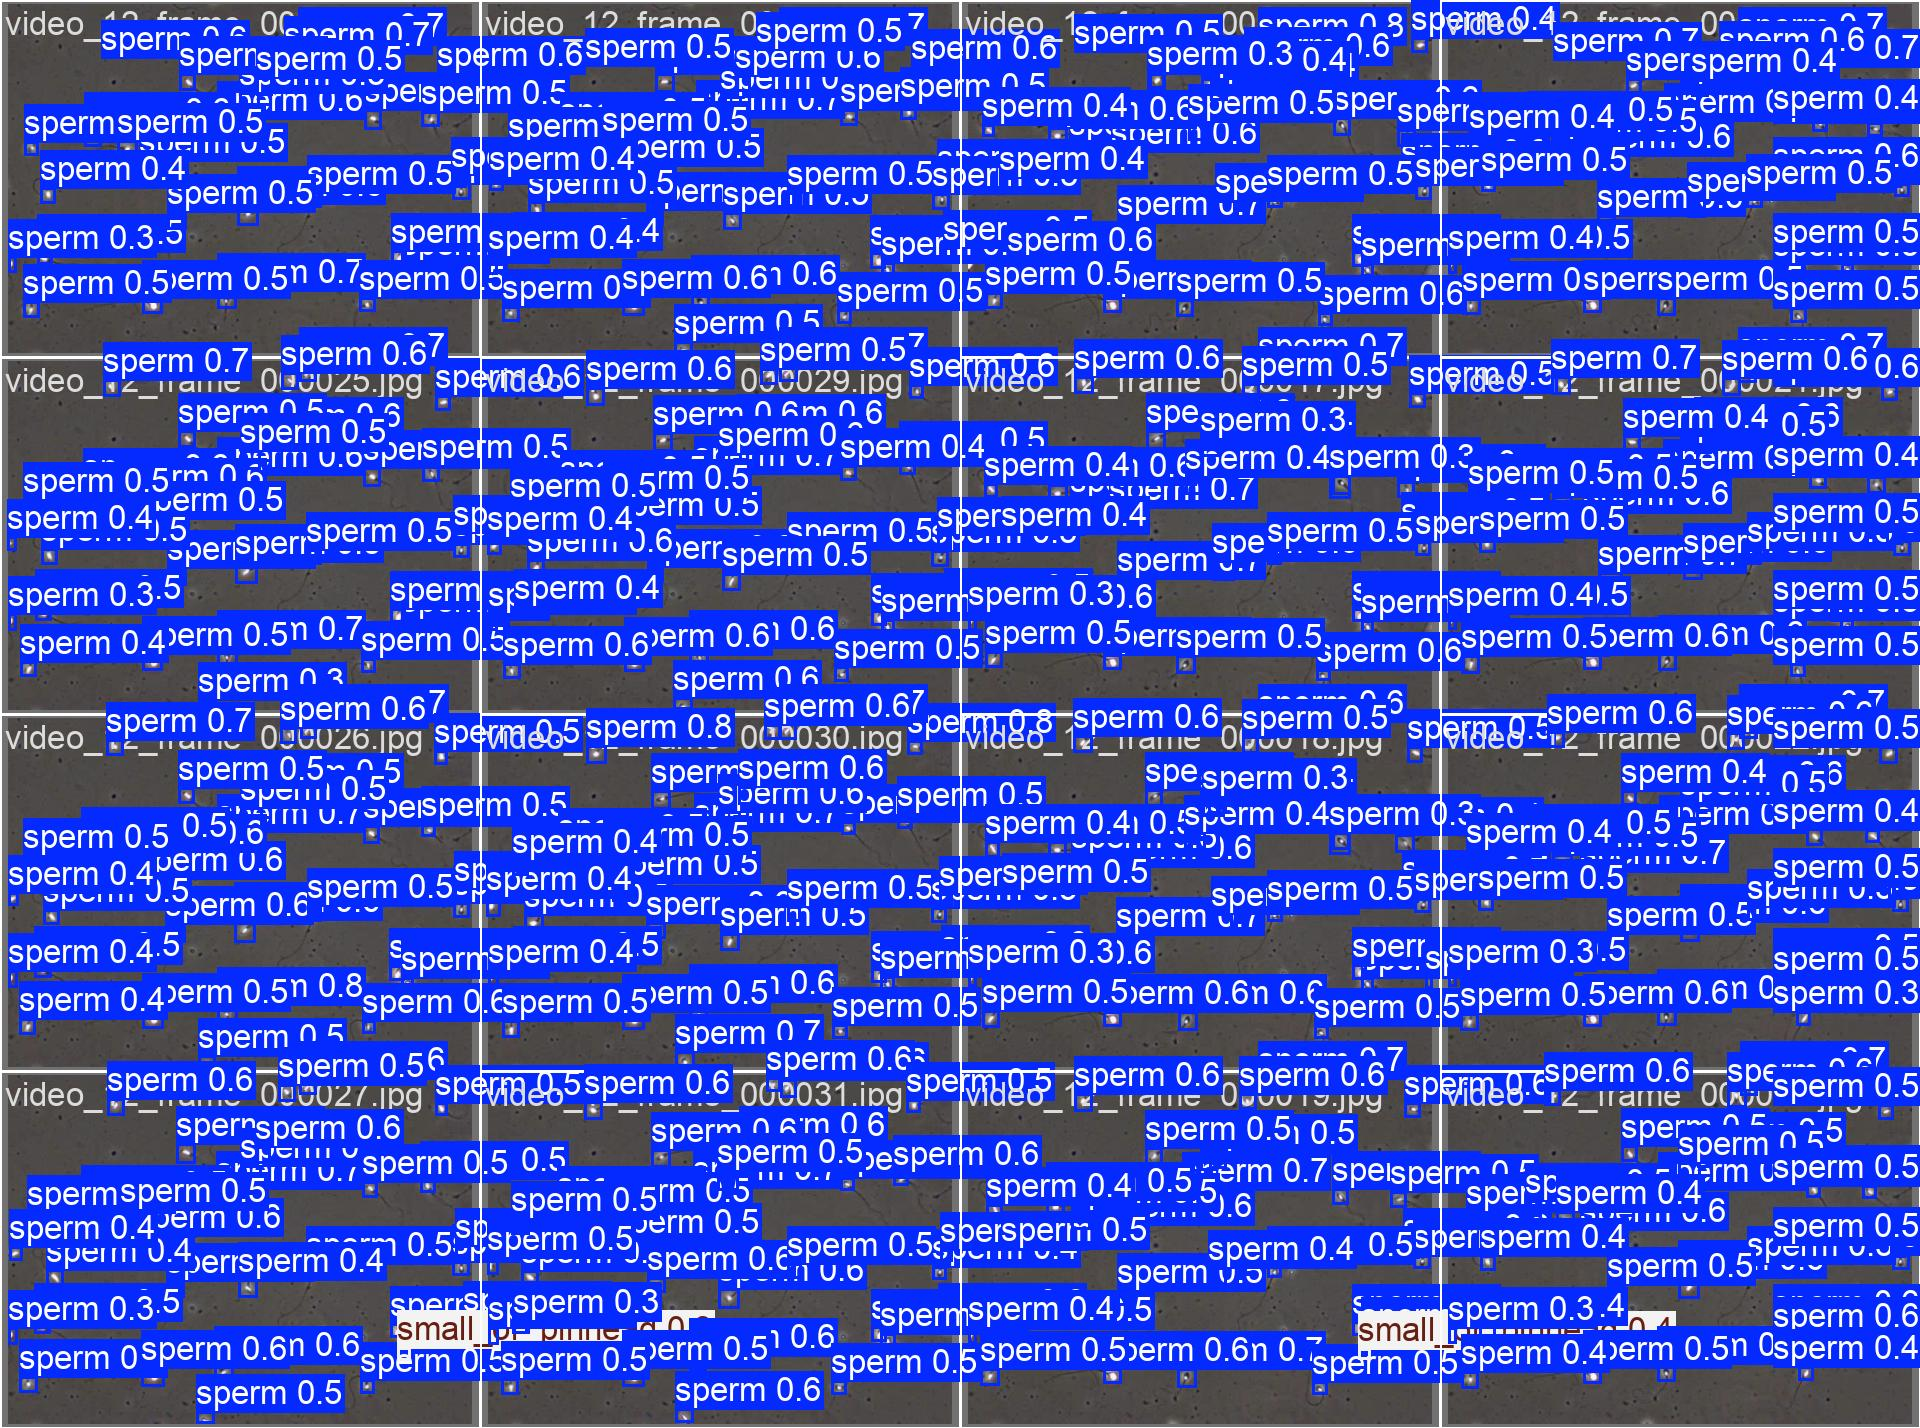

In [30]:
# ------------------------------------------------------------
# Ver gráficas generadas por YOLO
# ------------------------------------------------------------

from IPython.display import Image, display

important_plots = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "val_batch0_pred.jpg",
    "val_batch1_pred.jpg",
    "val_batch2_pred.jpg"
]

for plot_name in important_plots:
    plot_path = BEST_RUN_DIR / plot_name

    if plot_path.exists():
        print(plot_name)
        display(Image(filename=str(plot_path)))


Imágenes de test encontradas: 4410

0: 736x960 49 sperms, 21.4ms
1: 736x960 44 sperms, 21.4ms
2: 736x960 31 sperms, 21.4ms
3: 736x960 24 sperms, 21.4ms
4: 736x960 21 sperms, 21.4ms
5: 736x960 41 sperms, 21.4ms
Speed: 5.4ms preprocess, 21.4ms inference, 2.2ms postprocess per image at shape (1, 3, 736, 960)


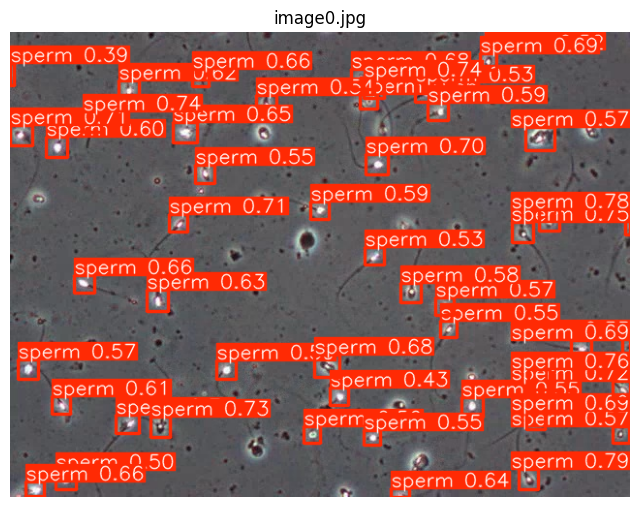

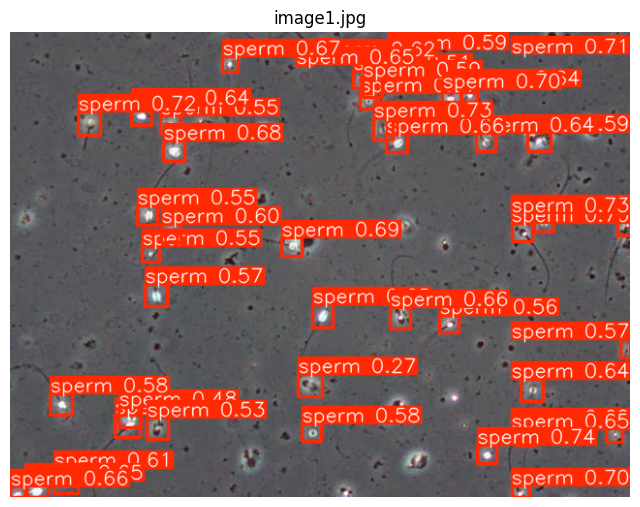

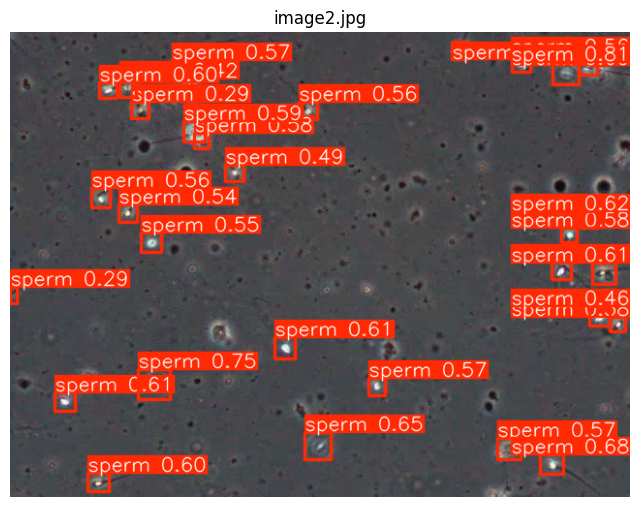

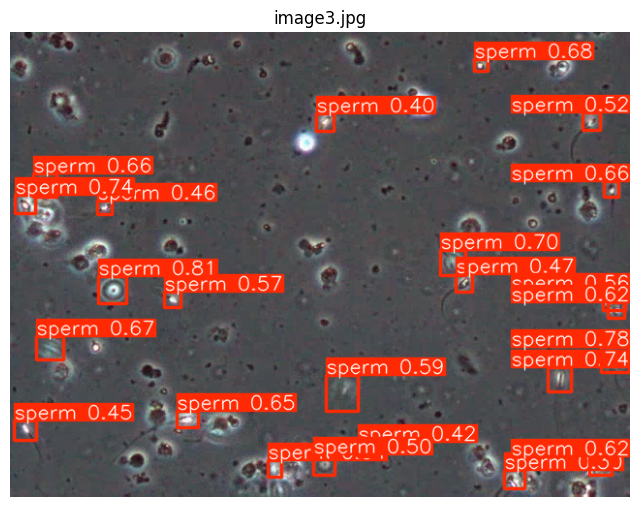

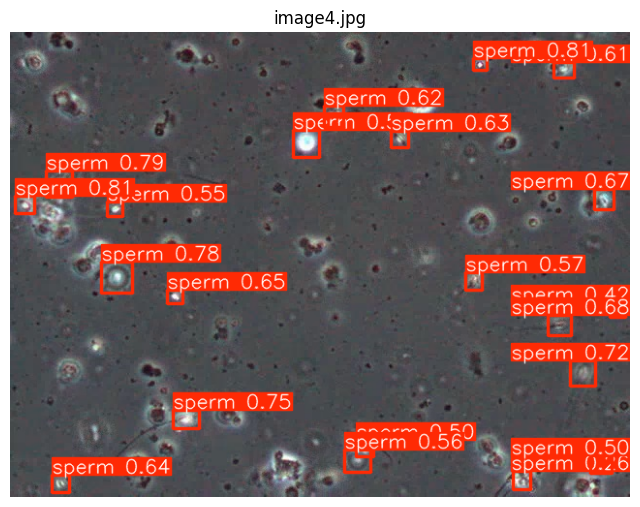

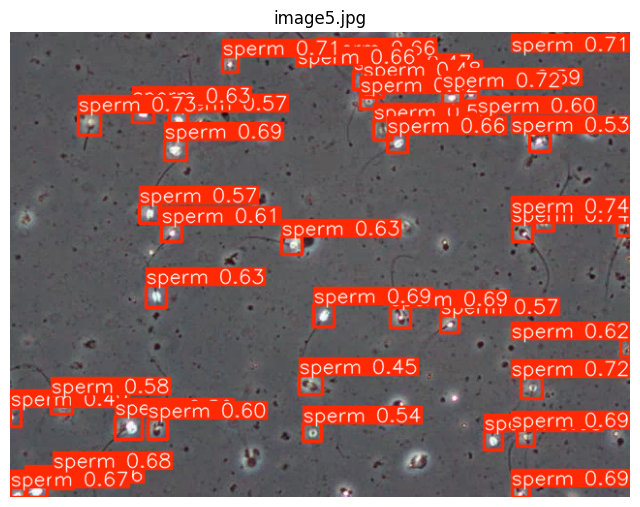

In [31]:
# ------------------------------------------------------------
# Predicciones visuales rápidas en test
# ------------------------------------------------------------

import random

test_images_dir = YOLO_DATASET_DIR / "images" / "test"

test_images = sorted([
    p for p in test_images_dir.glob("*")
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
])

print("Imágenes de test encontradas:", len(test_images))

sample_images = random.sample(test_images, min(6, len(test_images)))

pred_results = best_model.predict(
    source=[str(p) for p in sample_images],
    imgsz=VAL_IMG_SIZE,
    conf=0.25,
    iou=0.5,
    device=DEVICE,
    save=False,
    classes=[TARGET_CLASS_ID]  # visualizar solo sperm
)

for result in pred_results:
    plotted = result.plot()

    plt.figure(figsize=(8, 8))
    plt.imshow(plotted)
    plt.axis("off")
    plt.title(Path(result.path).name)
    plt.show()


## 12. Tracking definitivo: selección en validation y evaluación final en todos los videos de test

Esta sección implementa las mejoras finales sin usar los `track_id` reales para ayudar al tracker:

1. Tracking sobre video completo cuando el video original está disponible.
2. Filtro de tracking solo para `sperm`, aunque el detector haya sido entrenado multiclase.
3. Búsqueda de configuraciones de ByteTrack y BoT-SORT en **todos los videos de validation**.
4. Corrección de la métrica aproximada de precision/recall/F1.
5. Selección de parámetros de unión de fragmentos usando validation.
6. Evaluación final en **todos los videos de test**.

La métrica principal no exige que los IDs coincidan con el dataset, pero sí penaliza fragmentación: demasiados tracks predichos y trayectorias demasiado cortas.

In [32]:
# ============================================================
# Configuración general del experimento de tracking final mejorado
# ============================================================

import torch
from ultralytics import YOLO

DEVICE = 0 if torch.cuda.is_available() else "cpu"
TRACKING_OUT_DIR = PROJECT_DIR / "tracking_results_final_v2"
TRACKER_CONFIG_DIR = TRACKING_OUT_DIR / "tracker_configs"
TRACKING_OUT_DIR.mkdir(parents=True, exist_ok=True)
TRACKER_CONFIG_DIR.mkdir(parents=True, exist_ok=True)

print("Device usado para tracking:", DEVICE)
print("Resultados de tracking en:", TRACKING_OUT_DIR)

if "BEST_WEIGHTS_PATH" not in globals() or not Path(BEST_WEIGHTS_PATH).exists():
    RUNS_DIR = PROJECT_DIR / "runs"
    train_dirs = sorted(
        [p for p in RUNS_DIR.glob("*") if (p / "weights" / "best.pt").exists()],
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )

    if len(train_dirs) == 0:
        raise FileNotFoundError("No se encontró best.pt. Entrena YOLO antes de ejecutar tracking.")

    BEST_RUN_DIR = train_dirs[0]
    BEST_WEIGHTS_PATH = BEST_RUN_DIR / "weights" / "best.pt"
    LAST_WEIGHTS_PATH = BEST_RUN_DIR / "weights" / "last.pt"

print("Modelo usado para tracking:")
print(BEST_WEIGHTS_PATH)

# Adaptar ground truth de trayectorias al formato usado por las métricas.
if "trajectory_df" in globals():
    gt_all_df = trajectory_df.copy()
elif (TABLES_DIR / "sperm_trajectory_points.csv").exists():
    gt_all_df = pd.read_csv(TABLES_DIR / "sperm_trajectory_points.csv")
elif (TABLES_DIR / "usable_sperm_trajectory_points.csv").exists():
    gt_all_df = pd.read_csv(TABLES_DIR / "usable_sperm_trajectory_points.csv")
else:
    raise FileNotFoundError("No se encontraron trayectorias reales. Ejecuta primero el Paso 2.")

rename_map = {}
if "video_id" in gt_all_df.columns:
    rename_map["video_id"] = "video"
if "frame_number" in gt_all_df.columns:
    rename_map["frame_number"] = "frame"

gt_all_df = gt_all_df.rename(columns=rename_map).copy()
gt_all_df["video"] = gt_all_df["video"].astype(str)
gt_all_df["frame"] = gt_all_df["frame"].astype(int)
gt_all_df["track_id"] = gt_all_df["track_id"].astype(str)
gt_all_df["track_uid"] = gt_all_df["video"].astype(str) + "__gt_" + gt_all_df["track_id"].astype(str)

VAL_VIDEO_IDS = sorted([str(v) for v in val_videos], key=natural_sort_key)
TEST_VIDEO_IDS = sorted([str(v) for v in test_videos], key=natural_sort_key)

print("Ground truth cargado:")
print("Puntos:", len(gt_all_df))
print("Videos:", gt_all_df["video"].nunique())
print("Tracks:", gt_all_df["track_uid"].nunique())
print("Videos validation:", VAL_VIDEO_IDS)
print("Videos test:", TEST_VIDEO_IDS)

# Mejoras respecto al notebook anterior:
# - Se mantienen YOLOv8s e imgsz=960.
# - Se añaden umbrales intermedios de confianza para buscar mejor precision sin perder demasiado recall.
# - Se mantienen buffers altos porque el fallo principal fue fragmentación de identidad.
# - Se compara ByteTrack contra BoT-SORT, pero la selección sigue usando validation.
TRACKING_CONFIGS = [
    {
        "name": "bytetrack_baseline",
        "tracker_type": "bytetrack",
        "conf": 0.25,
        "iou": 0.50,
        "imgsz": VAL_IMG_SIZE,
        "track_high_thresh": 0.25,
        "track_low_thresh": 0.10,
        "new_track_thresh": 0.25,
        "track_buffer": 30,
        "match_thresh": 0.80,
        "fuse_score": True,
    },
    {
        "name": "bytetrack_conf012_buffer150",
        "tracker_type": "bytetrack",
        "conf": 0.12,
        "iou": 0.50,
        "imgsz": VAL_IMG_SIZE,
        "track_high_thresh": 0.18,
        "track_low_thresh": 0.04,
        "new_track_thresh": 0.18,
        "track_buffer": 150,
        "match_thresh": 0.90,
        "fuse_score": True,
    },
    {
        "name": "bytetrack_conf014_buffer150",
        "tracker_type": "bytetrack",
        "conf": 0.14,
        "iou": 0.50,
        "imgsz": VAL_IMG_SIZE,
        "track_high_thresh": 0.20,
        "track_low_thresh": 0.05,
        "new_track_thresh": 0.20,
        "track_buffer": 150,
        "match_thresh": 0.90,
        "fuse_score": True,
    },
    {
        "name": "bytetrack_conf016_buffer200",
        "tracker_type": "bytetrack",
        "conf": 0.16,
        "iou": 0.50,
        "imgsz": VAL_IMG_SIZE,
        "track_high_thresh": 0.22,
        "track_low_thresh": 0.05,
        "new_track_thresh": 0.22,
        "track_buffer": 200,
        "match_thresh": 0.88,
        "fuse_score": True,
    },
    {
        "name": "bytetrack_conf018_buffer200",
        "tracker_type": "bytetrack",
        "conf": 0.18,
        "iou": 0.50,
        "imgsz": VAL_IMG_SIZE,
        "track_high_thresh": 0.24,
        "track_low_thresh": 0.06,
        "new_track_thresh": 0.24,
        "track_buffer": 200,
        "match_thresh": 0.88,
        "fuse_score": True,
    },
    {
        "name": "bytetrack_conf020_buffer250",
        "tracker_type": "bytetrack",
        "conf": 0.20,
        "iou": 0.50,
        "imgsz": VAL_IMG_SIZE,
        "track_high_thresh": 0.26,
        "track_low_thresh": 0.07,
        "new_track_thresh": 0.26,
        "track_buffer": 250,
        "match_thresh": 0.86,
        "fuse_score": True,
    },
    {
        "name": "botsort_conf014_buffer150",
        "tracker_type": "botsort",
        "conf": 0.14,
        "iou": 0.50,
        "imgsz": VAL_IMG_SIZE,
        "track_high_thresh": 0.20,
        "track_low_thresh": 0.05,
        "new_track_thresh": 0.20,
        "track_buffer": 150,
        "match_thresh": 0.85,
        "fuse_score": True,
        "gmc_method": "sparseOptFlow",
        "proximity_thresh": 0.50,
        "appearance_thresh": 0.25,
        "with_reid": False,
    },
]

# None usa todos los frames. Para debug rápido puedes poner 300.
MAX_FRAMES_PER_TRACKING_RUN = None

print("Configuraciones a probar:")
display(pd.DataFrame(TRACKING_CONFIGS))


Device usado para tracking: 0
Resultados de tracking en: /kaggle/working/visem_tracking_project/tracking_results_final_v2
Modelo usado para tracking:
/kaggle/working/visem_tracking_project/runs/visem_multiclass_yolov8s_img960/weights/best.pt
Ground truth cargado:
Puntos: 612377
Videos: 20
Tracks: 1121
Videos validation: ['12', '23', '47']
Videos test: ['11', '19', '54']
Configuraciones a probar:


,name,tracker_type,conf,iou,imgsz,track_high_thresh,track_low_thresh,new_track_thresh,track_buffer,match_thresh,fuse_score,gmc_method,proximity_thresh,appearance_thresh,with_reid
0,bytetrack_baseline,bytetrack,0.25,0.5,960,0.25,0.10,0.25,30,0.80,True,NaN,NaN,NaN,NaN
1,bytetrack_conf012_buffer150,bytetrack,0.12,0.5,960,0.18,0.04,0.18,150,0.90,True,NaN,NaN,NaN,NaN
2,bytetrack_conf014_buffer150,bytetrack,0.14,0.5,960,0.20,0.05,0.20,150,0.90,True,NaN,NaN,NaN,NaN
3,bytetrack_conf016_buffer200,bytetrack,0.16,0.5,960,0.22,0.05,0.22,200,0.88,True,NaN,NaN,NaN,NaN
4,bytetrack_conf018_buffer200,bytetrack,0.18,0.5,960,0.24,0.06,0.24,200,0.88,True,NaN,NaN,NaN,NaN
5,bytetrack_conf020_buffer250,bytetrack,0.20,0.5,960,0.26,0.07,0.26,250,0.86,True,NaN,NaN,NaN,NaN
6,botsort_conf014_buffer150,botsort,0.14,0.5,960,0.20,0.05,0.20,150,0.85,True,sparseOptFlow,0.5,0.25,False


In [33]:
# ============================================================
# Funciones auxiliares: trackers, ejecución, métricas, merge y gráficas
# ============================================================


def write_tracker_yaml(config):
    tracker_type = config["tracker_type"]
    yaml_path = TRACKER_CONFIG_DIR / f"{config['name']}.yaml"

    data = {
        "tracker_type": tracker_type,
        "track_high_thresh": float(config["track_high_thresh"]),
        "track_low_thresh": float(config["track_low_thresh"]),
        "new_track_thresh": float(config["new_track_thresh"]),
        "track_buffer": int(config["track_buffer"]),
        "match_thresh": float(config["match_thresh"]),
        "fuse_score": bool(config["fuse_score"]),
    }

    if tracker_type == "botsort":
        data.update({
            "gmc_method": config.get("gmc_method", "sparseOptFlow"),
            "proximity_thresh": float(config.get("proximity_thresh", 0.5)),
            "appearance_thresh": float(config.get("appearance_thresh", 0.25)),
            "with_reid": bool(config.get("with_reid", False)),
        })

    with open(yaml_path, "w") as f:
        yaml.dump(data, f, sort_keys=False)

    return yaml_path


def get_yolo_images_for_video(video_id, split=None):
    video_id = str(video_id)
    search_dirs = []

    if split is not None:
        search_dirs.append(YOLO_DATASET_DIR / "images" / split)
    else:
        search_dirs.extend([YOLO_DATASET_DIR / "images" / s for s in ["train", "val", "test"]])

    image_rows = []
    pattern = re.compile(rf"video_{re.escape(video_id)}_frame_(\d+)")

    for image_dir in search_dirs:
        if not image_dir.exists():
            continue
        for image_path in image_dir.glob("*.jpg"):
            match = pattern.search(image_path.stem)
            if match:
                image_rows.append({
                    "image_path": image_path,
                    "frame": int(match.group(1))
                })

    if len(image_rows) == 0:
        return pd.DataFrame(columns=["image_path", "frame"])

    return pd.DataFrame(image_rows).sort_values("frame").reset_index(drop=True)


def run_tracking_for_video(video_id, config, split=None, max_frames=None, save_csv=True):
    video_id = str(video_id)
    tracker_yaml = write_tracker_yaml(config)
    rows = []

    model = YOLO(str(BEST_WEIGHTS_PATH))
    use_original_video = "video_index" in globals() and video_id in video_index

    if use_original_video:
        source = str(video_index[video_id])
        print(f"Ejecutando {config['name']} sobre video original {video_id}: {source}")

        results_stream = model.track(
            source=source,
            stream=True,
            tracker=str(tracker_yaml),
            imgsz=int(config["imgsz"]),
            conf=float(config["conf"]),
            iou=float(config["iou"]),
            device=DEVICE,
            persist=True,
            verbose=False,
            save=False,
            classes=[TARGET_CLASS_ID],
        )

        for frame_idx, result in enumerate(results_stream):
            if max_frames is not None and frame_idx >= max_frames:
                break

            if result.boxes is None or len(result.boxes) == 0 or result.boxes.id is None:
                continue

            xywhn = result.boxes.xywhn.cpu().numpy()
            confs = result.boxes.conf.cpu().numpy()
            ids = result.boxes.id.cpu().numpy().astype(int)

            for box, conf, track_id in zip(xywhn, confs, ids):
                x_center, y_center, width, height = box
                rows.append({
                    "video": video_id,
                    "frame": int(frame_idx),
                    "track_id": str(track_id),
                    "x_center": float(x_center),
                    "y_center": float(y_center),
                    "width": float(width),
                    "height": float(height),
                    "confidence": float(conf),
                    "tracker_config": config["name"],
                    "source_mode": "video",
                })

    else:
        image_df = get_yolo_images_for_video(video_id, split=split)

        if image_df.empty:
            raise FileNotFoundError(f"No se encontró video original ni imágenes YOLO para video {video_id}.")

        if max_frames is not None:
            image_df = image_df.head(max_frames)

        print(f"Ejecutando {config['name']} sobre imágenes del video {video_id}. Frames: {len(image_df)}")

        for _, img_row in tqdm(image_df.iterrows(), total=len(image_df), desc=f"Tracking {video_id} {config['name']}"):
            result = model.track(
                source=str(img_row["image_path"]),
                tracker=str(tracker_yaml),
                imgsz=int(config["imgsz"]),
                conf=float(config["conf"]),
                iou=float(config["iou"]),
                device=DEVICE,
                persist=True,
                verbose=False,
                save=False,
                classes=[TARGET_CLASS_ID],
            )[0]

            if result.boxes is None or len(result.boxes) == 0 or result.boxes.id is None:
                continue

            xywhn = result.boxes.xywhn.cpu().numpy()
            confs = result.boxes.conf.cpu().numpy()
            ids = result.boxes.id.cpu().numpy().astype(int)

            for box, conf, track_id in zip(xywhn, confs, ids):
                x_center, y_center, width, height = box
                rows.append({
                    "video": video_id,
                    "frame": int(img_row["frame"]),
                    "track_id": str(track_id),
                    "x_center": float(x_center),
                    "y_center": float(y_center),
                    "width": float(width),
                    "height": float(height),
                    "confidence": float(conf),
                    "tracker_config": config["name"],
                    "source_mode": "images",
                })

    pred_df = pd.DataFrame(rows)

    if pred_df.empty:
        pred_df = pd.DataFrame(columns=[
            "video", "frame", "track_id", "x_center", "y_center", "width", "height",
            "confidence", "tracker_config", "source_mode", "track_uid"
        ])
    else:
        pred_df["track_uid"] = pred_df["video"].astype(str) + "__pred_" + pred_df["track_id"].astype(str)
        pred_df = pred_df.sort_values(["video", "track_id", "frame"]).reset_index(drop=True)

    if save_csv:
        out_csv = TRACKING_OUT_DIR / f"pred_tracks_{video_id}_{config['name']}.csv"
        pred_df.to_csv(out_csv, index=False)

    print(f"Video {video_id} | {config['name']} | puntos={len(pred_df)} | tracks={pred_df['track_uid'].nunique() if not pred_df.empty else 0}")
    return pred_df


def box_xywh_to_xyxy(df):
    if len(df) == 0:
        return np.empty((0, 4))
    x1 = df["x_center"].to_numpy() - df["width"].to_numpy() / 2
    y1 = df["y_center"].to_numpy() - df["height"].to_numpy() / 2
    x2 = df["x_center"].to_numpy() + df["width"].to_numpy() / 2
    y2 = df["y_center"].to_numpy() + df["height"].to_numpy() / 2
    return np.stack([x1, y1, x2, y2], axis=1)


def compute_iou_matrix(boxes_a, boxes_b):
    if len(boxes_a) == 0 or len(boxes_b) == 0:
        return np.zeros((len(boxes_a), len(boxes_b)))
    ax1, ay1, ax2, ay2 = boxes_a[:, 0], boxes_a[:, 1], boxes_a[:, 2], boxes_a[:, 3]
    bx1, by1, bx2, by2 = boxes_b[:, 0], boxes_b[:, 1], boxes_b[:, 2], boxes_b[:, 3]
    inter_x1 = np.maximum(ax1[:, None], bx1[None, :])
    inter_y1 = np.maximum(ay1[:, None], by1[None, :])
    inter_x2 = np.minimum(ax2[:, None], bx2[None, :])
    inter_y2 = np.minimum(ay2[:, None], by2[None, :])
    inter_area = np.maximum(0, inter_x2 - inter_x1) * np.maximum(0, inter_y2 - inter_y1)
    area_a = np.maximum(0, ax2 - ax1) * np.maximum(0, ay2 - ay1)
    area_b = np.maximum(0, bx2 - bx1) * np.maximum(0, by2 - by1)
    union = area_a[:, None] + area_b[None, :] - inter_area
    return inter_area / np.maximum(union, 1e-9)


def greedy_match_by_iou(iou_matrix, threshold=0.3):
    matches = []
    if iou_matrix.size == 0:
        return matches
    iou_copy = iou_matrix.copy()
    while True:
        gt_idx, pred_idx = np.unravel_index(np.argmax(iou_copy), iou_copy.shape)
        max_iou = iou_copy[gt_idx, pred_idx]
        if max_iou < threshold:
            break
        matches.append((gt_idx, pred_idx, float(max_iou)))
        iou_copy[gt_idx, :] = -1
        iou_copy[:, pred_idx] = -1
    return matches


def summarize_tracks(df):
    if df.empty:
        return pd.DataFrame(columns=["track_uid", "n_frames", "first_frame", "last_frame"])
    if "track_uid" not in df.columns:
        df = df.copy()
        df["track_uid"] = df["video"].astype(str) + "__" + df["track_id"].astype(str)
    agg = {
        "n_frames": ("frame", "nunique"),
        "first_frame": ("frame", "min"),
        "last_frame": ("frame", "max"),
    }
    if "confidence" in df.columns:
        agg["mean_confidence"] = ("confidence", "mean")
    return df.groupby("track_uid").agg(**agg).reset_index()


def evaluate_tracking(gt_df, pred_df, video_id, config_name="unknown", iou_threshold=0.3):
    video_id = str(video_id)
    gt_video_df = gt_df[gt_df["video"].astype(str) == video_id].copy()
    pred_video_df = pred_df[pred_df["video"].astype(str) == video_id].copy()

    gt_video_df["track_uid"] = gt_video_df["video"].astype(str) + "__gt_" + gt_video_df["track_id"].astype(str)
    if not pred_video_df.empty and "track_uid" not in pred_video_df.columns:
        pred_video_df["track_uid"] = pred_video_df["video"].astype(str) + "__pred_" + pred_video_df["track_id"].astype(str)

    # Evaluamos solo dentro del rango anotado del ground truth para no castigar frames sin anotación.
    if not gt_video_df.empty:
        min_frame = int(gt_video_df["frame"].min())
        max_frame = int(gt_video_df["frame"].max())
        pred_video_df = pred_video_df[
            (pred_video_df["frame"] >= min_frame) &
            (pred_video_df["frame"] <= max_frame)
        ].copy()

    all_frames = sorted(set(gt_video_df["frame"].unique()) | set(pred_video_df["frame"].unique()))

    tp, fp, fn = 0, 0, 0
    ious_matched = []

    for frame in all_frames:
        gt_frame = gt_video_df[gt_video_df["frame"] == frame]
        pred_frame = pred_video_df[pred_video_df["frame"] == frame]
        gt_boxes = box_xywh_to_xyxy(gt_frame)
        pred_boxes = box_xywh_to_xyxy(pred_frame)
        matches = greedy_match_by_iou(compute_iou_matrix(gt_boxes, pred_boxes), threshold=iou_threshold)
        tp += len(matches)
        fp += max(0, len(pred_boxes) - len(matches))
        fn += max(0, len(gt_boxes) - len(matches))
        ious_matched.extend([m[2] for m in matches])

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    mean_iou = np.mean(ious_matched) if len(ious_matched) > 0 else 0

    gt_track_summary = summarize_tracks(gt_video_df)
    pred_track_summary = summarize_tracks(pred_video_df)

    gt_tracks = gt_video_df["track_uid"].nunique()
    pred_tracks = pred_video_df["track_uid"].nunique() if not pred_video_df.empty else 0
    gt_median = gt_track_summary["n_frames"].median() if len(gt_track_summary) else 0
    pred_median = pred_track_summary["n_frames"].median() if len(pred_track_summary) else 0

    track_count_similarity = min(pred_tracks / max(gt_tracks, 1), gt_tracks / max(pred_tracks, 1)) if pred_tracks > 0 else 0
    duration_similarity = min(pred_median / max(gt_median, 1), 1.0) if gt_median > 0 else 0
    point_count_similarity = min(len(pred_video_df) / max(len(gt_video_df), 1), len(gt_video_df) / max(len(pred_video_df), 1)) if len(pred_video_df) > 0 else 0

    # Score diagnóstico balanceado. En esta versión se penaliza más la baja precision
    # porque el último notebook tenía recall alto, pero demasiados falsos positivos y tracks extra.
    diagnostic_score = (
        0.30 * f1 +
        0.30 * precision +
        0.20 * duration_similarity +
        0.15 * track_count_similarity +
        0.05 * point_count_similarity
    )

    metrics = {
        "video": video_id,
        "config": config_name,
        "iou_threshold": iou_threshold,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision_aprox": precision,
        "recall_aprox": recall,
        "f1_aprox": f1,
        "mean_iou_matched": mean_iou,
        "gt_points": len(gt_video_df),
        "pred_points": len(pred_video_df),
        "gt_tracks": gt_tracks,
        "pred_tracks": pred_tracks,
        "track_ratio_pred_gt": pred_tracks / max(gt_tracks, 1),
        "gt_mean_frames_per_track": gt_track_summary["n_frames"].mean() if len(gt_track_summary) else 0,
        "pred_mean_frames_per_track": pred_track_summary["n_frames"].mean() if len(pred_track_summary) else 0,
        "gt_median_frames_per_track": gt_median,
        "pred_median_frames_per_track": pred_median,
        "track_count_similarity": track_count_similarity,
        "duration_similarity": duration_similarity,
        "point_count_similarity": point_count_similarity,
        "diagnostic_score": diagnostic_score,
    }

    return metrics, gt_video_df, pred_video_df, gt_track_summary, pred_track_summary


def aggregate_metrics(metrics_rows, config_name):
    """Promedia solo columnas numéricas para evitar errores con texto como stage, merge_config o postprocess_config."""
    df = pd.DataFrame(metrics_rows)
    if df.empty:
        return {"config": config_name, "n_videos": 0}

    out = {
        "config": config_name,
        "n_videos": df["video"].nunique() if "video" in df.columns else len(df)
    }

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    ignore_cols = ["video"]

    for col in numeric_cols:
        if col not in ignore_cols:
            out[col] = df[col].mean()

    if "video" in df.columns:
        out["videos"] = ",".join(df["video"].astype(str).tolist())

    return out


def merge_fragmented_tracks(
    pred_df,
    max_gap=25,
    max_distance=0.055,
    max_size_ratio=3.0,
    velocity_window=5,
    velocity_weight=0.50,
):
    """
    Une tracks predichos compatibles sin usar IDs reales.
    Reglas usadas: no solape temporal, gap pequeño, cercanía espacial, tamaño parecido y predicción simple por velocidad.
    """
    if pred_df.empty:
        return pred_df.copy(), pd.DataFrame()

    df = pred_df.copy().sort_values(["track_uid", "frame"]).reset_index(drop=True)

    summaries = []
    for track_uid, group in df.groupby("track_uid"):
        group = group.sort_values("frame")
        start = group.iloc[0]
        end = group.iloc[-1]

        tail = group.tail(max(2, velocity_window))
        if len(tail) >= 2 and (tail["frame"].iloc[-1] - tail["frame"].iloc[0]) > 0:
            dt_tail = tail["frame"].iloc[-1] - tail["frame"].iloc[0]
            vx_end = (tail["x_center"].iloc[-1] - tail["x_center"].iloc[0]) / dt_tail
            vy_end = (tail["y_center"].iloc[-1] - tail["y_center"].iloc[0]) / dt_tail
        else:
            vx_end, vy_end = 0.0, 0.0

        summaries.append({
            "track_uid": track_uid,
            "first_frame": int(start["frame"]),
            "last_frame": int(end["frame"]),
            "start_x": float(start["x_center"]),
            "start_y": float(start["y_center"]),
            "end_x": float(end["x_center"]),
            "end_y": float(end["y_center"]),
            "vx_end": float(vx_end),
            "vy_end": float(vy_end),
            "mean_width": float(group["width"].mean()),
            "mean_height": float(group["height"].mean()),
            "n_frames": int(group["frame"].nunique()),
        })

    summary = pd.DataFrame(summaries).sort_values("first_frame").reset_index(drop=True)
    parent = {uid: uid for uid in summary["track_uid"]}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    merge_rows = []

    for _, b in summary.iterrows():
        candidates = summary[
            (summary["last_frame"] < b["first_frame"]) &
            ((b["first_frame"] - summary["last_frame"]) <= max_gap)
        ].copy()

        if candidates.empty:
            continue

        candidates["gap"] = b["first_frame"] - candidates["last_frame"]
        candidates["distance_direct"] = np.sqrt(
            (candidates["end_x"] - b["start_x"]) ** 2 +
            (candidates["end_y"] - b["start_y"]) ** 2
        )

        pred_x = candidates["end_x"] + candidates["vx_end"] * candidates["gap"]
        pred_y = candidates["end_y"] + candidates["vy_end"] * candidates["gap"]
        candidates["distance_velocity"] = np.sqrt((pred_x - b["start_x"]) ** 2 + (pred_y - b["start_y"]) ** 2)

        size_ratio_w = np.maximum(candidates["mean_width"], b["mean_width"]) / np.maximum(
            np.minimum(candidates["mean_width"], b["mean_width"]), 1e-9
        )
        size_ratio_h = np.maximum(candidates["mean_height"], b["mean_height"]) / np.maximum(
            np.minimum(candidates["mean_height"], b["mean_height"]), 1e-9
        )
        candidates["size_ratio"] = np.maximum(size_ratio_w, size_ratio_h)

        candidates = candidates[
            (candidates["distance_direct"] <= max_distance) &
            (candidates["distance_velocity"] <= max_distance * 1.5) &
            (candidates["size_ratio"] <= max_size_ratio)
        ].copy()

        if candidates.empty:
            continue

        candidates["score"] = (
            candidates["distance_direct"] +
            velocity_weight * candidates["distance_velocity"] +
            0.002 * candidates["gap"] +
            0.010 * np.maximum(0, candidates["size_ratio"] - 1)
        )

        best = candidates.sort_values("score").iloc[0]
        union(best["track_uid"], b["track_uid"])

        merge_rows.append({
            "from_track": b["track_uid"],
            "to_track": best["track_uid"],
            "gap": int(best["gap"]),
            "distance_direct": float(best["distance_direct"]),
            "distance_velocity": float(best["distance_velocity"]),
            "size_ratio": float(best["size_ratio"]),
            "score": float(best["score"]),
        })

    merge_map = {uid: find(uid) for uid in parent}
    merged_df = df.copy()
    merged_df["original_track_uid"] = merged_df["track_uid"]
    merged_df["track_uid"] = merged_df["track_uid"].map(merge_map)
    merged_df["track_id"] = merged_df["track_uid"].astype(str).str.replace(r"^.*__pred_", "", regex=True)

    merges_df = pd.DataFrame(merge_rows)
    return merged_df.sort_values(["track_uid", "frame"]).reset_index(drop=True), merges_df



def filter_short_or_low_conf_tracks(pred_df, min_track_frames=0, min_mean_confidence=None):
    """Filtra trayectorias predichas demasiado cortas o con baja confianza media.

    Esta mejora ataca dos fallos vistos en el último notebook:
    1. demasiados tracks predichos frente al ground truth;
    2. falsos positivos que suelen aparecer como trayectorias muy cortas.

    No usa track_id real, solo propiedades de la predicción.
    """
    if pred_df.empty:
        return pred_df.copy()

    df = pred_df.copy()
    if "track_uid" not in df.columns:
        df["track_uid"] = df["video"].astype(str) + "__pred_" + df["track_id"].astype(str)

    summary = summarize_tracks(df)

    keep = summary.copy()
    if min_track_frames and min_track_frames > 0:
        keep = keep[keep["n_frames"] >= int(min_track_frames)]

    if min_mean_confidence is not None and "mean_confidence" in keep.columns:
        keep = keep[keep["mean_confidence"] >= float(min_mean_confidence)]

    keep_uids = set(keep["track_uid"].astype(str))
    return df[df["track_uid"].astype(str).isin(keep_uids)].copy().reset_index(drop=True)


def apply_postprocess(pred_df, post_cfg):
    """Aplica merge y filtrado de tracks cortos usando una configuración seleccionada en validation."""
    working_df = pred_df.copy()
    all_merges_df = pd.DataFrame()

    if post_cfg.get("apply_merge", False):
        working_df, all_merges_df = merge_fragmented_tracks(
            working_df,
            max_gap=post_cfg.get("max_gap", 25),
            max_distance=post_cfg.get("max_distance", 0.055),
            max_size_ratio=post_cfg.get("max_size_ratio", 3.0),
            velocity_window=post_cfg.get("velocity_window", 5),
            velocity_weight=post_cfg.get("velocity_weight", 0.50),
        )

    working_df = filter_short_or_low_conf_tracks(
        working_df,
        min_track_frames=post_cfg.get("min_track_frames", 0),
        min_mean_confidence=post_cfg.get("min_mean_confidence", None),
    )

    if not working_df.empty:
        working_df["postprocess_config"] = post_cfg["name"]

    return working_df, all_merges_df


def plot_tracks(ax, df, title, max_tracks=45, min_frames=5):
    if df.empty:
        ax.set_title(title + " vacío")
        ax.set_xlim(0, 1)
        ax.set_ylim(1, 0)
        return

    if "track_uid" not in df.columns:
        df = df.copy()
        df["track_uid"] = df["video"].astype(str) + "__" + df["track_id"].astype(str)

    summary = summarize_tracks(df)
    selected_tracks = (
        summary[summary["n_frames"] >= min_frames]
        .sort_values("n_frames", ascending=False)
        .head(max_tracks)["track_uid"]
        .tolist()
    )
    plot_df = df[df["track_uid"].isin(selected_tracks)].copy()

    for _, group in plot_df.groupby("track_uid"):
        group = group.sort_values("frame")
        ax.plot(group["x_center"], group["y_center"], linewidth=1, alpha=0.8)
        ax.scatter(group["x_center"].iloc[0], group["y_center"].iloc[0], marker="o", s=15)
        ax.scatter(group["x_center"].iloc[-1], group["y_center"].iloc[-1], marker="x", s=20)

    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)
    ax.set_xlabel("x_center normalizado")
    ax.set_ylabel("y_center normalizado")
    ax.set_title(title)
    ax.grid(alpha=0.3)


In [34]:
# ============================================================
# 1) Búsqueda de la mejor configuración de tracker en validation
# ============================================================

validation_raw_rows = []
validation_predictions = {}

for config in TRACKING_CONFIGS:
    print("\n" + "=" * 90)
    print("Probando configuración en validation:", config["name"])
    print("=" * 90)

    config_video_metrics = []
    config_pred_dfs = []

    for video_id in VAL_VIDEO_IDS:
        pred_df = run_tracking_for_video(
            video_id=video_id,
            config=config,
            split="val",
            max_frames=MAX_FRAMES_PER_TRACKING_RUN,
            save_csv=True,
        )

        metrics, _, _, _, _ = evaluate_tracking(
            gt_all_df,
            pred_df,
            video_id=video_id,
            config_name=config["name"],
            iou_threshold=0.3,
        )

        validation_raw_rows.append(metrics)
        config_video_metrics.append(metrics)
        config_pred_dfs.append(pred_df)

    validation_predictions[config["name"]] = pd.concat(config_pred_dfs, ignore_index=True) if config_pred_dfs else pd.DataFrame()

validation_raw_metrics_df = pd.DataFrame(validation_raw_rows)
validation_raw_agg_df = pd.DataFrame([
    aggregate_metrics(validation_raw_metrics_df[validation_raw_metrics_df["config"] == config["name"]].to_dict("records"), config["name"])
    for config in TRACKING_CONFIGS
]).sort_values("diagnostic_score", ascending=False).reset_index(drop=True)

print("Resultados raw en validation, agregados por configuración:")
display(validation_raw_agg_df)

validation_raw_metrics_df.to_csv(TRACKING_OUT_DIR / "validation_raw_metrics_by_video.csv", index=False)
validation_raw_agg_df.to_csv(TRACKING_OUT_DIR / "validation_raw_metrics_aggregated.csv", index=False)

BEST_RAW_CONFIG_NAME = validation_raw_agg_df.iloc[0]["config"]
BEST_RAW_CONFIG = next(c for c in TRACKING_CONFIGS if c["name"] == BEST_RAW_CONFIG_NAME)

print("Mejor configuración raw desde validation:", BEST_RAW_CONFIG_NAME)



Probando configuración en validation: bytetrack_baseline
Ejecutando bytetrack_baseline sobre video original 12: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/12/12.mp4
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 204ms
 Downloaded lap
Prepared 1 package in 56ms
Installed 1 package in 4ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Video 12 | bytetrack_baseline | puntos=33638 | tracks=1361
Ejecutando bytetrack_baseline sobre video original 23: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/23/23.mp4
Video 23 | bytetrack_baseline | puntos=5796 | tracks=28
Ejecutando bytetrack_baseline sobre video original 47: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/47

,config,n_videos,iou_threshold,tp,fp,fn,precision_aprox,recall_aprox,f1_aprox,mean_iou_matched,gt_points,pred_points,gt_tracks,pred_tracks,track_ratio_pred_gt,gt_mean_frames_per_track,pred_mean_frames_per_track,gt_median_frames_per_track,pred_median_frames_per_track,track_count_similarity,duration_similarity,point_count_similarity,diagnostic_score,videos
0,bytetrack_conf012_buffer150,3,0.3,14280.000000,3888.333333,600.333333,0.660491,0.968884,0.771477,0.617324,14880.333333,18168.333333,47.333333,128.000000,2.477934,328.541683,217.605890,226.5,105.000000,0.410144,0.464994,0.684399,0.618331,"12,23,47"
1,bytetrack_conf014_buffer150,3,0.3,14276.666667,3819.000000,603.666667,0.664253,0.968607,0.774443,0.617293,14880.333333,18095.666667,47.333333,126.333333,2.474409,328.541683,214.891661,226.5,93.500000,0.409151,0.422578,0.688451,0.611920,"12,23,47"
2,bytetrack_conf016_buffer200,3,0.3,14134.666667,3678.000000,745.666667,0.669712,0.964381,0.776577,0.617448,14880.333333,17812.666667,47.333333,166.666667,2.837773,328.541683,201.089387,226.5,85.000000,0.375643,0.375210,0.698183,0.600184,"12,23,47"
3,bytetrack_conf018_buffer200,3,0.3,14127.666667,3593.333333,752.666667,0.673576,0.963856,0.779328,0.617454,14880.333333,17721.000000,47.333333,166.333333,2.834770,328.541683,199.474585,226.5,78.500000,0.375842,0.347441,0.702547,0.596863,"12,23,47"
4,botsort_conf014_buffer150,3,0.3,13954.000000,3647.666667,926.333333,0.667680,0.958531,0.771773,0.619236,14880.333333,17601.666667,47.333333,243.333333,3.601596,328.541683,183.516550,226.5,77.833333,0.330737,0.334210,0.701845,0.583381,"12,23,47"
5,bytetrack_conf020_buffer250,3,0.3,13947.000000,3495.333333,933.333333,0.677469,0.958185,0.779674,0.617778,14880.333333,17442.333333,47.333333,226.000000,3.433950,328.541683,181.782793,226.5,60.333333,0.338367,0.259104,0.712156,0.575326,"12,23,47"
6,bytetrack_baseline,3,0.3,13276.000000,3448.666667,1604.333333,0.675432,0.936432,0.767899,0.618634,14880.333333,16724.666667,47.333333,489.333333,6.398681,328.541683,122.555006,226.5,24.833333,0.219470,0.103580,0.716205,0.522446,"12,23,47"


Mejor configuración raw desde validation: bytetrack_conf012_buffer150


In [35]:
# ============================================================
# 2) Selección de postprocesamiento usando validation
# ============================================================

# Fallo observado antes: seguían apareciendo demasiados tracks predichos.
# Mejora: además de unir fragmentos, probamos filtrado de tracks muy cortos.
# Esto se elige con validation, no con test.
POSTPROCESS_CONFIGS = [
    {
        "name": "no_postprocess",
        "apply_merge": False,
        "min_track_frames": 0,
        "min_mean_confidence": None,
    },
    {
        "name": "merge_balanced_keep_all",
        "apply_merge": True,
        "max_gap": 25,
        "max_distance": 0.055,
        "max_size_ratio": 3.0,
        "velocity_window": 5,
        "velocity_weight": 0.50,
        "min_track_frames": 0,
        "min_mean_confidence": None,
    },
    {
        "name": "merge_aggressive_keep_all",
        "apply_merge": True,
        "max_gap": 40,
        "max_distance": 0.075,
        "max_size_ratio": 3.5,
        "velocity_window": 5,
        "velocity_weight": 0.50,
        "min_track_frames": 0,
        "min_mean_confidence": None,
    },
    {
        "name": "merge_aggressive_min10",
        "apply_merge": True,
        "max_gap": 40,
        "max_distance": 0.075,
        "max_size_ratio": 3.5,
        "velocity_window": 5,
        "velocity_weight": 0.50,
        "min_track_frames": 10,
        "min_mean_confidence": None,
    },
    {
        "name": "merge_aggressive_min20",
        "apply_merge": True,
        "max_gap": 40,
        "max_distance": 0.075,
        "max_size_ratio": 3.5,
        "velocity_window": 5,
        "velocity_weight": 0.50,
        "min_track_frames": 20,
        "min_mean_confidence": None,
    },
    {
        "name": "merge_aggressive_min30",
        "apply_merge": True,
        "max_gap": 40,
        "max_distance": 0.075,
        "max_size_ratio": 3.5,
        "velocity_window": 5,
        "velocity_weight": 0.50,
        "min_track_frames": 30,
        "min_mean_confidence": None,
    },
    {
        "name": "merge_wide_min20",
        "apply_merge": True,
        "max_gap": 60,
        "max_distance": 0.090,
        "max_size_ratio": 4.0,
        "velocity_window": 8,
        "velocity_weight": 0.65,
        "min_track_frames": 20,
        "min_mean_confidence": None,
    },
    {
        "name": "merge_aggressive_min20_conf15",
        "apply_merge": True,
        "max_gap": 40,
        "max_distance": 0.075,
        "max_size_ratio": 3.5,
        "velocity_window": 5,
        "velocity_weight": 0.50,
        "min_track_frames": 20,
        "min_mean_confidence": 0.15,
    },
]

best_raw_val_pred_df = validation_predictions[BEST_RAW_CONFIG_NAME]
post_validation_rows = []
post_validation_predictions = {}
post_validation_merges = {}

for post_cfg in POSTPROCESS_CONFIGS:
    print("\nProbando postprocesamiento:", post_cfg["name"])

    processed_parts = []
    merge_parts = []

    for video_id in VAL_VIDEO_IDS:
        video_pred = best_raw_val_pred_df[best_raw_val_pred_df["video"].astype(str) == str(video_id)].copy()
        processed_df, merges_df = apply_postprocess(video_pred, post_cfg)
        processed_parts.append(processed_df)

        if not merges_df.empty:
            merges_df["video"] = str(video_id)
            merge_parts.append(merges_df)

    processed_all_df = pd.concat(processed_parts, ignore_index=True) if processed_parts else pd.DataFrame()
    all_merges_df = pd.concat(merge_parts, ignore_index=True) if merge_parts else pd.DataFrame()

    post_validation_predictions[post_cfg["name"]] = processed_all_df
    post_validation_merges[post_cfg["name"]] = all_merges_df

    for video_id in VAL_VIDEO_IDS:
        metrics, _, _, _, _ = evaluate_tracking(
            gt_all_df,
            processed_all_df,
            video_id=video_id,
            config_name=f"{BEST_RAW_CONFIG_NAME}+{post_cfg['name']}",
            iou_threshold=0.3,
        )
        metrics["postprocess_config"] = post_cfg["name"]
        metrics["min_track_frames"] = post_cfg.get("min_track_frames", 0)
        metrics["min_mean_confidence"] = post_cfg.get("min_mean_confidence", np.nan)
        metrics["n_merges"] = len(all_merges_df[all_merges_df["video"].astype(str) == str(video_id)]) if not all_merges_df.empty else 0
        post_validation_rows.append(metrics)

post_validation_metrics_df = pd.DataFrame(post_validation_rows)
post_validation_agg_df = pd.DataFrame([
    aggregate_metrics(
        post_validation_metrics_df[post_validation_metrics_df["postprocess_config"] == post_cfg["name"]].to_dict("records"),
        f"{BEST_RAW_CONFIG_NAME}+{post_cfg['name']}"
    )
    for post_cfg in POSTPROCESS_CONFIGS
]).sort_values("diagnostic_score", ascending=False).reset_index(drop=True)

print("Resultados de postprocesamiento en validation:")
display(post_validation_agg_df)

post_validation_metrics_df.to_csv(TRACKING_OUT_DIR / "validation_postprocess_metrics_by_video.csv", index=False)
post_validation_agg_df.to_csv(TRACKING_OUT_DIR / "validation_postprocess_metrics_aggregated.csv", index=False)

BEST_POSTPROCESS_FULL_NAME = post_validation_agg_df.iloc[0]["config"]
BEST_POSTPROCESS_NAME = BEST_POSTPROCESS_FULL_NAME.split("+")[-1]
BEST_POSTPROCESS_CONFIG = next(c for c in POSTPROCESS_CONFIGS if c["name"] == BEST_POSTPROCESS_NAME)

print("Mejor configuración final desde validation:")
print("Tracker:", BEST_RAW_CONFIG_NAME)
print("Postprocess:", BEST_POSTPROCESS_NAME)
display(pd.DataFrame([BEST_RAW_CONFIG]))
display(pd.DataFrame([BEST_POSTPROCESS_CONFIG]))



Probando postprocesamiento: no_postprocess

Probando postprocesamiento: merge_balanced_keep_all

Probando postprocesamiento: merge_aggressive_keep_all

Probando postprocesamiento: merge_aggressive_min10

Probando postprocesamiento: merge_aggressive_min20

Probando postprocesamiento: merge_aggressive_min30

Probando postprocesamiento: merge_wide_min20

Probando postprocesamiento: merge_aggressive_min20_conf15
Resultados de postprocesamiento en validation:


,config,n_videos,iou_threshold,tp,fp,fn,precision_aprox,recall_aprox,f1_aprox,mean_iou_matched,gt_points,pred_points,gt_tracks,pred_tracks,track_ratio_pred_gt,gt_mean_frames_per_track,pred_mean_frames_per_track,gt_median_frames_per_track,pred_median_frames_per_track,track_count_similarity,duration_similarity,point_count_similarity,diagnostic_score,min_track_frames,min_mean_confidence,n_merges,videos
0,bytetrack_conf012_buffer150+merge_aggressive_min30,3,0.3,14173.666667,3801.666667,706.666667,0.662471,0.962899,0.770695,0.617242,14880.333333,17975.333333,47.333333,49.333333,1.268785,328.541683,397.318964,226.5,342.333333,0.800259,1.000000,0.690990,0.784538,30.0,NaN,55.666667,"12,23,47"
1,bytetrack_conf012_buffer150+merge_wide_min20,3,0.3,14224.000000,3851.666667,656.333333,0.661159,0.965151,0.770665,0.617241,14880.333333,18075.666667,47.333333,48.333333,1.286950,328.541683,396.868369,226.5,354.500000,0.786739,1.000000,0.687720,0.781944,20.0,NaN,64.333333,"12,23,47"
2,bytetrack_conf012_buffer150+merge_aggressive_min20_conf15,3,0.3,14213.333333,3846.333333,667.000000,0.661244,0.964806,0.770555,0.617242,14880.333333,18059.666667,47.333333,52.666667,1.348969,328.541683,375.464011,226.5,330.833333,0.776583,1.000000,0.688131,0.780433,20.0,0.15,55.666667,"12,23,47"
3,bytetrack_conf012_buffer150+merge_aggressive_min20,3,0.3,14213.333333,3846.333333,667.000000,0.661244,0.964806,0.770555,0.617242,14880.333333,18059.666667,47.333333,52.666667,1.348969,328.541683,375.464011,226.5,330.833333,0.776583,1.000000,0.688131,0.780433,20.0,NaN,55.666667,"12,23,47"
4,bytetrack_conf012_buffer150+merge_aggressive_min10,3,0.3,14251.666667,3861.000000,628.666667,0.661320,0.967846,0.771624,0.617334,14880.333333,18112.666667,47.333333,56.666667,1.446648,328.541683,351.039785,226.5,317.500000,0.723477,1.000000,0.686182,0.772714,10.0,NaN,55.666667,"12,23,47"
5,bytetrack_conf012_buffer150+merge_aggressive_keep_all,3,0.3,14280.000000,3888.333333,600.333333,0.660491,0.968884,0.771477,0.617324,14880.333333,18168.333333,47.333333,72.333333,1.784208,328.541683,284.932446,226.5,171.166667,0.579716,0.766670,0.684399,0.704102,0.0,NaN,55.666667,"12,23,47"
6,bytetrack_conf012_buffer150+merge_balanced_keep_all,3,0.3,14280.000000,3888.333333,600.333333,0.660491,0.968884,0.771477,0.617324,14880.333333,18168.333333,47.333333,85.000000,2.033098,328.541683,251.513073,226.5,129.666667,0.504336,0.588882,0.684399,0.657237,0.0,NaN,43.000000,"12,23,47"
7,bytetrack_conf012_buffer150+no_postprocess,3,0.3,14280.000000,3888.333333,600.333333,0.660491,0.968884,0.771477,0.617324,14880.333333,18168.333333,47.333333,128.000000,2.477934,328.541683,217.605890,226.5,105.000000,0.410144,0.464994,0.684399,0.618331,0.0,NaN,0.000000,"12,23,47"


Mejor configuración final desde validation:
Tracker: bytetrack_conf012_buffer150
Postprocess: merge_aggressive_min30


,name,tracker_type,conf,iou,imgsz,track_high_thresh,track_low_thresh,new_track_thresh,track_buffer,match_thresh,fuse_score
0,bytetrack_conf012_buffer150,bytetrack,0.12,0.5,960,0.18,0.04,0.18,150,0.9,True


,name,apply_merge,max_gap,max_distance,max_size_ratio,velocity_window,velocity_weight,min_track_frames,min_mean_confidence
0,merge_aggressive_min30,True,40,0.075,3.5,5,0.5,30,None


In [36]:
# ============================================================
# 3) Evaluación final en TODOS los videos de test
# ============================================================

print("Configuración final usada en test:")
print("Tracker:", BEST_RAW_CONFIG_NAME)
print("Postprocess:", BEST_POSTPROCESS_NAME)

test_raw_parts = []
test_processed_parts = []
test_merges_parts = []
test_raw_metrics_rows = []
test_processed_metrics_rows = []

for video_id in TEST_VIDEO_IDS:
    print("\n" + "=" * 90)
    print("Evaluando video test:", video_id)
    print("=" * 90)

    pred_raw_df = run_tracking_for_video(
        video_id=video_id,
        config=BEST_RAW_CONFIG,
        split="test",
        max_frames=None,
        save_csv=True,
    )

    raw_metrics, gt_video_df, pred_raw_eval_df, gt_summary, pred_raw_summary = evaluate_tracking(
        gt_all_df,
        pred_raw_df,
        video_id=video_id,
        config_name=BEST_RAW_CONFIG_NAME + "_raw",
        iou_threshold=0.3,
    )

    pred_processed_df, merges_df = apply_postprocess(pred_raw_df, BEST_POSTPROCESS_CONFIG)
    if not merges_df.empty:
        merges_df["video"] = str(video_id)

    processed_metrics, _, pred_processed_eval_df, _, pred_processed_summary = evaluate_tracking(
        gt_all_df,
        pred_processed_df,
        video_id=video_id,
        config_name=BEST_RAW_CONFIG_NAME + "_" + BEST_POSTPROCESS_NAME,
        iou_threshold=0.3,
    )

    raw_metrics["stage"] = "raw"
    processed_metrics["stage"] = "postprocessed"
    processed_metrics["postprocess_config"] = BEST_POSTPROCESS_NAME
    processed_metrics["min_track_frames"] = BEST_POSTPROCESS_CONFIG.get("min_track_frames", 0)
    processed_metrics["min_mean_confidence"] = BEST_POSTPROCESS_CONFIG.get("min_mean_confidence", np.nan)
    processed_metrics["n_merges"] = len(merges_df)

    test_raw_metrics_rows.append(raw_metrics)
    test_processed_metrics_rows.append(processed_metrics)
    test_raw_parts.append(pred_raw_df)
    test_processed_parts.append(pred_processed_df)
    if not merges_df.empty:
        test_merges_parts.append(merges_df)

    print("Métricas raw:")
    display(pd.DataFrame([raw_metrics]))
    print("Métricas postprocesadas:")
    display(pd.DataFrame([processed_metrics]))

pred_test_raw_all_df = pd.concat(test_raw_parts, ignore_index=True) if test_raw_parts else pd.DataFrame()
pred_test_processed_all_df = pd.concat(test_processed_parts, ignore_index=True) if test_processed_parts else pd.DataFrame()
test_merges_all_df = pd.concat(test_merges_parts, ignore_index=True) if test_merges_parts else pd.DataFrame()

test_raw_metrics_df = pd.DataFrame(test_raw_metrics_rows)
test_processed_metrics_df = pd.DataFrame(test_processed_metrics_rows)
test_all_metrics_df = pd.concat([test_raw_metrics_df, test_processed_metrics_df], ignore_index=True)

test_final_agg_df = pd.DataFrame([
    aggregate_metrics(test_raw_metrics_rows, BEST_RAW_CONFIG_NAME + "_raw"),
    aggregate_metrics(test_processed_metrics_rows, BEST_RAW_CONFIG_NAME + "_" + BEST_POSTPROCESS_NAME),
]).sort_values("diagnostic_score", ascending=False).reset_index(drop=True)

print("Resultados finales por video:")
display(test_all_metrics_df)

print("Resultados finales agregados en test:")
display(test_final_agg_df)

pred_test_raw_all_df.to_csv(TRACKING_OUT_DIR / "test_pred_tracks_raw_all_videos.csv", index=False)
pred_test_processed_all_df.to_csv(TRACKING_OUT_DIR / "test_pred_tracks_postprocessed_all_videos.csv", index=False)
test_merges_all_df.to_csv(TRACKING_OUT_DIR / "test_track_merges_all_videos.csv", index=False)
test_all_metrics_df.to_csv(TRACKING_OUT_DIR / "test_tracking_metrics_by_video.csv", index=False)
test_final_agg_df.to_csv(TRACKING_OUT_DIR / "test_tracking_metrics_aggregated.csv", index=False)


Configuración final usada en test:
Tracker: bytetrack_conf012_buffer150
Postprocess: merge_aggressive_min30

Evaluando video test: 11
Ejecutando bytetrack_conf012_buffer150 sobre video original 11: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.mp4
Video 11 | bytetrack_conf012_buffer150 | puntos=69065 | tracks=115
Métricas raw:


,video,config,iou_threshold,tp,fp,fn,precision_aprox,recall_aprox,f1_aprox,mean_iou_matched,gt_points,pred_points,gt_tracks,pred_tracks,track_ratio_pred_gt,gt_mean_frames_per_track,pred_mean_frames_per_track,gt_median_frames_per_track,pred_median_frames_per_track,track_count_similarity,duration_similarity,point_count_similarity,diagnostic_score,stage
0,11,bytetrack_conf012_buffer150_raw,0.3,51841,17224,2013,0.750612,0.962621,0.843499,0.649482,53854,69065,55,115,2.090909,979.163636,600.565217,1283.0,298.0,0.478261,0.232268,0.779758,0.635414,raw


Métricas postprocesadas:


,video,config,iou_threshold,tp,fp,fn,precision_aprox,recall_aprox,f1_aprox,mean_iou_matched,gt_points,pred_points,gt_tracks,pred_tracks,track_ratio_pred_gt,gt_mean_frames_per_track,pred_mean_frames_per_track,gt_median_frames_per_track,pred_median_frames_per_track,track_count_similarity,duration_similarity,point_count_similarity,diagnostic_score,stage,postprocess_config,min_track_frames,min_mean_confidence,n_merges
0,11,bytetrack_conf012_buffer150_merge_aggressive_min30,0.3,51841,17097,2013,0.751995,0.962621,0.844371,0.649477,53854,68938,55,87,1.581818,979.163636,792.367816,1283.0,723.0,0.632184,0.563523,0.781195,0.725502,postprocessed,merge_aggressive_min30,30,None,16



Evaluando video test: 19
Ejecutando bytetrack_conf012_buffer150 sobre video original 19: /kaggle/working/visem_tracking_project/data/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/19/19.mp4
Video 19 | bytetrack_conf012_buffer150 | puntos=35692 | tracks=159
Métricas raw:


...

,video,config,iou_threshold,tp,fp,fn,precision_aprox,recall_aprox,f1_aprox,mean_iou_matched,gt_points,pred_points,gt_tracks,pred_tracks,track_ratio_pred_gt,gt_mean_frames_per_track,pred_mean_frames_per_track,gt_median_frames_per_track,pred_median_frames_per_track,track_count_similarity,duration_similarity,point_count_similarity,diagnostic_score,stage,postprocess_config,min_track_frames,min_mean_confidence,n_merges
0,54,bytetrack_conf012_buffer150_merge_aggressive_min30,0.3,31423,16273,6903,0.658818,0.819887,0.730581,0.459211,38326,47696,74,95,1.283784,517.918919,501.189474,473.0,454.0,0.778947,0.959831,0.803547,0.765805,postprocessed,merge_aggressive_min30,30,None,55


Resultados finales por video:


,video,config,iou_threshold,tp,fp,fn,precision_aprox,recall_aprox,f1_aprox,mean_iou_matched,gt_points,pred_points,gt_tracks,pred_tracks,track_ratio_pred_gt,gt_mean_frames_per_track,pred_mean_frames_per_track,gt_median_frames_per_track,pred_median_frames_per_track,track_count_similarity,duration_similarity,point_count_similarity,diagnostic_score,stage,postprocess_config,min_track_frames,min_mean_confidence,n_merges
0,11,bytetrack_conf012_buffer150_raw,0.3,51841,17224,2013,0.750612,0.962621,0.843499,0.649482,53854,69065,55,115,2.090909,979.163636,600.565217,1283.0,298.0,0.478261,0.232268,0.779758,0.635414,raw,NaN,NaN,NaN,NaN
1,19,bytetrack_conf012_buffer150_raw,0.3,22673,13019,4284,0.635240,0.841080,0.723810,0.647412,26957,35692,46,159,3.456522,586.021739,224.477987,309.5,25.0,0.289308,0.080775,0.755267,0.505030,raw,NaN,NaN,NaN,NaN
2,54,bytetrack_conf012_buffer150_raw,0.3,31522,16434,6804,0.657311,0.822470,0.730674,0.459315,38326,47956,74,179,2.418919,517.918919,267.910615,473.0,127.0,0.413408,0.268499,0.799191,0.572066,raw,NaN,NaN,NaN,NaN
3,11,bytetrack_conf012_buffer150_merge_aggressive_min30,0.3,51841,17097,2013,0.751995,0.962621,0.844371,0.649477,53854,68938,55,87,1.581818,979.163636,792.367816,1283.0,723.0,0.632184,0.563523,0.781195,0.725502,postprocessed,merge_aggressive_min30,30.0,None,16.0
4,19,bytetrack_conf012_buffer150_merge_aggressive_min30,0.3,22516,12937,4441,0.635094,0.835256,0.721551,0.648173,26957,35453,46,67,1.456522,586.021739,528.477612,309.5,190.0,0.686567,0.613893,0.760359,0.670775,postprocessed,merge_aggressive_min30,30.0,None,66.0
5,54,bytetrack_conf012_buffer150_merge_aggressive_min30,0.3,31423,16273,6903,0.658818,0.819887,0.730581,0.459211,38326,47696,74,95,1.283784,517.918919,501.189474,473.0,454.0,0.778947,0.959831,0.803547,0.765805,postprocessed,merge_aggressive_min30,30.0,None,55.0


Resultados finales agregados en test:


,config,n_videos,iou_threshold,tp,fp,fn,precision_aprox,recall_aprox,f1_aprox,mean_iou_matched,gt_points,pred_points,gt_tracks,pred_tracks,track_ratio_pred_gt,gt_mean_frames_per_track,pred_mean_frames_per_track,gt_median_frames_per_track,pred_median_frames_per_track,track_count_similarity,duration_similarity,point_count_similarity,diagnostic_score,videos,min_track_frames,n_merges
0,bytetrack_conf012_buffer150_merge_aggressive_min30,3,0.3,35260.000000,15435.666667,4452.333333,0.681969,0.872588,0.765501,0.585620,39712.333333,50695.666667,58.333333,83.0,1.440708,694.368098,607.344967,688.5,455.666667,0.699233,0.712416,0.781700,0.720694,"11,19,54",30.0,45.666667
1,bytetrack_conf012_buffer150_raw,3,0.3,35345.333333,15559.000000,4367.000000,0.681054,0.875391,0.765994,0.585403,39712.333333,50904.333333,58.333333,151.0,2.655450,694.368098,364.317940,688.5,150.000000,0.393659,0.193848,0.778072,0.570837,"11,19,54",NaN,NaN


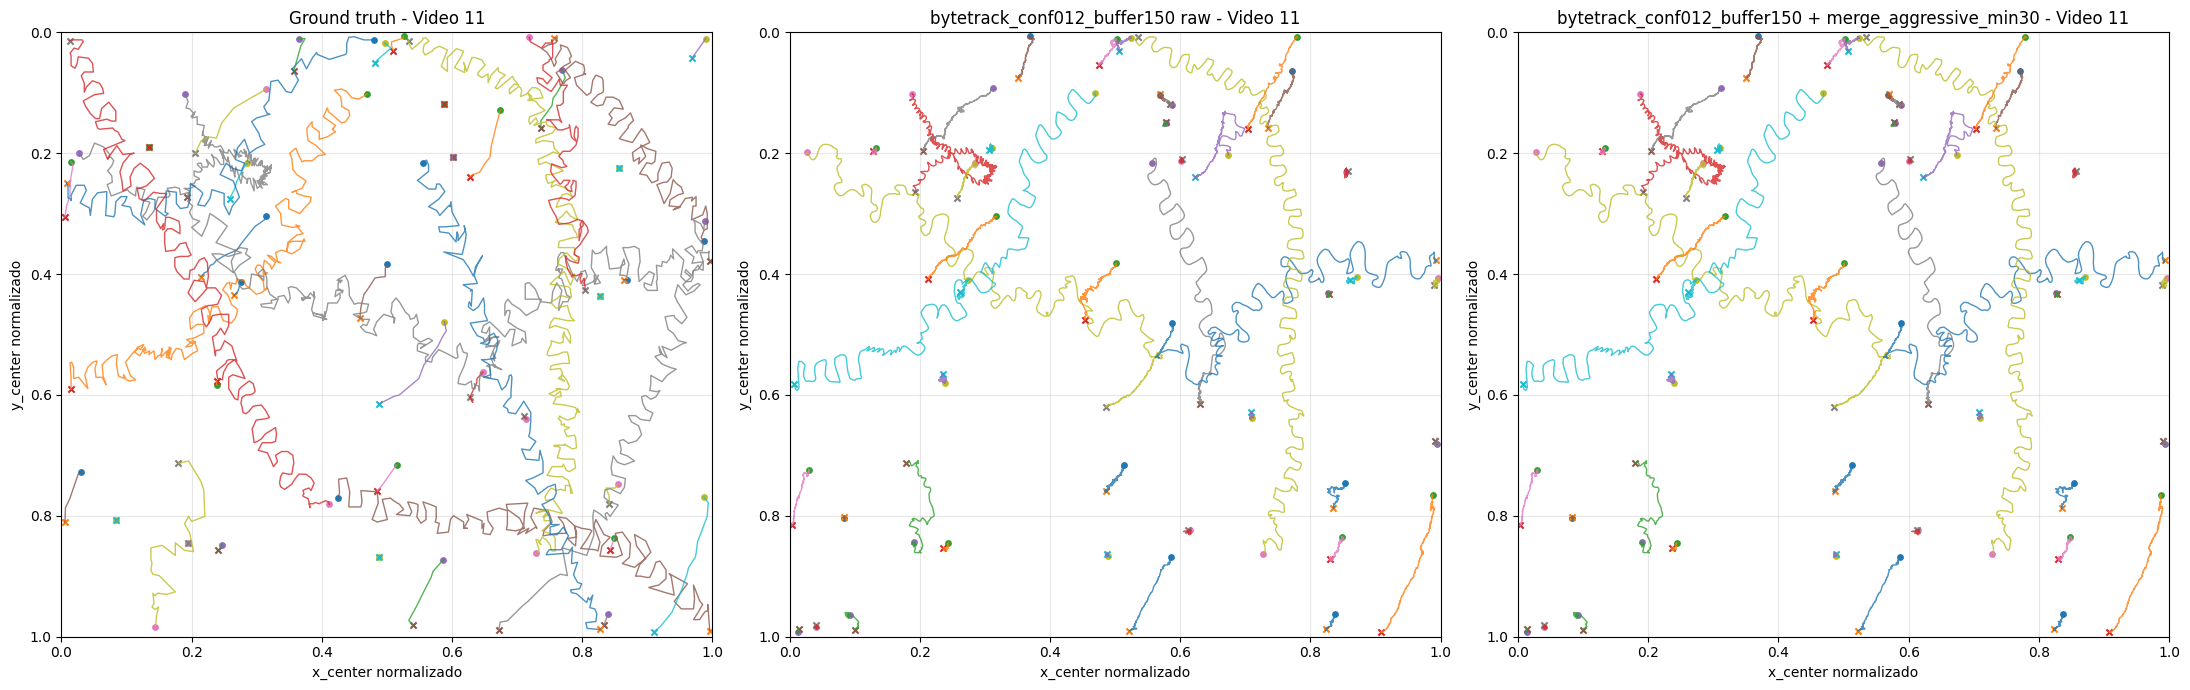

Figura final guardada en: /kaggle/working/visem_tracking_project/tracking_results_final_v2/gt_vs_raw_vs_postprocessed_video_11.png


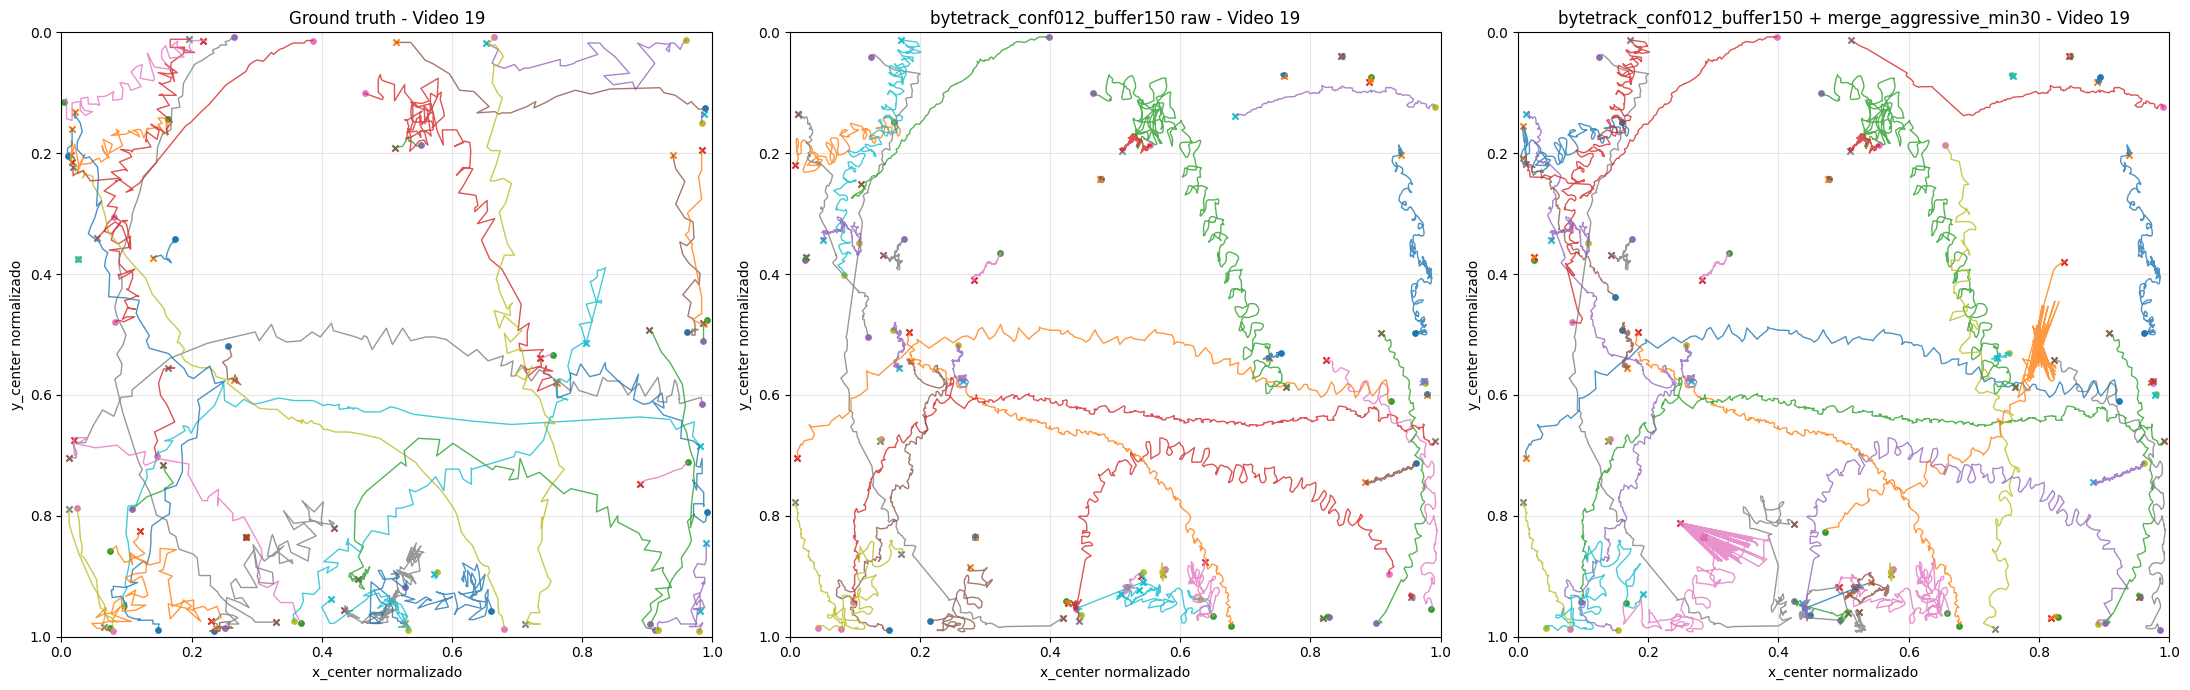

Figura final guardada en: /kaggle/working/visem_tracking_project/tracking_results_final_v2/gt_vs_raw_vs_postprocessed_video_19.png


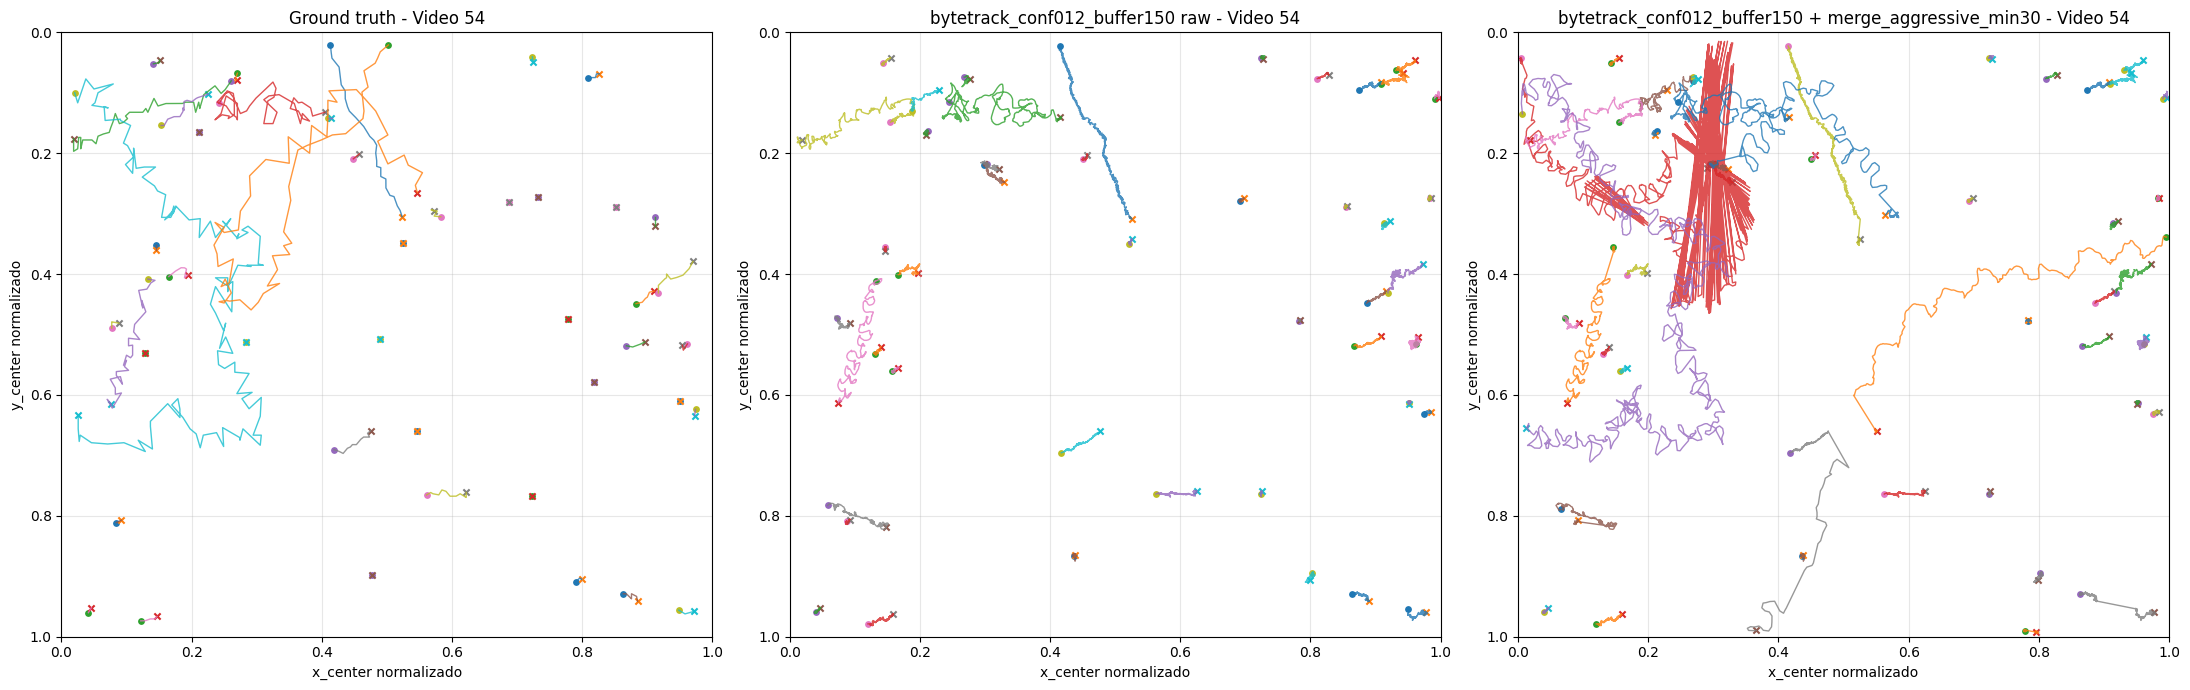

Figura final guardada en: /kaggle/working/visem_tracking_project/tracking_results_final_v2/gt_vs_raw_vs_postprocessed_video_54.png
Tabla agregada final para análisis:


,config,precision_aprox,recall_aprox,f1_aprox,mean_iou_matched,gt_tracks,pred_tracks,track_ratio_pred_gt,gt_median_frames_per_track,pred_median_frames_per_track,track_count_similarity,duration_similarity,point_count_similarity,diagnostic_score
0,bytetrack_conf012_buffer150_merge_aggressive_min30,0.681969,0.872588,0.765501,0.585620,58.333333,83.0,1.440708,688.5,455.666667,0.699233,0.712416,0.781700,0.720694
1,bytetrack_conf012_buffer150_raw,0.681054,0.875391,0.765994,0.585403,58.333333,151.0,2.655450,688.5,150.000000,0.393659,0.193848,0.778072,0.570837


In [37]:
# ============================================================
# 4) Visualización final por video test
# ============================================================

for video_id in TEST_VIDEO_IDS:
    gt_video_df = gt_all_df[gt_all_df["video"].astype(str) == str(video_id)].copy()
    pred_raw_video_df = pred_test_raw_all_df[pred_test_raw_all_df["video"].astype(str) == str(video_id)].copy()
    pred_processed_video_df = pred_test_processed_all_df[pred_test_processed_all_df["video"].astype(str) == str(video_id)].copy()

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    plot_tracks(
        axes[0],
        gt_video_df,
        title=f"Ground truth - Video {video_id}",
        max_tracks=45,
        min_frames=10,
    )

    plot_tracks(
        axes[1],
        pred_raw_video_df,
        title=f"{BEST_RAW_CONFIG_NAME} raw - Video {video_id}",
        max_tracks=45,
        min_frames=5,
    )

    plot_tracks(
        axes[2],
        pred_processed_video_df,
        title=f"{BEST_RAW_CONFIG_NAME} + {BEST_POSTPROCESS_NAME} - Video {video_id}",
        max_tracks=45,
        min_frames=5,
    )

    plt.tight_layout()
    final_plot_path = TRACKING_OUT_DIR / f"gt_vs_raw_vs_postprocessed_video_{video_id}.png"
    plt.savefig(final_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Figura final guardada en:", final_plot_path)

print("Tabla agregada final para análisis:")
display(test_final_agg_df[[
    "config",
    "precision_aprox",
    "recall_aprox",
    "f1_aprox",
    "mean_iou_matched",
    "gt_tracks",
    "pred_tracks",
    "track_ratio_pred_gt",
    "gt_median_frames_per_track",
    "pred_median_frames_per_track",
    "track_count_similarity",
    "duration_similarity",
    "point_count_similarity",
    "diagnostic_score",
]])


In [38]:
# ============================================================
# 5) Conclusión automática del experimento de tracking
# ============================================================

best_final = test_final_agg_df.iloc[0]
raw_final = test_final_agg_df[test_final_agg_df["config"].astype(str).str.endswith("_raw")]
processed_final = test_final_agg_df[~test_final_agg_df["config"].astype(str).str.endswith("_raw")]

print("Conclusión automática:")
print("- Mejor configuración final:", best_final["config"])
print(f"- Precision aproximada promedio: {best_final['precision_aprox']:.3f}")
print(f"- Recall aproximado promedio: {best_final['recall_aprox']:.3f}")
print(f"- F1 aproximado promedio: {best_final['f1_aprox']:.3f}")
print(f"- Tracks reales promedio: {best_final['gt_tracks']:.1f}")
print(f"- Tracks predichos promedio: {best_final['pred_tracks']:.1f}")
print(f"- Ratio pred/gt promedio: {best_final['track_ratio_pred_gt']:.2f}")
print(f"- Mediana frames/track real: {best_final['gt_median_frames_per_track']:.1f}")
print(f"- Mediana frames/track predicha: {best_final['pred_median_frames_per_track']:.1f}")

if best_final["track_ratio_pred_gt"] <= 1.8 and best_final["duration_similarity"] >= 0.35 and best_final["f1_aprox"] >= 0.75:
    verdict = "satisfactorio como modelo de tracking para el proyecto"
elif best_final["track_ratio_pred_gt"] <= 2.5 and best_final["f1_aprox"] >= 0.70:
    verdict = "funcional y defendible, pero todavía mejorable por fragmentación"
else:
    verdict = "insatisfactorio como resultado final; requiere más mejoras"

print("\nVeredicto sugerido:", verdict)

conclusion_text = f"""
## Conclusión final del tracking

Se entrenó un detector YOLO en modo `{DETECTION_MODE}` y se evaluó el flujo completo de tracking sobre videos no vistos. La configuración final se seleccionó usando únicamente validation: tracker `{BEST_RAW_CONFIG_NAME}` con postprocesamiento `{BEST_POSTPROCESS_NAME}`. Luego se evaluó en todos los videos de test: {', '.join(TEST_VIDEO_IDS)}.

El resultado promedio en test fue: precision aproximada {best_final['precision_aprox']:.3f}, recall aproximado {best_final['recall_aprox']:.3f}, F1 aproximado {best_final['f1_aprox']:.3f} y mean IoU {best_final['mean_iou_matched']:.3f}. En términos de tracking, el ground truth tuvo en promedio {best_final['gt_tracks']:.1f} trayectorias por video, mientras que el sistema predijo {best_final['pred_tracks']:.1f}, con una relación pred/gt de {best_final['track_ratio_pred_gt']:.2f}. La mediana de duración por track fue {best_final['pred_median_frames_per_track']:.1f} frames para la predicción frente a {best_final['gt_median_frames_per_track']:.1f} frames en el ground truth.

Veredicto: el resultado es {verdict}. Si todavía hay demasiados tracks predichos frente a los reales, el problema principal restante es la fragmentación de identidad. Si la precision baja mucho al filtrar menos tracks, el problema dominante son falsos positivos del detector/tracker.

Para el informe final, este resultado debe presentarse como un sistema completo de detección + tracking evaluado en videos no vistos, con selección de hiperparámetros en validation y evaluación final en test.
"""

print(conclusion_text)
with open(TRACKING_OUT_DIR / "final_tracking_conclusion.md", "w") as f:
    f.write(conclusion_text)


Conclusión automática:
- Mejor configuración final: bytetrack_conf012_buffer150_merge_aggressive_min30
- Precision aproximada promedio: 0.682
- Recall aproximado promedio: 0.873
- F1 aproximado promedio: 0.766
- Tracks reales promedio: 58.3
- Tracks predichos promedio: 83.0
- Ratio pred/gt promedio: 1.44
- Mediana frames/track real: 688.5
- Mediana frames/track predicha: 455.7

Veredicto sugerido: satisfactorio como modelo de tracking para el proyecto

## Conclusión final del tracking

Se entrenó un detector YOLO en modo `multiclass` y se evaluó el flujo completo de tracking sobre videos no vistos. La configuración final se seleccionó usando únicamente validation: tracker `bytetrack_conf012_buffer150` con postprocesamiento `merge_aggressive_min30`. Luego se evaluó en todos los videos de test: 11, 19, 54.

El resultado promedio en test fue: precision aproximada 0.682, recall aproximado 0.873, F1 aproximado 0.766 y mean IoU 0.586. En términos de tracking, el ground truth tuvo en promedio

## Conclusión esperada de esta versión final mejorada

Esta versión conserva el detector de la corrida anterior (`YOLOv8s`, `imgsz=960`, multiclase) y mejora el resto del flujo sin usar un modelo más potente.

Las mejoras principales son:

1. Ajuste de tracking usando todos los videos de validation.
2. Búsqueda de valores intermedios de `conf` para reducir falsos positivos sin destruir el recall.
3. Postprocesamiento seleccionado en validation: merge de fragmentos + filtrado de tracks cortos.
4. Corrección robusta de agregación de métricas para evitar errores con columnas de texto.
5. Evaluación final en todos los videos de test.
6. Exportación explícita de artefactos finales, incluyendo `best.pt`.

Para decidir si el resultado final es bueno, mira principalmente:

```text
pred_tracks cerca de gt_tracks
pred_median_frames_per_track alto
track_ratio_pred_gt bajo
precision_aprox y F1 razonables
visualización ground truth vs raw vs postprocessed
```

Si el ratio `pred/gt` sigue siendo muy alto, todavía hay fragmentación. Si el recall es alto pero la precision baja, el sistema está generando demasiadas detecciones o tracks extra.


## 13. Guardar artefactos finales

Esta sección guarda explícitamente el resultado exitoso del proyecto para que no se pierda al cerrar Kaggle. El archivo más importante es `best.pt`, que contiene los pesos del mejor modelo según validation durante el entrenamiento YOLO.

En Kaggle, los archivos dentro de `/kaggle/working` se pueden descargar desde la pestaña de outputs o quedar asociados a una versión guardada del notebook.

In [39]:
# ============================================================
# Exportar artefactos finales: modelo, métricas, gráficas y configuración
# ============================================================

FINAL_ARTIFACTS_DIR = WORK_DIR / "visem_final_artifacts"
FINAL_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Modelo entrenado
if Path(BEST_WEIGHTS_PATH).exists():
    shutil.copy2(BEST_WEIGHTS_PATH, FINAL_ARTIFACTS_DIR / "best.pt")
    print("best.pt copiado a:", FINAL_ARTIFACTS_DIR / "best.pt")
else:
    print("No se encontró BEST_WEIGHTS_PATH:", BEST_WEIGHTS_PATH)

if "LAST_WEIGHTS_PATH" in globals() and Path(LAST_WEIGHTS_PATH).exists():
    shutil.copy2(LAST_WEIGHTS_PATH, FINAL_ARTIFACTS_DIR / "last.pt")
    print("last.pt copiado a:", FINAL_ARTIFACTS_DIR / "last.pt")

# Configuración del dataset y métricas de entrenamiento
for candidate in [YAML_PATH, BEST_RUN_DIR / "results.csv", BEST_RUN_DIR / "results.png"]:
    candidate = Path(candidate)
    if candidate.exists():
        shutil.copy2(candidate, FINAL_ARTIFACTS_DIR / candidate.name)

# Métricas y resultados de tracking
if TRACKING_OUT_DIR.exists():
    for file_path in TRACKING_OUT_DIR.glob("*.csv"):
        shutil.copy2(file_path, FINAL_ARTIFACTS_DIR / file_path.name)
    for file_path in TRACKING_OUT_DIR.glob("*.md"):
        shutil.copy2(file_path, FINAL_ARTIFACTS_DIR / file_path.name)
    for file_path in TRACKING_OUT_DIR.glob("*.png"):
        shutil.copy2(file_path, FINAL_ARTIFACTS_DIR / file_path.name)

# Guardar configuración final usada
final_config = {
    "best_weights_path_original": str(BEST_WEIGHTS_PATH),
    "best_weights_path_exported": str(FINAL_ARTIFACTS_DIR / "best.pt"),
    "dataset_yaml": str(YAML_PATH),
    "detection_mode": DETECTION_MODE,
    "train_model_name": globals().get("TRAIN_MODEL_NAME", None),
    "train_img_size": globals().get("TRAIN_IMG_SIZE", None),
    "train_batch": globals().get("TRAIN_BATCH", None),
    "train_epochs": globals().get("TRAIN_EPOCHS", None),
    "train_patience": globals().get("TRAIN_PATIENCE", None),
    "best_tracker_config": BEST_RAW_CONFIG_NAME if "BEST_RAW_CONFIG_NAME" in globals() else None,
    "best_postprocess_config": BEST_POSTPROCESS_NAME if "BEST_POSTPROCESS_NAME" in globals() else None,
    "test_videos": TEST_VIDEO_IDS if "TEST_VIDEO_IDS" in globals() else None,
}

with open(FINAL_ARTIFACTS_DIR / "final_config.json", "w") as f:
    json.dump(final_config, f, indent=2)

# ZIP final descargable
FINAL_ZIP_PATH = WORK_DIR / "visem_final_artifacts.zip"
if FINAL_ZIP_PATH.exists():
    FINAL_ZIP_PATH.unlink()

with zipfile.ZipFile(FINAL_ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_path in FINAL_ARTIFACTS_DIR.rglob("*"):
        if file_path.is_file():
            zipf.write(file_path, arcname=file_path.relative_to(FINAL_ARTIFACTS_DIR))

print("\nArtefactos finales guardados en:")
print(FINAL_ARTIFACTS_DIR)
print("\nZIP final descargable:")
print(FINAL_ZIP_PATH)
print("\nArchivos principales:")
for p in sorted(FINAL_ARTIFACTS_DIR.glob("*"))[:30]:
    print("-", p.name)


best.pt copiado a: /kaggle/working/visem_final_artifacts/best.pt
last.pt copiado a: /kaggle/working/visem_final_artifacts/last.pt

Artefactos finales guardados en:
/kaggle/working/visem_final_artifacts

ZIP final descargable:
/kaggle/working/visem_final_artifacts.zip

Archivos principales:
- best.pt
- data.yaml
- final_config.json
- final_tracking_conclusion.md
- gt_vs_raw_vs_postprocessed_video_11.png
- gt_vs_raw_vs_postprocessed_video_19.png
- gt_vs_raw_vs_postprocessed_video_54.png
- last.pt
- pred_tracks_11_bytetrack_conf012_buffer150.csv
- pred_tracks_12_botsort_conf014_buffer150.csv
- pred_tracks_12_bytetrack_baseline.csv
- pred_tracks_12_bytetrack_conf012_buffer150.csv
- pred_tracks_12_bytetrack_conf014_buffer150.csv
- pred_tracks_12_bytetrack_conf016_buffer200.csv
- pred_tracks_12_bytetrack_conf018_buffer200.csv
- pred_tracks_12_bytetrack_conf020_buffer250.csv
- pred_tracks_19_bytetrack_conf012_buffer150.csv
- pred_tracks_23_botsort_conf014_buffer150.csv
- pred_tracks_23_bytetr

## Mejoras implementadas en esta versión

Esta versión se hizo pensando en los fallos concretos del notebook anterior:

1. **Demasiados tracks predichos frente al ground truth.**  
   Se agregó selección de postprocesamiento con filtrado de trayectorias cortas usando validation.

2. **Precision baja por falsos positivos.**  
   Se añadieron configuraciones de tracking con `conf` intermedio: 0.14, 0.16, 0.18 y 0.20. Esto busca reducir falsos positivos sin perder demasiado recall.

3. **Fragmentación de identidad.**  
   Se mantienen `track_buffer` altos y se conserva el merge de trayectorias fragmentadas por cercanía temporal, espacial, tamaño y velocidad estimada.

4. **Error anterior de agregación.**  
   `aggregate_metrics` ahora promedia solo columnas numéricas. Así no vuelve a fallar con columnas de texto como `stage`, `merge_config` o `postprocess_config`.

5. **Evaluación más defendible para el profesor.**  
   El tracker y el postprocesamiento se seleccionan en validation. Test se usa solo al final, en todos sus videos.

6. **Guardado explícito del resultado exitoso.**  
   El notebook exporta `best.pt`, métricas, gráficas, configuración final y un ZIP descargable.
